## Model Loading

In [1]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.5_description-ZNORM_LB_05/42/best.pt"

#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.5_description-ZNORM_LB_05/42/best_joint.pt"
#ckpt_path = joint_ckpt_pretrain_path
'''
    ckpt_path , joint_ckpt_pretrain_path 위 버전이 bary 있고 z_scoring한 버전. 0.5 버전임. collapse는 없지만 sample 차원에서는 entropy 높음.
'''
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.5_description-ZNORM_LB_05_2/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.5_description-ZNORM_LB_05_2/42/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-ZNORM_LB_03/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-ZNORM_LB_03/42/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-ZNORM_LB_03_NOBARY/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-ZNORM_LB_03_NOBARY/42/best_joint.pt"

### Case 1 ### 
# ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPTRAIN/42/best.pt"
# joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPTRAIN/42/best_joint.pt"

### Case 2 ###
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPFROZEN/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPFROZEN/42/best_joint.pt"

### Case 3 ###
# ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPTRAIN_SOFTMAX/42/best.pt"
# joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-BARYSCALE_EXPTRAIN_SOFTMAX/42/best_joint.pt"

#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-srFGW_commit_frozen_tau1/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-5_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.3_description-srFGW_commit_frozen_tau1/42/best_joint.pt"



#### NO VQ ####
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1/42/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-4_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ2/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-4_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ2/42/best_joint.pt"

#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.5_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW05/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.5_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW05/42/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ2_FGW01_ORTH01_/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.1_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ2_FGW01_ORTH01_/42/best_joint.pt"

#### FGW05 ORTH01 ####
# ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.5_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW05_ORTH01_20260211/42/best.pt"
# joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.5_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW05_ORTH01_20260211/42/best_joint.pt"

# #### FGW05 ORTH10 ####
# ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.5_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW05_ORTH10_20260211/42/best.pt"
# joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.5_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW05_ORTH10_20260211/42/best_joint.pt"

# #### FGW03 ORTH01 ####
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW03_ORTH01_20260211_/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW03_ORTH01_20260211_/42/best_joint.pt"



#### FGW03 ORTH10  (BEST) ####
# ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW03_ORTH01_20260211/42/best.pt"
# joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW03_ORTH01_20260211/42/best_joint.pt"

# #### FGW05 ORTH50 ####
# ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.5_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW05_ORTH50_20260211/42/best.pt"
# joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.5_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOVQ1_FGW05_ORTH50_20260211/42/best_joint.pt"

#### FGW03 ORTH10 LAbel-diversifying #### 

# ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-FGW03_ORTH01_DIV1/42/best.pt"
# joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-FGW03_ORTH01_DIV1/42/best_joint.pt"


#### Diversifying #### 
#ckppt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-HP1_HS01_ORTH1_DIV1_AGAIN/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-HP1_HS01_ORTH1_DIV1_AGAIN/42/best_joint.pt"

#### Div 10배 사용못함 ####
# ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-HP1_HS01_ORTH1_DIV10/42/best.pt"
# joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-HP1_HS01_ORTH1_DIV10/42/best_joint.pt"


#ckpt_path = joint_ckpt_pretrain_path 
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-NOBARY_L2_MEAN/42/20260212_220439/best_joint.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-GNN1_NOBARY/42/20260213_125718/best_joint.pt"
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-GNN2_NOBARY_AY/42/20260213_165727/best_joint.pt"
joint_ckpt_pretrain_path = ckpt_path
#target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.01_description-None/50/20260128_122753/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260128_122753.pt"
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+heart_failure_clinical_records+cardio_SAheart/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.2_kl_gamma-2.0_tau-0.2_target_data-Medicaldataset_entropic_reg-0.1_description-Regularization3/50/20260202_211809/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260202_211809.pt"
# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

In [2]:
import torch
ckpt = torch.load(ckpt_path, map_location='cpu')
print(ckpt['args'].orth_reg)

0.1


## Source Loading

In [3]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


>>> [System] Seed 42 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 791
Validation data size: 264
Test data size: 264
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 162
Validation data s

In [4]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings

import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


In [5]:
import torch.nn.functional as F

model.eval()
src_cls = {}

with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        name_embs, val_embs = [], []
        if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
        if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
        if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
        if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        
        name = torch.cat(name_embs, dim=1)
        val = torch.cat(val_embs, dim=1)
        x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x)
            out, _ = model.basis_layers[l](name, norm_x)
            x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
        
        src_cls[src_name] = x[:, 0, :]
        print(f"{src_name}: shape={x[:, 0, :].shape}")

# Source 간 비교
keys = list(src_cls.keys())
print("\n=== Source 간 cos_sim ===")
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        cos = F.cosine_similarity(src_cls[keys[i]].mean(0, keepdim=True),
                                   src_cls[keys[j]].mean(0, keepdim=True))
        print(f"  {keys[i]} vs {keys[j]}: {cos.item():.4f}")

# Source 내 샘플 간 비교
print("\n=== Source 내 intra cos_sim ===")
for k in keys:
    feat = src_cls[k]
    sim = F.cosine_similarity(feat.unsqueeze(1), feat.unsqueeze(0), dim=2)
    mask = ~torch.eye(feat.size(0), dtype=bool, device=feat.device)
    print(f"  {k}: mean={sim[mask].mean():.4f}, min={sim[mask].min():.4f}, max={sim[mask].max():.4f}")

Medicaldataset: shape=torch.Size([32, 768])
Cardiovascular_Disease_Dataset: shape=torch.Size([32, 768])
Heart_disease_statlog: shape=torch.Size([32, 768])
Erbil_Cardiovascular_Health_Dataset: shape=torch.Size([32, 768])
cardio_SAheart: shape=torch.Size([32, 768])
heart_failure_clinical_records: shape=torch.Size([32, 768])

=== Source 간 cos_sim ===
  Medicaldataset vs Cardiovascular_Disease_Dataset: 0.3987
  Medicaldataset vs Heart_disease_statlog: 0.1779
  Medicaldataset vs Erbil_Cardiovascular_Health_Dataset: 0.4113
  Medicaldataset vs cardio_SAheart: 0.2693
  Medicaldataset vs heart_failure_clinical_records: 0.1994
  Cardiovascular_Disease_Dataset vs Heart_disease_statlog: 0.9115
  Cardiovascular_Disease_Dataset vs Erbil_Cardiovascular_Health_Dataset: 0.8650
  Cardiovascular_Disease_Dataset vs cardio_SAheart: 0.5982
  Cardiovascular_Disease_Dataset vs heart_failure_clinical_records: 0.6112
  Heart_disease_statlog vs Erbil_Cardiovascular_Health_Dataset: 0.6381
  Heart_disease_statlog 

In [6]:
# Source별 attention pattern 비교
with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        name_embs, val_embs = [], []
        if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
        if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
        if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
        if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
        
        name = torch.cat(name_embs, dim=1)
        val = torch.cat(val_embs, dim=1)
        x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x)
            out, attn = model.basis_layers[l](name, norm_x)
            x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
        
        # 마지막 layer의 attention
        cs = -torch.log(attn.clamp_min(1e-8))  # 우리가 쓰는 CS
        print(f"{src_name}: CS mean={cs.mean():.4f}, std={cs.std():.4f}, "
              f"intra_sample_std={cs.std(dim=(1,2)).mean():.4f}")

Medicaldataset: CS mean=5.1957, std=5.0826, intra_sample_std=0.9424
Cardiovascular_Disease_Dataset: CS mean=3.8951, std=4.0988, intra_sample_std=0.2759
Heart_disease_statlog: CS mean=4.0310, std=4.0989, intra_sample_std=0.2555
Erbil_Cardiovascular_Health_Dataset: CS mean=3.8363, std=3.2996, intra_sample_std=0.1779
cardio_SAheart: CS mean=3.8490, std=4.6260, intra_sample_std=0.2584
heart_failure_clinical_records: CS mean=3.8823, std=4.2476, intra_sample_std=0.2922


## Source 1 attention map Loading

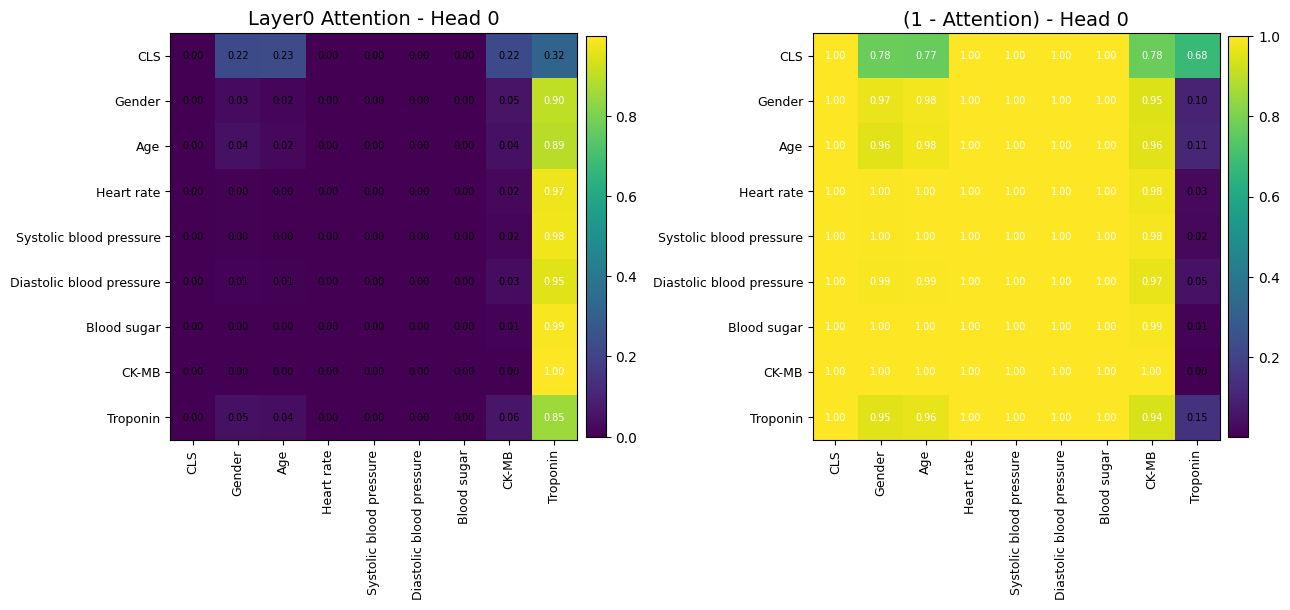

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0043 | std=0.2176
         Gender  | mean=0.0050 | std=2.4402
            Age  | mean=0.0066 | std=1.8792
     Heart rate  | mean=0.0216 | std=1.8585
Systolic blood pressure  | mean=0.0423 | std=2.1799
Diastolic blood pressure  | mean=0.0008 | std=1.4403
    Blood sugar  | mean=0.3242 | std=8.7374
          CK-MB  | mean=-0.3762 | std=6.9158
       Troponin  | mean=-0.1952 | std=3.4848

=== Global embedding statistics ===
global mean: -0.0195
global std : 4.1688


In [7]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



## Affinity Two sample

In [8]:
import numpy as np
from collections import defaultdict
@torch.no_grad()
def collect_all_samples_from_source(model, loader, source_name):
    """
    한 source의 모든 샘플에 대해 node embedding과 affinity 추출
    
    Returns:
        all_embeddings: list of [N, D] arrays (CLS 제외한 variable nodes만)
        all_affinities: list of [N, N] arrays (1 - attention, Var-Var만)
        all_labels: list of labels
        all_feature_names: list of feature name lists
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []
    
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        
        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            
            # attention shape: [B, H, T, T]
            last_att = att
            
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B, H, T, T]
        # Head 0 사용
        last_att = last_att[:, 0, :, :]  # [B, T, T]
        
        # Feature names
        var_names = extract_feature_names(batch)
        
        for b in range(B):
            # CLS 제외 (1:부터)
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N, D]
            
            # Var-Var attention만 (CLS 제외)
            var_att = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N, N]
            
            # 1 - attention = distance/affinity
            affinity = 1.0 - var_att
            
            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(batch['y'][b].item())
            all_feature_names.append(var_names)
    
    return all_embeddings, all_affinities, all_labels, all_feature_names

def compute_frobenius_distances(embeddings, affinities):
    """
    모든 샘플 쌍의 Frobenius distance 계산
    
    Returns:
        emb_distances: [n_samples, n_samples] embedding Frobenius distances
        aff_distances: [n_samples, n_samples] affinity Frobenius distances
    """
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Embedding Frobenius distance
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff
            
            # Affinity Frobenius distance
            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff
    
    return emb_distances, aff_distances

def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    """
    Reference 샘플과 같은/다른 레이블 내에서 가장 유사/상이한 샘플 찾기
    
    Returns:
        most_similar_same_label_idx: 같은 레이블 중 가장 유사
        most_different_other_label_idx: 다른 레이블 중 가장 상이
    """
    n = len(distances)
    ref_label = labels[reference_idx]
    
    # 같은 레이블 샘플들
    same_label_mask = np.array([labels[i] == ref_label for i in range(n)])
    same_label_mask[reference_idx] = False  # 자기자신 제외
    
    # 다른 레이블 샘플들
    other_label_mask = np.array([labels[i] != ref_label for i in range(n)])
    
    # 같은 레이블 중 가장 유사 (거리 최소)
    dist_same_label = distances[reference_idx].copy()
    dist_same_label[~same_label_mask] = np.inf
    most_similar_same_label_idx = np.argmin(dist_same_label)
    
    # 다른 레이블 중 가장 상이 (거리 최대)
    dist_other_label = distances[reference_idx].copy()
    dist_other_label[~other_label_mask] = -np.inf
    most_different_other_label_idx = np.argmax(dist_other_label)
    
    return most_similar_same_label_idx, most_different_other_label_idx

In [9]:
# 1. 데이터 수집
src = sources[1]  # 첫 번째 source
loader = loaders[src]

print(f"Collecting samples from source: {src}")
embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(model, loader, src)

print(f"Total samples collected: {len(embeddings)}")
print(f"Node embedding shape: {embeddings[0].shape}")
print(f"Affinity shape: {affinities[0].shape}")

# 2. Frobenius distance 계산
print("Computing Frobenius distances...")
emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

print(f"Embedding distance matrix shape: {emb_distances.shape}")
print(f"Affinity distance matrix shape: {aff_distances.shape}")

# 3. Reference 샘플 선택 (예: 첫 번째 샘플)
reference_idx = 1

# Affinity 기준으로 같은 레이블에서 가장 유사, 다른 레이블에서 가장 상이한 샘플 찾기
similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, aff_distances, labels)

print(f"\n=== Analysis based on Affinity Frobenius Distance (Label-aware) ===")
print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)

=== Analysis based on Affinity Frobenius Distance (Label-aware) ===
Reference sample: 1 (label: 1)

Most similar (SAME label): 918 (label: 1)
  → Affinity Frobenius distance: 0.0131

Most different (OTHER label): 726 (label: 0)
  → Affinity Frobenius distance: 0.5486



=== Reference Sample Affinity ===


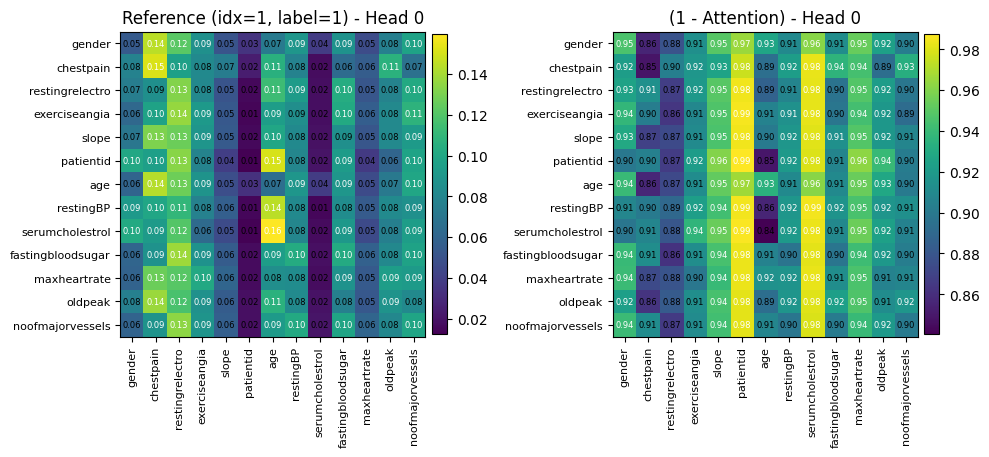


=== Most Similar Sample (SAME Label) Affinity ===
Frobenius distance: 0.0131


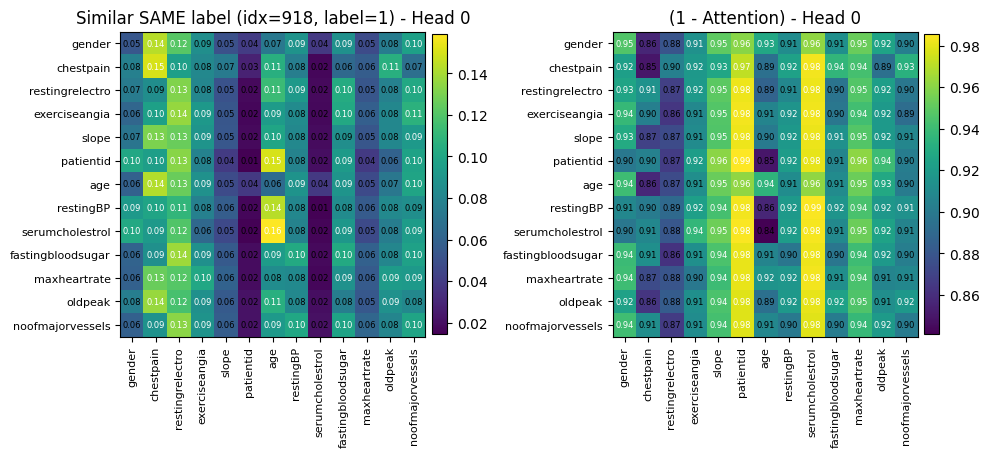


=== Most Different Sample (OTHER Label) Affinity ===
Frobenius distance: 0.5486


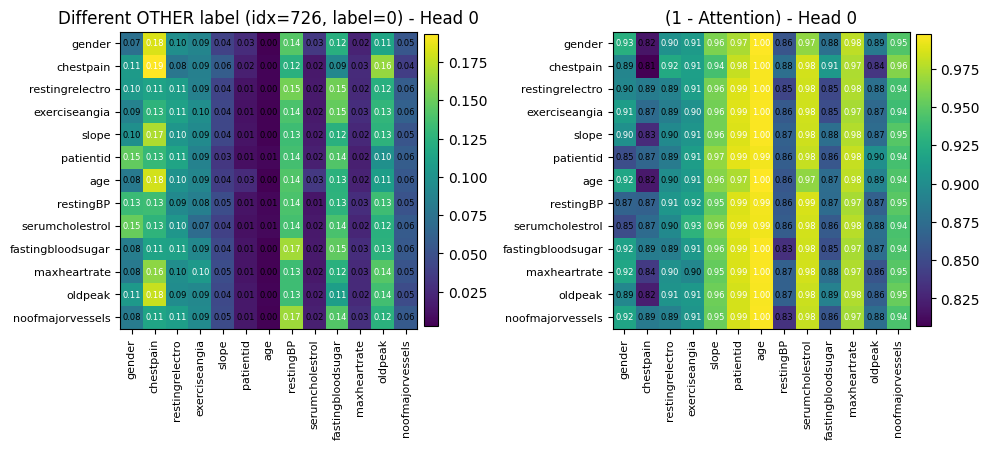

In [10]:
# 4. 시각화
feature_names = ["CLS"] + feature_names_list[0]
var_names = feature_names_list[0]

# Reference 샘플 affinity
ref_aff = affinities[reference_idx]
# Most similar (same label) 샘플 affinity
sim_aff = affinities[similar_idx]
# Most different (other label) 샘플 affinity
diff_aff = affinities[different_idx]

# 3D attention shape로 변환 (plot 함수 호환)
ref_aff_3d = ref_aff[np.newaxis, :, :]  # [1, N, N]
sim_aff_3d = sim_aff[np.newaxis, :, :]
diff_aff_3d = diff_aff[np.newaxis, :, :]

print("\n=== Reference Sample Affinity ===")
plot_attention_with_inverse(
    att=1.0 - ref_aff_3d,  # affinity를 다시 attention으로
    feature_names=var_names,
    title=f"Reference (idx={reference_idx}, label={labels[reference_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Similar Sample (SAME Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - sim_aff_3d,
    feature_names=var_names,
    title=f"Similar SAME label (idx={similar_idx}, label={labels[similar_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Different Sample (OTHER Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - diff_aff_3d,
    feature_names=var_names,
    title=f"Different OTHER label (idx={different_idx}, label={labels[different_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

## Multi-Source Joint checkpoint

In [11]:
joint_ckpt_pretrain = torch.load(joint_ckpt_pretrain_path, map_location=device)
joint_args = joint_ckpt_pretrain['args']

# Joint 모델 초기화
joint_model_pretrain = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt_pretrain['model_state_dict']
missing, unexpected = joint_model_pretrain.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model_pretrain.eval()

Joint Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x ModuleList(
        (0-1): 2 x lightGraphNeuralNet(
          (dropout): Dropout(p=0.1, inplace=False)
          (linear): Linear(in_features=768, out_features=192, bias=True)
          (update): Linear(in_features=192, out_features=768, bias=True)
          (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (attn): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): Tanh()
          (2): Linear(in_features=192, out_features=1, bias=True)
        )
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
 

## 1. Qualitative Analysis - Label-conditioned Optimal Transport Plan 

In [12]:
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities):
    """
    3개 샘플 (ref, similar, different) x M개 LCG Transport Plan 계산
    학습 코드(compute_fgw + z-norm routing)와 완전 일치
    """
    import torch.nn.functional as F
    
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)
        
        N = src_feat.shape[1]
        
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)
        
        lcg_feat_exp = lcg_feat
        lcg_str_exp = lcg_struct
        
        # ---- M_cost: 학습 코드와 동일 ----
        if feat_distance == 'cosine':
            src_norm = F.normalize(src_feat_exp, dim=-1)
            tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
            cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
            M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
        else:
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            M_raw = dist_sq / float(D)
            q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
            M_cost = M_raw / q90
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = float(model.graph_quantizer.alpha)
        reg = float(model.graph_quantizer.reg)
        
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach()  # [M]
        plans = result.plan.detach().cpu().numpy()
        
        # ---- z-norm + softmax: 학습 코드와 동일 ----
        d = distances.unsqueeze(0)
        soft_tau = float(model.graph_quantizer.soft_tau)
        pi = torch.softmax(-d / soft_tau, dim=1).squeeze(0).cpu().numpy()
        
        all_plans.append(plans)
        all_distances.append(distances.cpu().numpy())
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)
    all_distances = np.array(all_distances)
    all_coordinates = np.array(all_coordinates)
    
    return all_plans, all_distances, all_coordinates


def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = plans.shape[1]  # M에서 자동으로
    
    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(5 * n_lcgs, 9))
    
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    
    frob_norms_similar = []
    frob_norms_different = []
    
    for j in range(n_lcgs):
        plan_ref = plans[0, j]
        plan_sim = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))
    
    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi = coordinates[i, j]
            dist = distances[i, j]
            
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)
            
            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[i]})', fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])
            
            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
                
                frob_sim = frob_norms_similar[j]
                frob_diff = frob_norms_different[j]
                ax.text(0.5, -0.5, f'Frob: Sim={frob_sim:.3f} vs Diff={frob_diff:.3f}',
                       transform=ax.transAxes, ha='center', va='top',
                       fontsize=10, color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            else:
                ax.set_xticks([])
            
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.suptitle(f'Transport Plans: Reference vs Similar vs Different (across {n_lcgs} LCGs)', 
                 fontsize=14, y=0.99)
    plt.show()

In [13]:
# 실행
print("Computing Transport Plans for 3 samples x 8 LCGs...")
sample_indices = [reference_idx, similar_idx, different_idx]

plans, distances, coordinates = compute_transport_plans_for_samples(
    joint_model_pretrain, sample_indices, embeddings, affinities
)

print(f"Plans shape: {plans.shape}")  # [3, 8, N, K]
print(f"Distances shape: {distances.shape}")  # [3, 8]
print(f"Coordinates shape: {coordinates.shape}")  # [3, 8]

print("\n=== Coordinates (pi) ===")
print("Reference:", coordinates[0])
print("Similar:", coordinates[1])
print("Different:", coordinates[2])

print("\n=== FGW Distances ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

Computing Transport Plans for 3 samples x 8 LCGs...
Plans shape: (3, 8, 13, 8)
Distances shape: (3, 8)
Coordinates shape: (3, 8)

=== Coordinates (pi) ===
Reference: [1.73757359e-01 1.75266519e-01 2.53292352e-01 2.13970765e-01
 2.06667799e-04 3.44447821e-04 7.13286474e-02 1.11833245e-01]
Similar: [0.1740672  0.17132998 0.27558154 0.20024619 0.00027825 0.0004019
 0.06913991 0.10895507]
Different: [7.9441585e-02 3.6308643e-01 1.4483464e-01 2.2373033e-01 3.1700340e-04
 2.9990045e-04 2.3382680e-02 1.6490737e-01]

=== FGW Distances ===
Reference: [0.38750303 0.38741654 0.38373417 0.38542122 0.45484605 0.44973773
 0.39640665 0.39190954]
Similar: [0.3885277  0.38868618 0.38393328 0.38712662 0.45291436 0.44923764
 0.39776078 0.39321274]
Different: [0.38360244 0.36840627 0.37759674 0.37324825 0.4388411  0.43939573
 0.39583272 0.37629884]


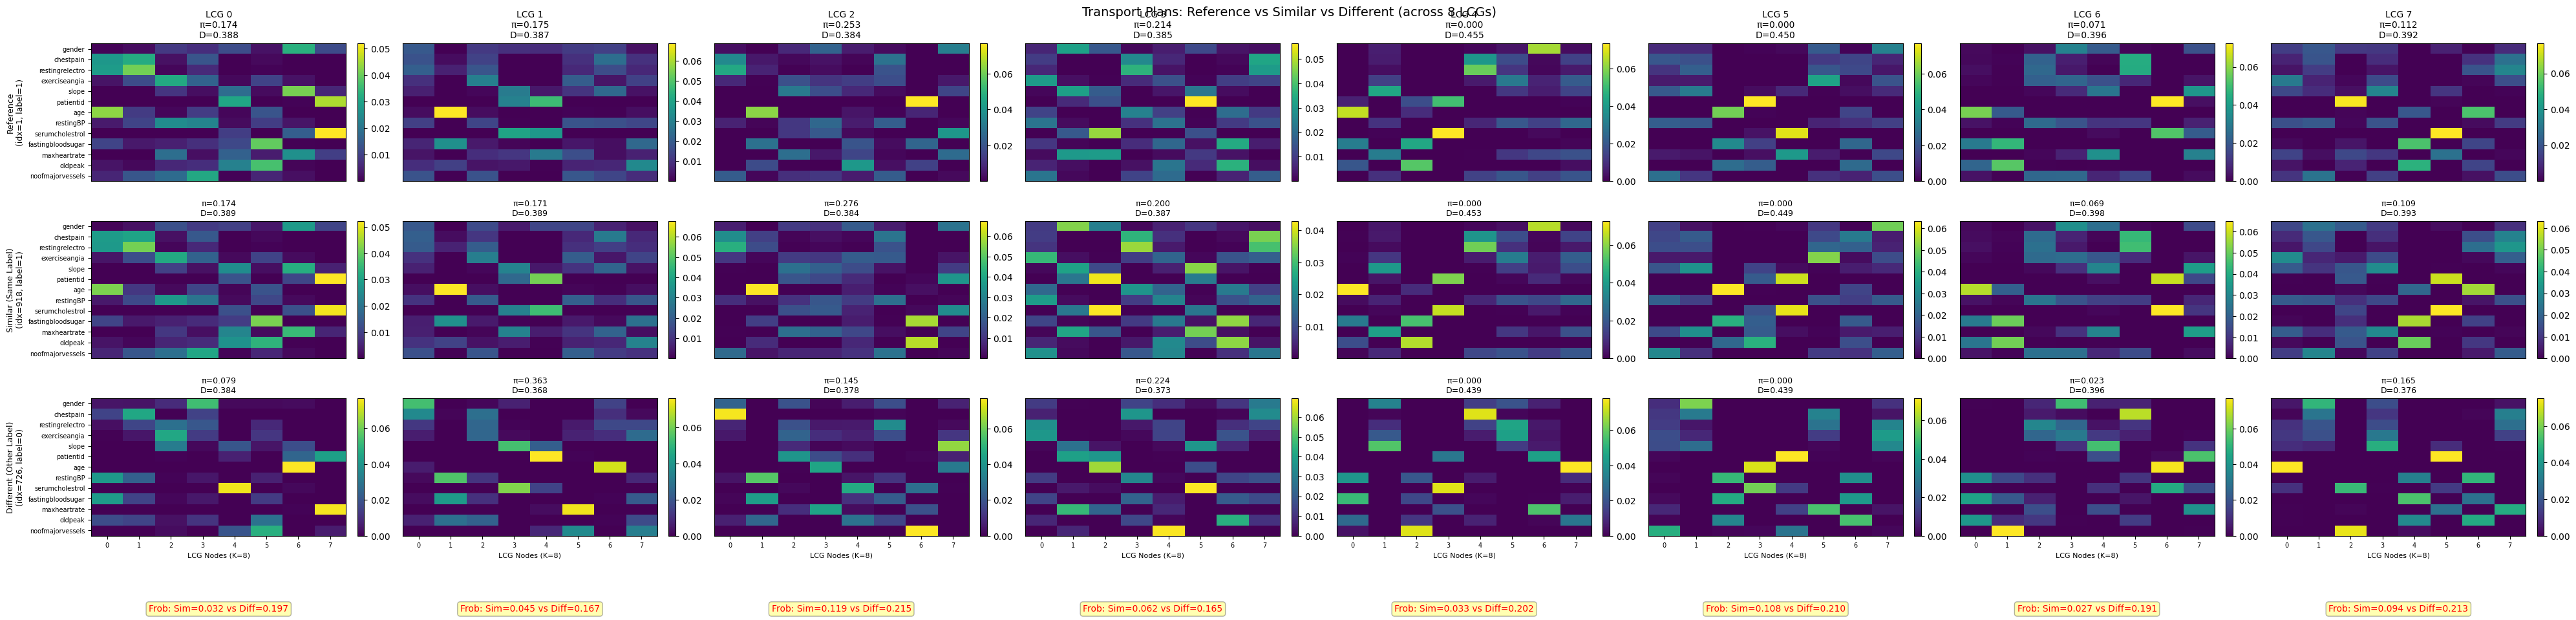

In [14]:
# 호출할 때 sample_indices에 해당하는 labels를 직접 전달
sample_labels = [labels[idx] if idx < len(labels) else '?' for idx in sample_indices]

plot_transport_plans_grid(
    plans, coordinates, distances, 
    sample_indices, sample_labels, var_names
)

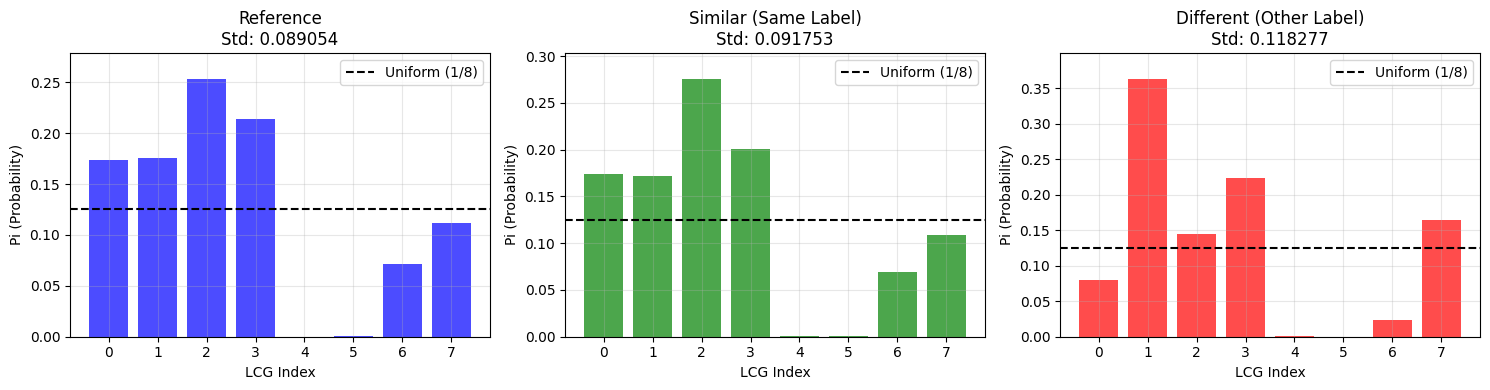

In [15]:
M = len(coordinates[0])  # 자동으로 graph 수 감지

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(M), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/M, color='black', linestyle='--', label=f'Uniform (1/{M})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
from ot.batch import solve_gromov_batch

## Qualitative Analysis - Optimal Transport Plan + Coordinate (1)

- Source 별 결과

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 1)

Most similar (SAME label): 981 (label: 1)
  → distance: 0.0872

Most different (OTHER label): 162 (label: 0)
  → distance: 2.0940

Computing Transport Plans for 3 samples x 8 LCGs...


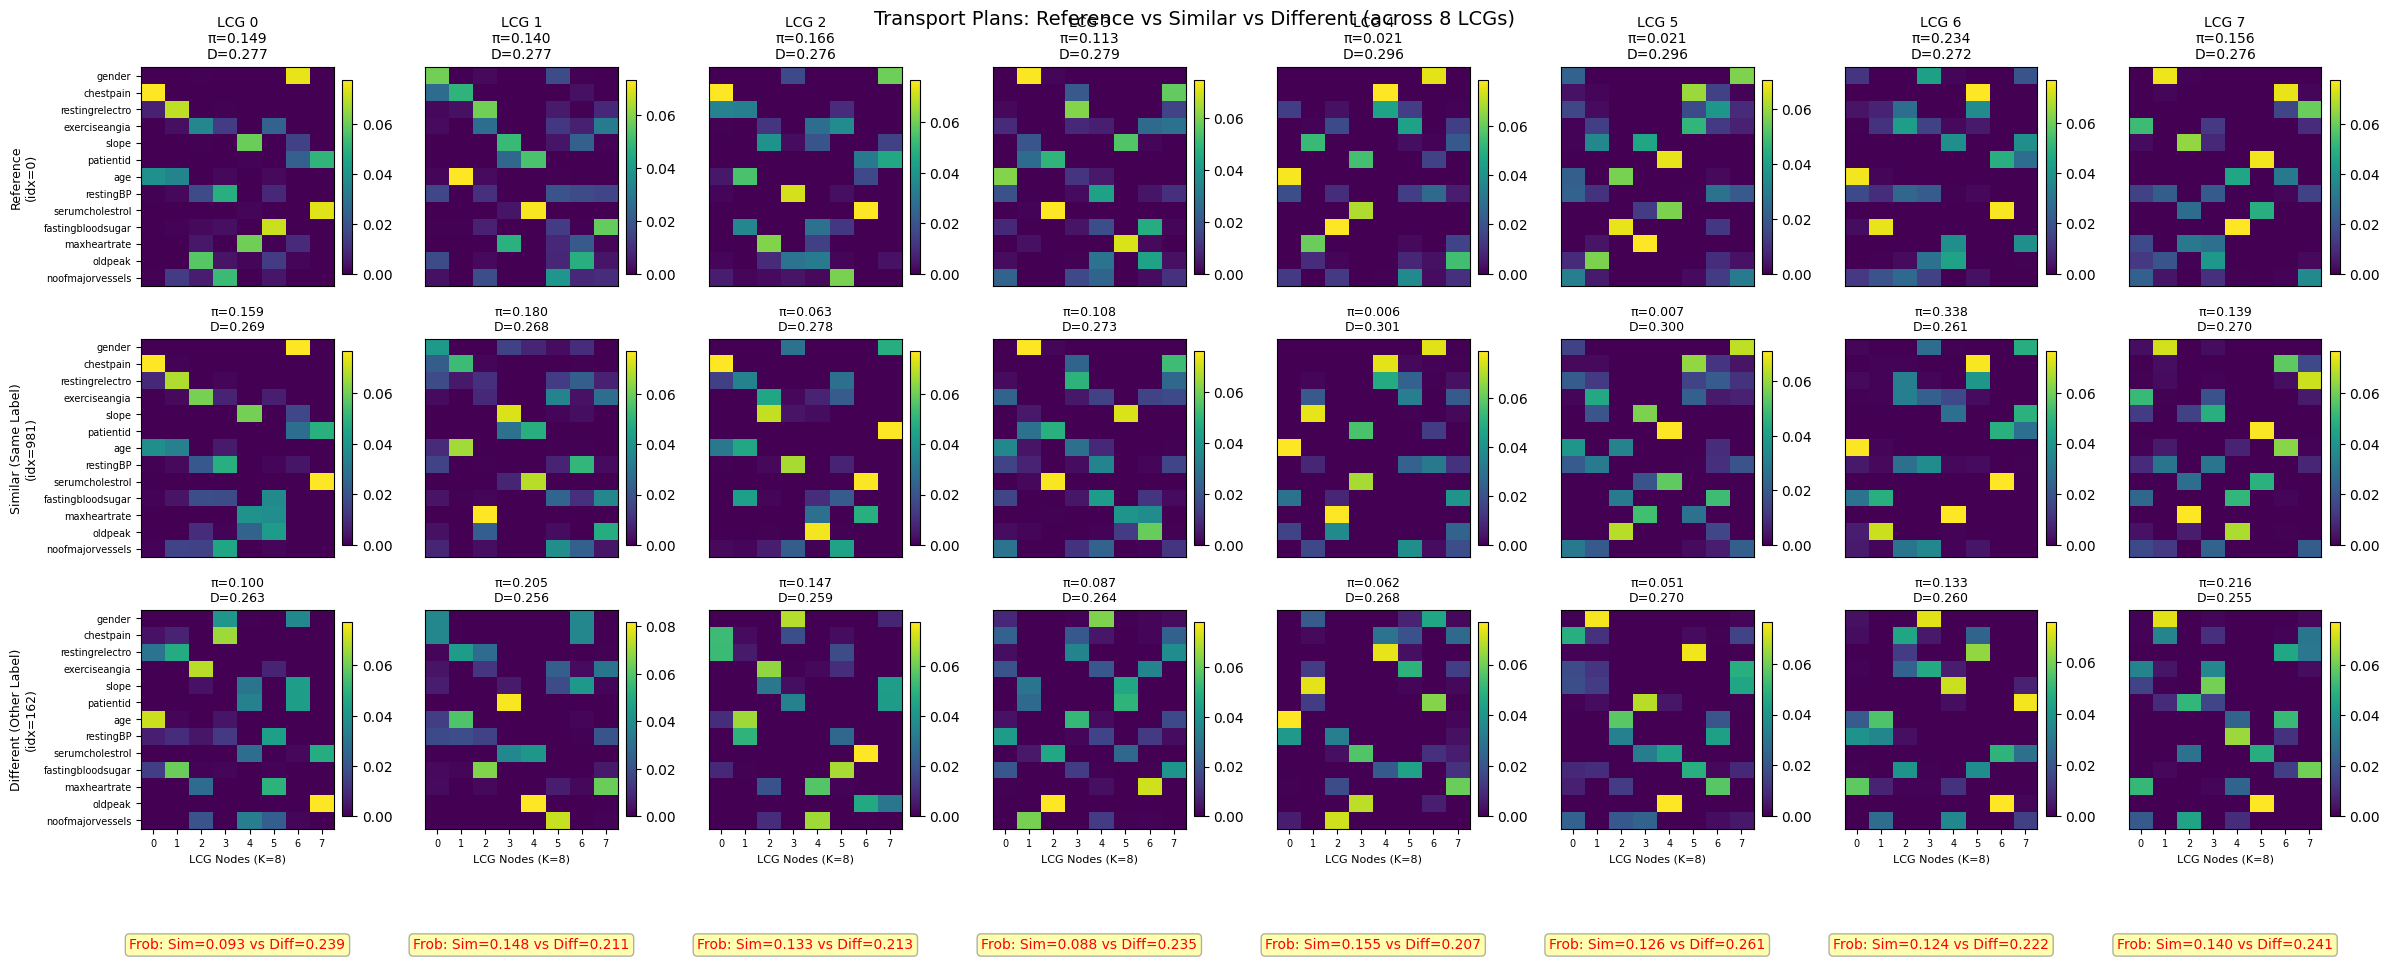

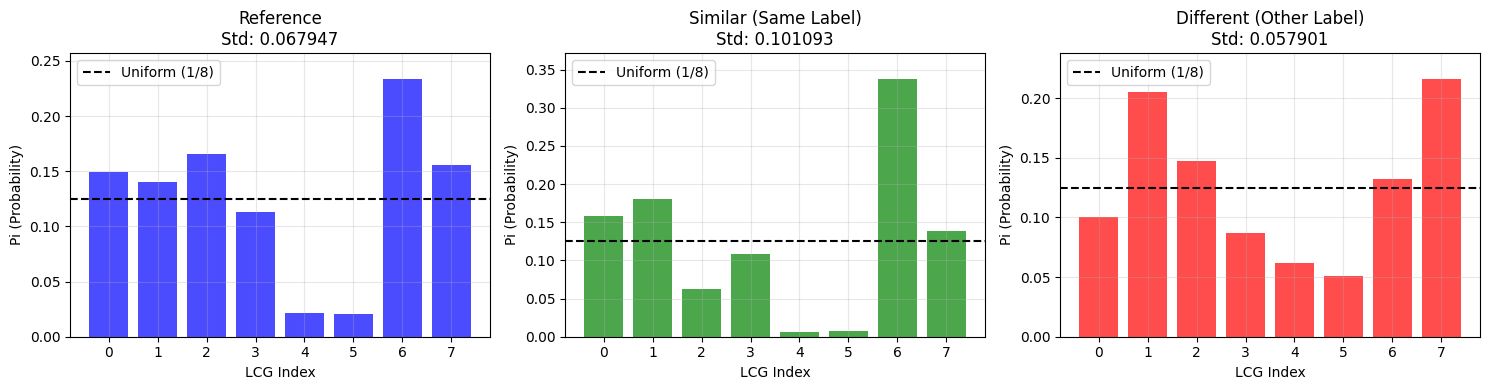

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================================================
# 0) (helper) label-aware ref/sim/diff pick
# =========================================================
def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    n = len(distances)
    ref_label = labels[reference_idx]

    same_label_mask = np.array([labels[i] == ref_label for i in range(n)], dtype=bool)
    same_label_mask[reference_idx] = False

    other_label_mask = np.array([labels[i] != ref_label for i in range(n)], dtype=bool)

    dist_same = distances[reference_idx].copy()
    dist_same[~same_label_mask] = np.inf
    most_similar_same_label_idx = int(np.argmin(dist_same))

    dist_other = distances[reference_idx].copy()
    dist_other[~other_label_mask] = -np.inf
    most_different_other_label_idx = int(np.argmax(dist_other))

    return most_similar_same_label_idx, most_different_other_label_idx


# =========================================================
# 1) collect all samples (embeddings + affinity) from ONE source loader
#    - 너가 준 로직 그대로: last_att(head0) -> var-var -> affinity = 1-att
# =========================================================
@torch.no_grad()
def collect_all_samples_from_source(model, loader, device, extract_feature_names_fn=None):
    """
    Returns:
        all_embeddings: list of [N,D] (CLS 제외 var nodes)
        all_affinities: list of [N,N] (1-attention, Var-Var)
        all_labels: list[int]
        all_feature_names: list[var_names]  (extract_feature_names_fn 제공 시)
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []

    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        # desc/name/value gather (너 코드 그대로)
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])

        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name  = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)

        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None

        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)  # att: [B,H,T,T]
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B,H,T,T] -> head0 -> [B,T,T]
        last_att = last_att[:, 0, :, :]

        # var names
        if extract_feature_names_fn is not None:
            var_names = extract_feature_names_fn(batch)
        else:
            var_names = None

        for b in range(B):
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()
            var_att  = last_att[b, 1:, 1:].detach()
            log_attn = -torch.log(var_att.clamp_min(1e-8))
            q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            affinity = (log_attn / q90).clamp_max(1.0).cpu().numpy()

            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(int(batch['y'][b].item()))
            all_feature_names.append(var_names)

    return all_embeddings, all_affinities, all_labels, all_feature_names


# =========================================================
# 2) Frobenius distance matrix (O(n^2))
# =========================================================
def compute_frobenius_distances(embeddings, affinities):
    n = len(embeddings)
    emb_distances = np.zeros((n, n), dtype=np.float32)
    aff_distances = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(i + 1, n):
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff

            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff

    return emb_distances, aff_distances


# =========================================================
# 3) FGW plans + pi (너 코드 그대로)
#    NOTE: solve_gromov_batch는 네 세션에 이미 import 되어 있어야 함
# =========================================================
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities, device):
    import torch.nn.functional as F
    
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')

    all_plans = []
    all_distances = []
    all_coordinates = []

    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)
        src_str  = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)
        N = src_feat.shape[1]

        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)
        src_str_exp  = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)

        if feat_distance == 'cosine':
            src_norm = F.normalize(src_feat_exp, dim=-1)
            tgt_norm = F.normalize(lcg_feat, dim=-1)
            cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
            M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
        else:
            dist_sq = torch.cdist(src_feat_exp, lcg_feat, p=2) ** 2
            M_raw = dist_sq / float(D)
            q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
            M_cost = M_raw / q90

        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K

        alpha = float(model.graph_quantizer.alpha)
        reg   = float(model.graph_quantizer.reg)

        result = solve_gromov_batch(
            src_str_exp, lcg_struct, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )

        plans = result.plan.detach().cpu().numpy()
        
        d = result.value.detach().unsqueeze(0)
        soft_tau = float(model.graph_quantizer.soft_tau)
        pi = torch.softmax(-d / soft_tau, dim=1).squeeze(0).cpu().numpy()

        all_plans.append(plans)
        all_distances.append(result.value.detach().cpu().numpy())
        all_coordinates.append(pi)

    return np.array(all_plans), np.array(all_distances), np.array(all_coordinates)


# =========================================================
# 4) plot grid (너 코드 그대로)
# =========================================================
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = plans.shape[1]

    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']

    frob_norms_similar = []
    frob_norms_different = []
    for j in range(n_lcgs):
        plan_ref  = plans[0, j]
        plan_sim  = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))

    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi   = coordinates[i, j]
            dist = distances[i, j]

            im = ax.imshow(plan, cmap='viridis', aspect='auto')

            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)

            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]})', fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])

            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])

            if i == n_samples - 1:
                ax.text(
                    0.5, -0.5, f'Frob: Sim={frob_norms_similar[j]:.3f} vs Diff={frob_norms_different[j]:.3f}',
                    transform=ax.transAxes,
                    ha='center', va='top',
                    fontsize=10, color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)',
                 fontsize=14, y=0.99)
    plt.show()


# =========================================================
# 5) plot pi 비교 (너 코드 그대로)
# =========================================================
def plot_pi_bars(coordinates):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    M = len(coordinates[0])
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    colors = ['blue', 'green', 'red']

    for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
        ax = axes[i]
        ax.bar(range(M), coord, color=color, alpha=0.7)
        ax.set_xlabel('LCG Index')
        ax.set_ylabel('Pi (Probability)')
        ax.set_title(f'{name}\nStd: {coord.std():.6f}')
        ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
        ax.axhline(y=1/M, color='black', linestyle='--', label='Uniform (1/8)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# =========================================================
# 6) WRAP-UP (한 방에)
#    - model, loader만 넣으면: 수집 -> 거리 -> ref/sim/diff -> FGW -> 두 plot
#    - var_names는 extract_feature_names로 뽑거나, 없으면 feature_names_list[0]에서 가져옴
# =========================================================
def run_transport_plan_wrapup(
    model,
    loader,
    device,
    source_name="",
    reference_idx=0,
    distance_mode="affinity",   # "affinity" or "embedding"
    extract_feature_names_fn=None,
):
    print(f"Collecting samples from source: {source_name}")
    embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(
        model=model,
        loader=loader,
        device=device,
        extract_feature_names_fn=extract_feature_names_fn
    )

    print(f"Total samples collected: {len(embeddings)}")
    print(f"Node embedding shape: {embeddings[0].shape}")
    print(f"Affinity shape: {affinities[0].shape}")

    print("Computing Frobenius distances...")
    emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

    print(f"Embedding distance matrix shape: {emb_distances.shape}")
    print(f"Affinity distance matrix shape: {aff_distances.shape}")

    if reference_idx < 0 or reference_idx >= len(labels):
        raise IndexError(f"reference_idx out of range: {reference_idx} (n={len(labels)})")

    dist_mat = aff_distances if distance_mode == "affinity" else emb_distances
    similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, dist_mat, labels)

    print(f"\n=== Analysis based on {distance_mode} Frobenius Distance (Label-aware) ===")
    print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
    print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
    print(f"  → distance: {dist_mat[reference_idx, similar_idx]:.4f}")
    print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
    print(f"  → distance: {dist_mat[reference_idx, different_idx]:.4f}")

    sample_indices = [reference_idx, similar_idx, different_idx]

    print("\nComputing Transport Plans for 3 samples x 8 LCGs...")
    plans, distances, coordinates = compute_transport_plans_for_samples(
        model=model,
        sample_indices=sample_indices,
        embeddings=embeddings,
        affinities=affinities,
        device=device
    )

    # var_names: 우선 feature_names_list[0] (너 코드처럼)
    # extract_feature_names_fn이 batch->list를 리턴하면 이미 list로 들어있음
    var_names = feature_names_list[0]
    if var_names is None:
        # fallback: generic names
        N = embeddings[0].shape[0]
        var_names = [f"v{i}" for i in range(N)]

    # ---- plots (너 방식 그대로) ----
    plot_transport_plans_grid(
        plans, coordinates, distances,
        sample_indices=sample_indices,
        labels=labels,
        var_names=var_names
    )
    plot_pi_bars(coordinates)

    return {
        "embeddings": embeddings,
        "affinities": affinities,
        "labels": labels,
        "feature_names_list": feature_names_list,
        "emb_distances": emb_distances,
        "aff_distances": aff_distances,
        "sample_indices": sample_indices,
        "plans": plans,
        "distances": distances,
        "coordinates": coordinates,
        "var_names": var_names
    }


# =========================================================
# 실행 예시
# =========================================================
src = sources[1]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=0,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)


Total samples collected: 270
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...
Embedding distance matrix shape: (270, 270)
Affinity distance matrix shape: (270, 270)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 1)

Most similar (SAME label): 24 (label: 1)
  → distance: 0.3026

Most different (OTHER label): 226 (label: 0)
  → distance: 2.1587

Computing Transport Plans for 3 samples x 8 LCGs...


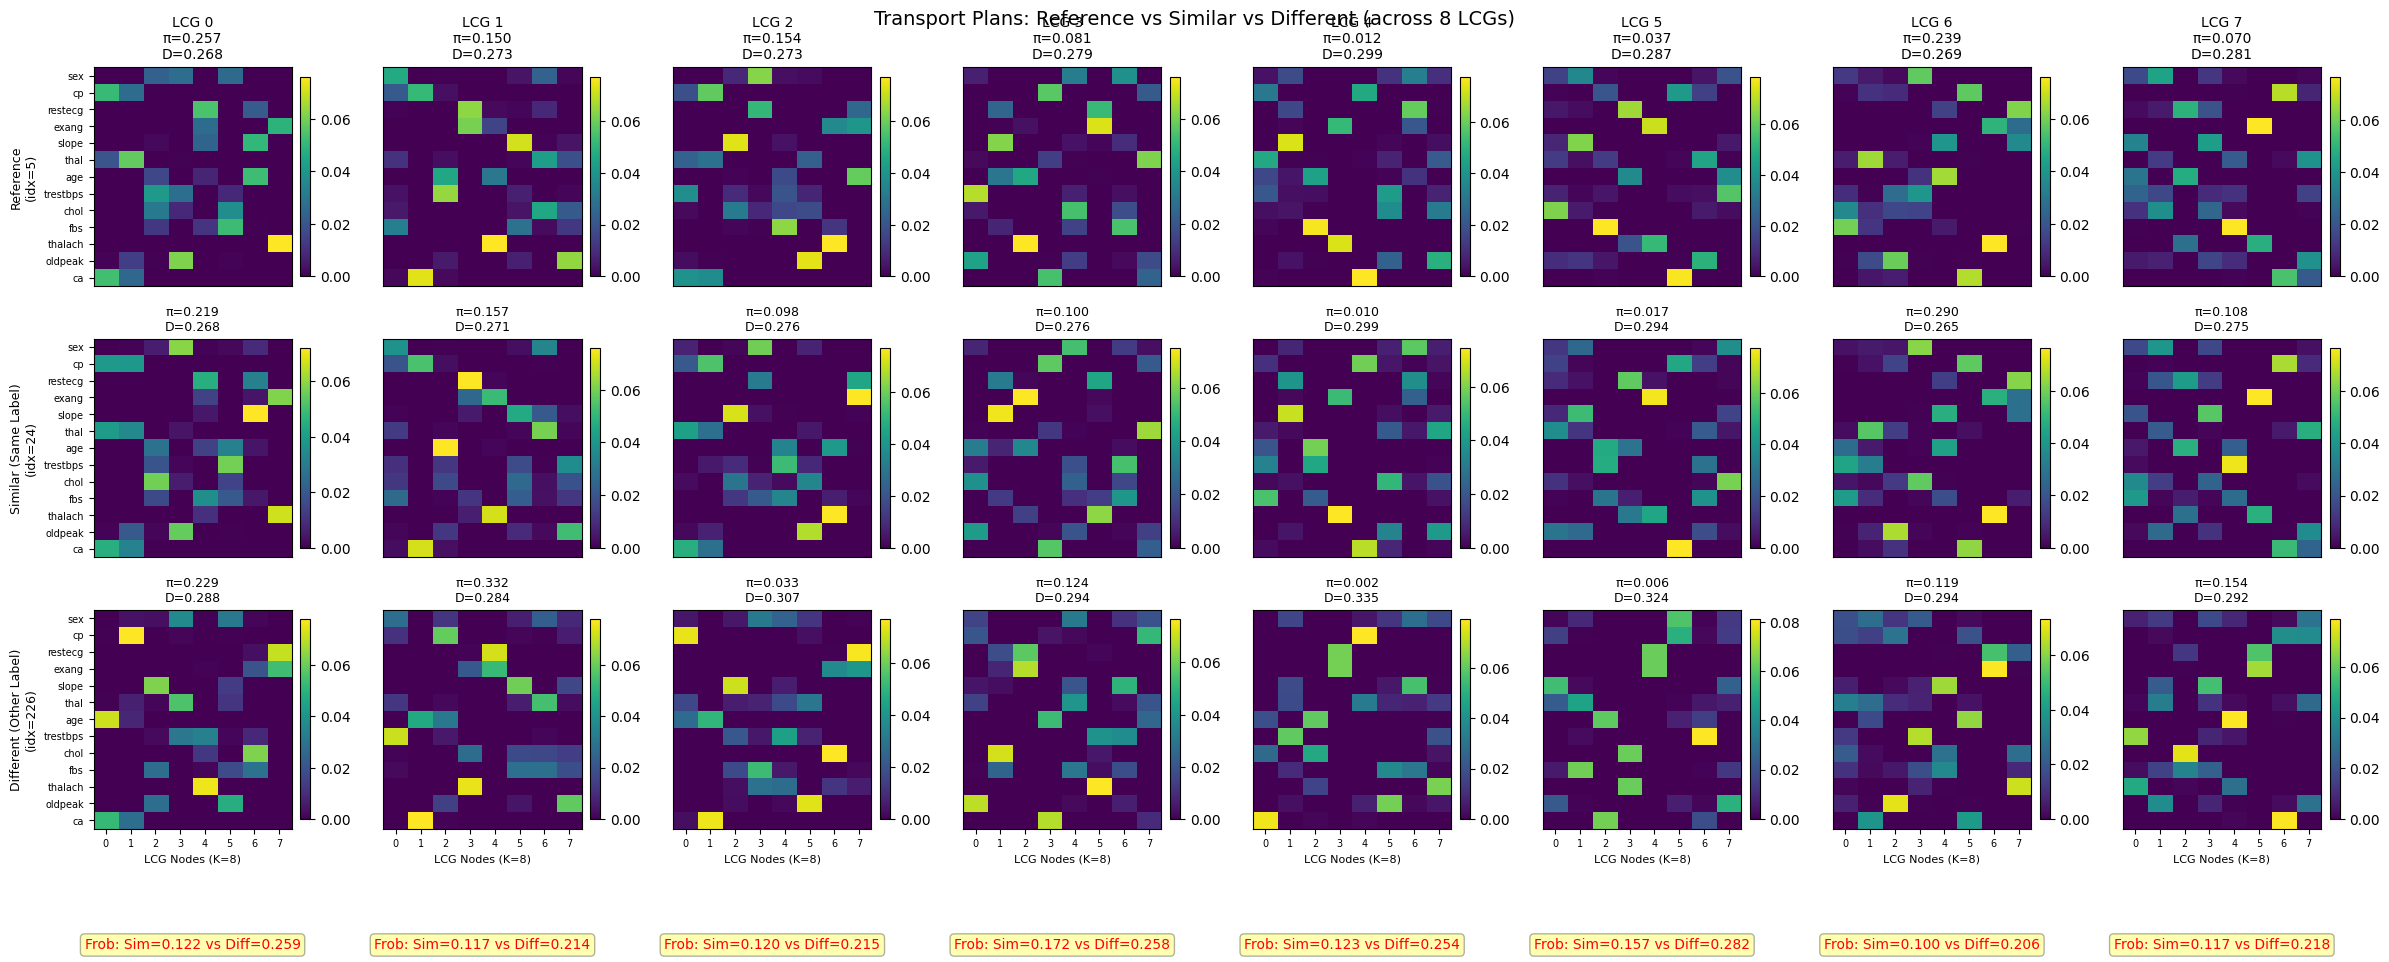

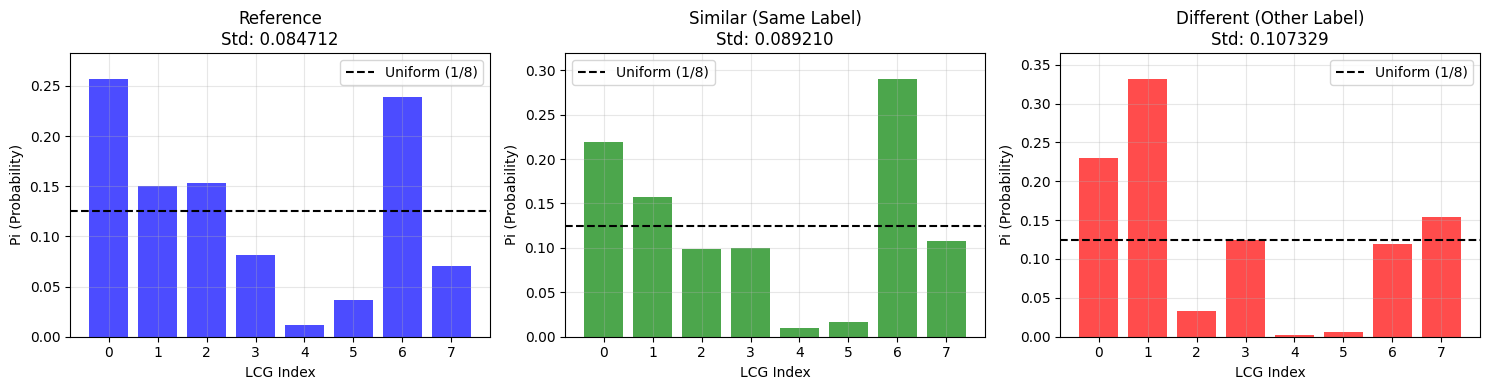

In [18]:
src = sources[2]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

In [19]:
sources[3]

'Erbil_Cardiovascular_Health_Dataset'

Total samples collected: 287
Node embedding shape: (20, 768)
Affinity shape: (20, 20)
Computing Frobenius distances...
Embedding distance matrix shape: (287, 287)
Affinity distance matrix shape: (287, 287)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 5 (label: 1)

Most similar (SAME label): 222 (label: 1)
  → distance: 0.4808

Most different (OTHER label): 68 (label: 0)
  → distance: 2.0637

Computing Transport Plans for 3 samples x 8 LCGs...


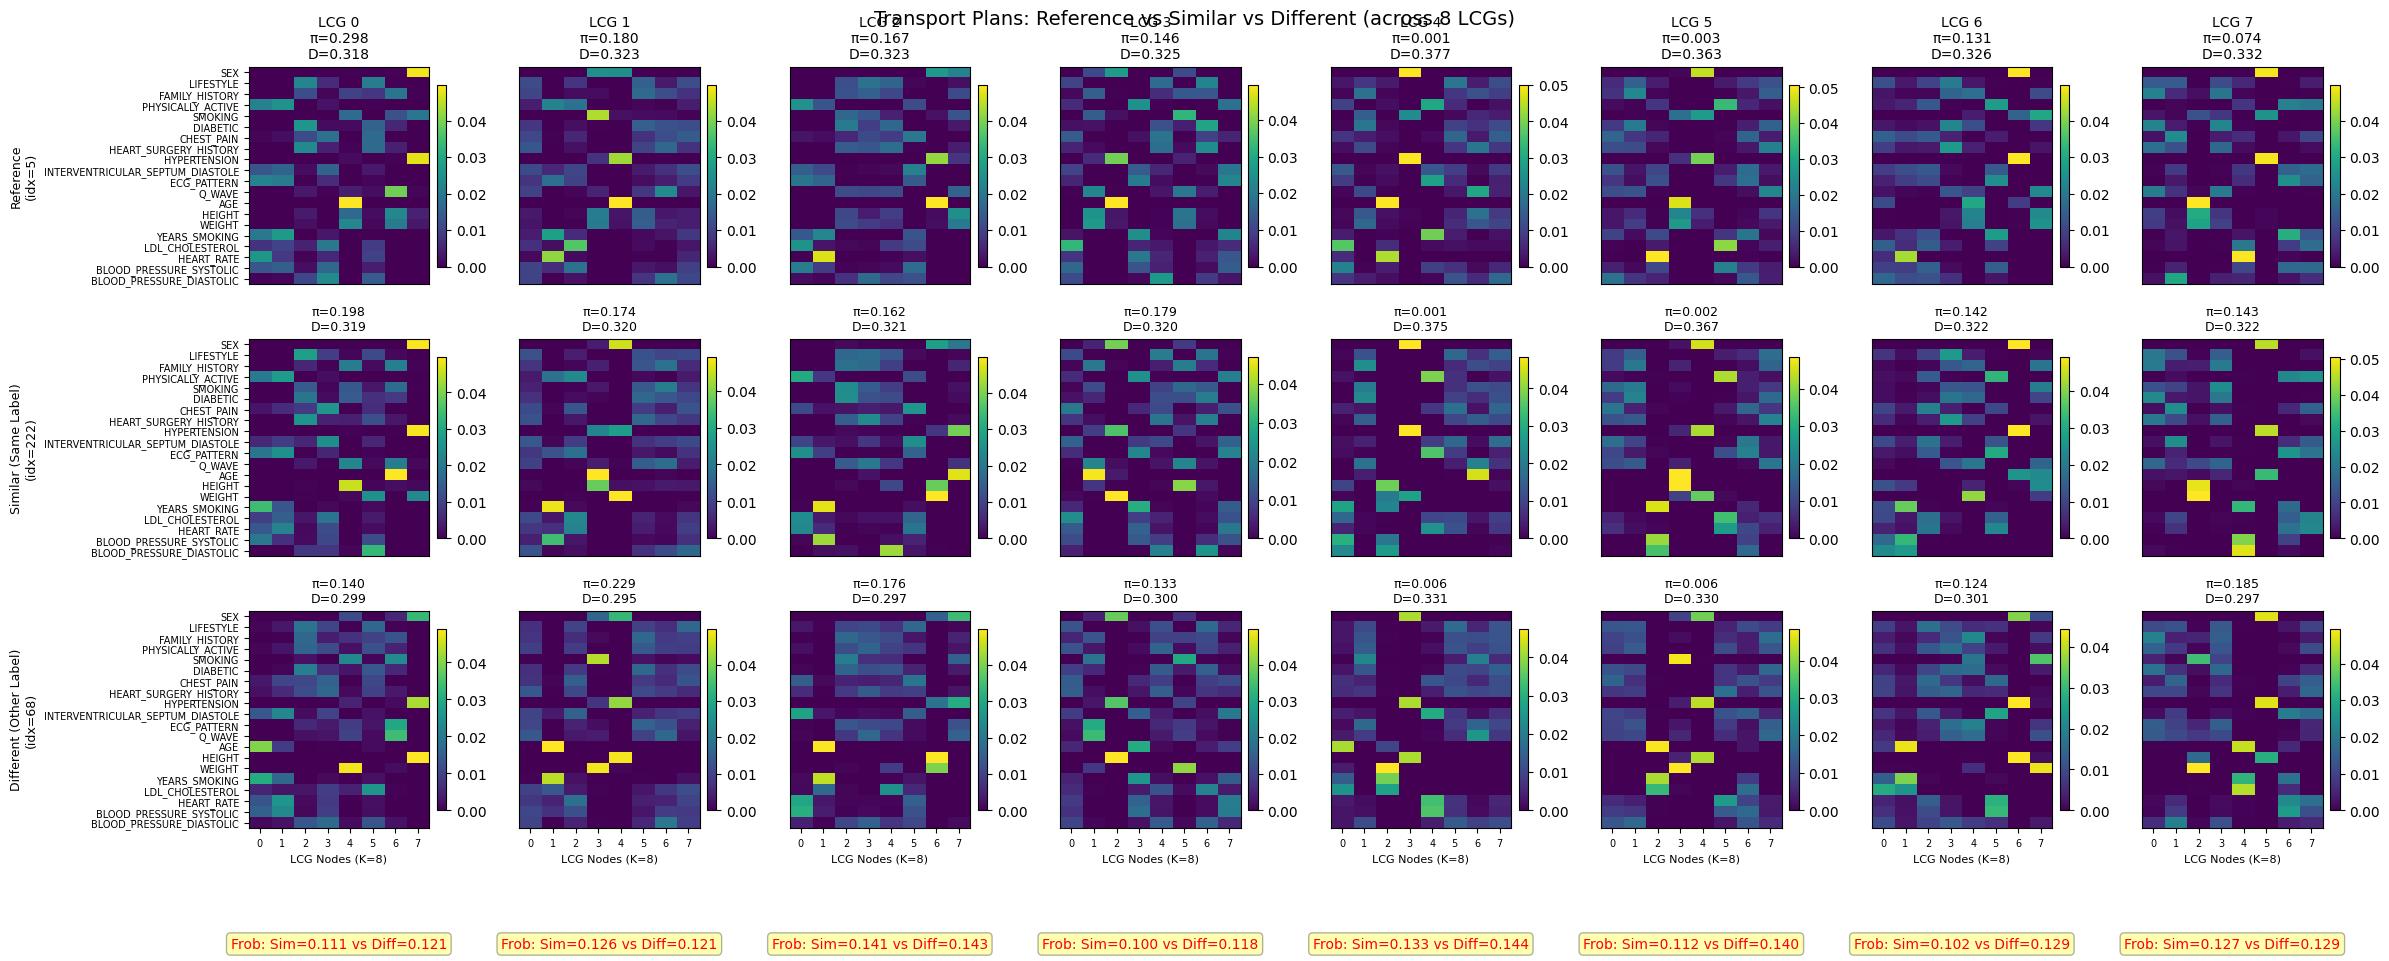

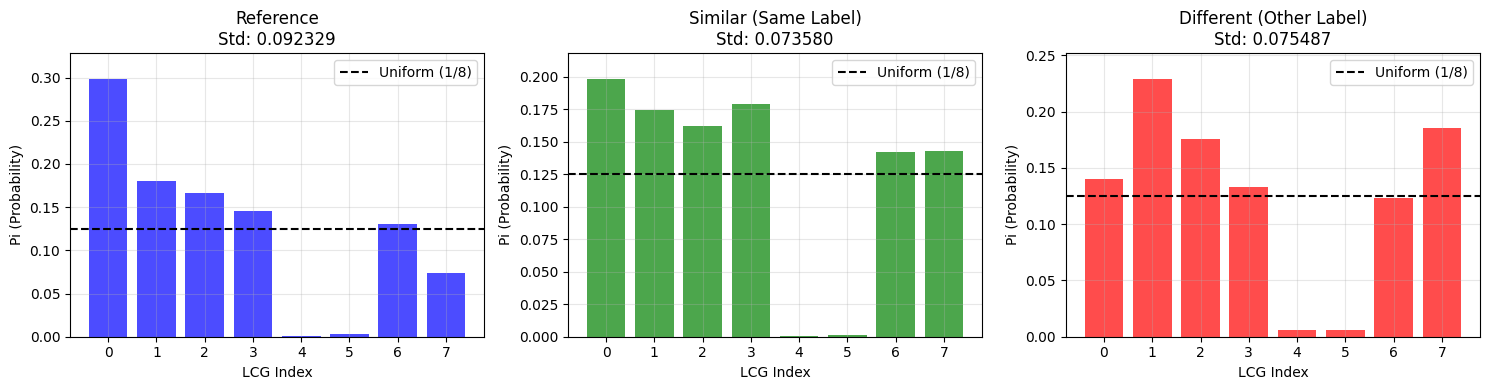

In [20]:
src = sources[3]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=5,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  # 네가 이미 갖고 있으면
)

Total samples collected: 1319
Node embedding shape: (8, 768)
Affinity shape: (8, 8)
Computing Frobenius distances...
Embedding distance matrix shape: (1319, 1319)
Affinity distance matrix shape: (1319, 1319)

=== Analysis based on affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 0)

Most similar (SAME label): 1219 (label: 0)
  → distance: 0.0895

Most different (OTHER label): 37 (label: 1)
  → distance: 0.7673

Computing Transport Plans for 3 samples x 8 LCGs...


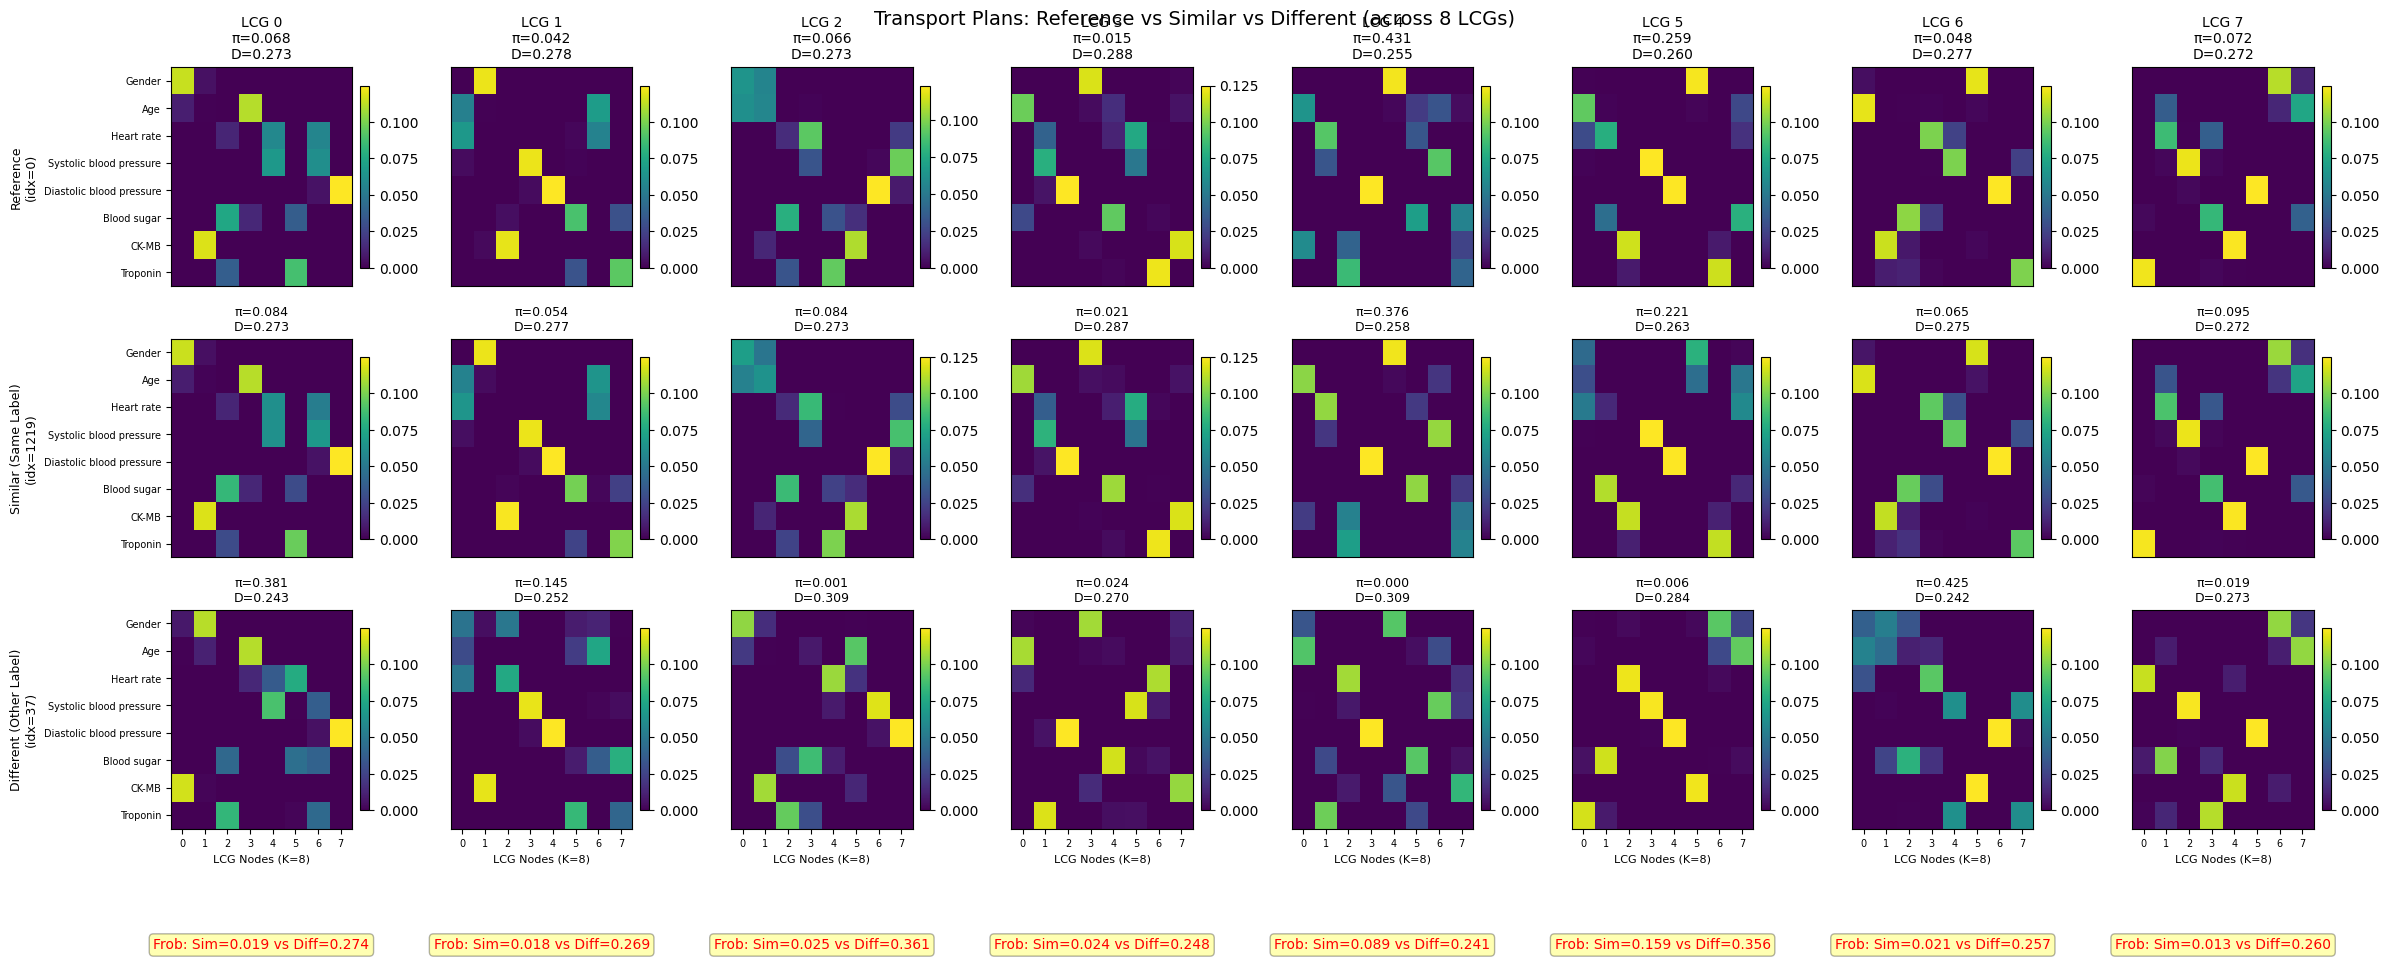

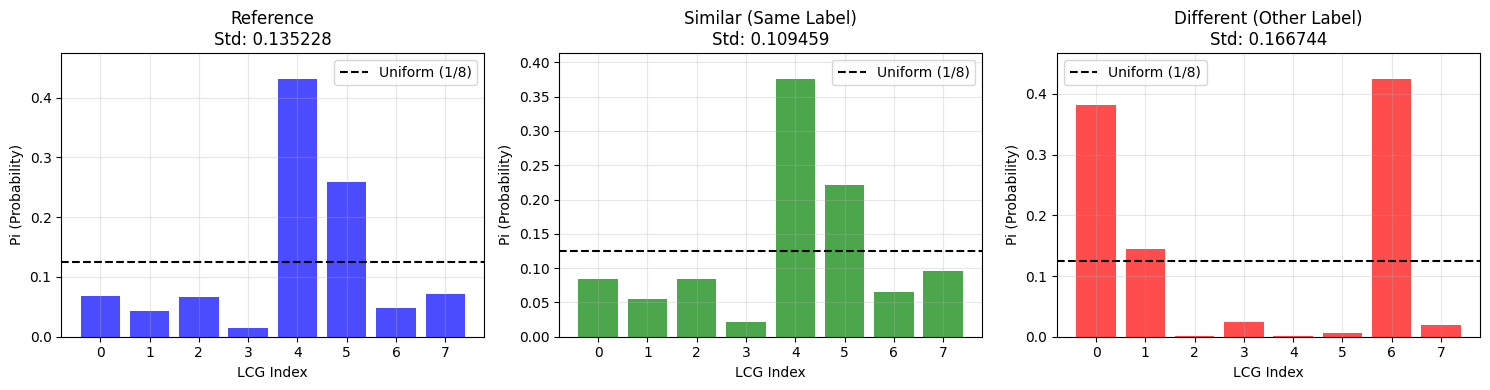

In [21]:
src = sources[0]
loader = loaders[src]
out = run_transport_plan_wrapup(
    model=model,
    loader=loader,
    device=device,
    source_name=src,
    reference_idx=0,
    distance_mode="affinity",
    extract_feature_names_fn=extract_feature_names  
)

## Qualitative - Transport Plan, Coordinate (2)

1. 설명
- Reference : 기준 샘플
- Similar : 같은 Label, attention이 가장 유사한 샘플
- Different : 다른 Label, attention이 가장 유사한 샘플

2. 목적
attention 구조는 비슷한데 label만 다른 쌍을 찾아서, coordinate의 차이를 잡아내자. 
- reference + Similar : attention도 비슷하고 label도 같으면 -> coordinate도 비슷해야 
- reference + Different : attention도 비슷하고 label은 다름 -> coordiante는 달라야

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 네 환경에서 이미 쓰던 것 그대로
# from ot.batch import solve_gromov_batch


# =========================================================
# (A) 너가 준 그대로: loader -> embeddings / affinities / labels 수집
# =========================================================
@torch.no_grad()
def collect_all_samples_from_source(model, loader, device, extract_feature_names_fn):
    all_embeddings = []
    all_affinities = []
    all_affinities_raw = []  # 시각화용 raw attention 보존
    all_labels = []
    all_feature_names = []

    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name  = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        B = value.size(0)

        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
        last_att = None

        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        last_att = last_att[:, 0, :, :]  # [B,T,T]

        var_names = extract_feature_names_fn(batch)

        for b in range(B):
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()
            raw_attn = last_att[b, 1:, 1:].detach().cpu()  # [N,N] raw attention

            # === 모델과 동일한 정규화 ===
            log_attn = -torch.log(raw_attn.clamp_min(1e-8))
            q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            P_basis = (log_attn / q90).clamp_max(1.0)  # [0, 1] 범위

            all_embeddings.append(node_emb)
            all_affinities.append(P_basis.numpy())        # FGW용: 모델과 동일
            all_affinities_raw.append(raw_attn.numpy())    # 시각화용: raw attention
            all_labels.append(int(batch['y'][b].item()))
            all_feature_names.append(var_names)

    return all_embeddings, all_affinities, all_affinities_raw, all_labels, all_feature_names



# =========================================================
# (B) 너가 준 그대로: Frobenius distance
# =========================================================
def compute_frobenius_distances(embeddings, affinities):
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff

            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff

    return emb_distances, aff_distances


# =========================================================
# (C) 핵심 수정: reference 기준
#   - similar: 같은 label 중 affinity distance 최소
#   - other  : 다른 label 중 affinity distance 최소 (attention은 유사, label만 다름)
# =========================================================
def find_similar_same_and_similar_other_by_label(reference_idx, distances, labels):
    n = len(labels)
    ref_label = labels[reference_idx]

    same_mask = np.array([labels[i] == ref_label for i in range(n)], dtype=bool)
    same_mask[reference_idx] = False

    other_mask = np.array([labels[i] != ref_label for i in range(n)], dtype=bool)

    if same_mask.sum() == 0:
        raise RuntimeError(f"No same-label sample exists for reference label={ref_label}")
    if other_mask.sum() == 0:
        raise RuntimeError("No other-label sample exists")

    d_same = distances[reference_idx].copy()
    d_same[~same_mask] = np.inf
    similar_idx = int(np.argmin(d_same))

    d_other = distances[reference_idx].copy()
    d_other[~other_mask] = np.inf
    other_idx = int(np.argmin(d_other))  # <-- '다른 레이블인데 attention 유사'를 강제

    return similar_idx, other_idx


# =========================================================
# (D) 너가 준 그대로: transport plan + pi
# =========================================================
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities, device):
    import torch.nn.functional as F
    
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)
        
        N = src_feat.shape[1]
        
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)
        
        lcg_feat_exp = lcg_feat
        lcg_str_exp = lcg_struct
        
        if feat_distance == 'cosine':
            src_norm = F.normalize(src_feat_exp, dim=-1)
            tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
            cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
            M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
        else:
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            M_raw = dist_sq / float(D)
            q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
            M_cost = M_raw / q90
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = float(model.graph_quantizer.alpha)
        reg = float(model.graph_quantizer.reg)
        
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach()  # [M]
        plans = result.plan.detach().cpu().numpy()
        
        # 학습 코드와 동일: raw distance → softmax
        d = distances.unsqueeze(0)  # [1, M]
        soft_tau = float(model.graph_quantizer.soft_tau)
        pi = torch.softmax(-d / soft_tau, dim=1).squeeze(0).cpu().numpy()
        
        all_plans.append(plans)
        all_distances.append(distances.cpu().numpy())
        all_coordinates.append(pi)
    
    return np.array(all_plans), np.array(all_distances), np.array(all_coordinates)


# =========================================================
# (E) 너가 준 그대로: 3x8 plan grid
# =========================================================
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    n_samples = 3
    n_lcgs = plans.shape[1]

    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']

    frob_norms_similar = []
    frob_norms_different = []
    for j in range(n_lcgs):
        plan_ref  = plans[0, j]
        plan_sim  = plans[1, j]
        plan_diff = plans[2, j]
        frob_norms_similar.append(np.linalg.norm(plan_ref - plan_sim, ord='fro'))
        frob_norms_different.append(np.linalg.norm(plan_ref - plan_diff, ord='fro'))

    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            plan = plans[i, j]
            pi   = coordinates[i, j]
            dist = distances[i, j]

            im = ax.imshow(plan, cmap='viridis', aspect='auto')

            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)

            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]})', fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])

            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])

            if i == n_samples - 1:
                ax.text(
                    0.5, -0.5, f'Frob: Sim={frob_norms_similar[j]:.3f} vs Diff={frob_norms_different[j]:.3f}',
                    transform=ax.transAxes,
                    ha='center', va='top',
                    fontsize=10, color='red',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
                )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)',
                 fontsize=14, y=0.99)
    plt.show()


# =========================================================
# (F) 요청한 2x3: (위) coordinate bar / (아래) attention map
#   - coordinate 색: 파란/초록/빨강 (원래 코드 그대로)
#   - y-limit / uniform line / grid도 원래 코드 그대로
#   - [수정] colorbar가 attention map 위에 겹치지 않게: 오른쪽에 전용 cax를 만들어서 밖으로 뺌
# =========================================================
def plot_coord_and_attention_2x3(sample_indices, coordinates, affinities_raw, labels, var_names, title_prefix=""):
    M = coordinates.shape[1]

    # raw attention 그대로 사용 (0~1, 높을수록 강한 관계)
    atts = [affinities_raw[idx] for idx in sample_indices]

    vmin = min(float(np.min(a)) for a in atts)
    vmax = max(float(np.max(a)) for a in atts)

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))

    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    colors = ['blue', 'green', 'red']

    for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
        ax = axes[0, i]
        ax.bar(range(M), coord, color=color, alpha=0.7)
        ax.set_xlabel('LCG Index')
        ax.set_ylabel('Pi (Probability)')
        ax.set_title(f'{name}\nStd: {coord.std():.6f}')
        ax.set_ylim([0, max(0.2, float(coord.max()) * 1.1)])
        ax.axhline(y=1/M, color='black', linestyle='--', label=f'Uniform (1/{M})')
        ax.legend()
        ax.grid(True, alpha=0.3)

    ims = []
    for i in range(3):
        ax = axes[1, i]
        im = ax.imshow(atts[i], cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        ims.append(im)
        ax.set_title('Attention (Var-Var)')
        ax.set_xlabel('variables')
        ax.set_ylabel('variables')
        ax.set_xticks(range(len(var_names)))
        ax.set_yticks(range(len(var_names)))
        ax.set_xticklabels(var_names, rotation=90, fontsize=7)
        ax.set_yticklabels(var_names, fontsize=7)

    fig.suptitle(f'{title_prefix} 2x3: Coordinate(pi) + Attention map', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])

    pos = axes[1, 2].get_position()
    cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.012, pos.height])
    fig.colorbar(ims[-1], cax=cax)

    plt.show()


# =========================================================
# (G) WRAP-UP: 한 방에 실행
#   reference 기준:
#     - similar: same label & attention 유사(aff dist 최소)
#     - other  : other label & attention 유사(aff dist 최소)
# =========================================================
def run_ref_sim_other_attention_viz(
    model, loader, device, source_name,
    extract_feature_names_fn, reference_idx=0
):
    print(f"Collecting samples from source: {source_name}")
    embeddings, affinities, affinities_raw, labels, feature_names_list = collect_all_samples_from_source(
        model=model, loader=loader, device=device,
        extract_feature_names_fn=extract_feature_names_fn
    )

    print(f"Total samples collected: {len(embeddings)}")
    print(f"Node embedding shape: {embeddings[0].shape}")
    print(f"Affinity shape: {affinities[0].shape}")

    print("Computing Frobenius distances...")
    emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

    similar_idx, other_idx = find_similar_same_and_similar_other_by_label(
        reference_idx=reference_idx,
        distances=aff_distances,
        labels=labels
    )

    print("\n=== Picked indices ===")
    print(f"Reference: {reference_idx} (label={labels[reference_idx]})")
    print(f"Similar (SAME label, min aff-dist): {similar_idx} (label={labels[similar_idx]}), dist={aff_distances[reference_idx, similar_idx]:.4f}")
    print(f"Other  (OTHER label, min aff-dist): {other_idx} (label={labels[other_idx]}), dist={aff_distances[reference_idx, other_idx]:.4f}")

    sample_indices = [int(reference_idx), int(similar_idx), int(other_idx)]

    var_names = feature_names_list[0]
    if var_names is None:
        N = embeddings[0].shape[0]
        var_names = [f"v{i}" for i in range(N)]

    # FGW는 정규화된 affinities 사용
    plans, distances, coordinates = compute_transport_plans_for_samples(
        model=model,
        sample_indices=sample_indices,
        embeddings=embeddings,
        affinities=affinities,  # ← 정규화된 P_basis
        device=device
    )

    plot_transport_plans_grid(
        plans=plans, coordinates=coordinates, distances=distances,
        sample_indices=sample_indices, labels=labels, var_names=var_names
    )

    # 시각화는 raw attention 사용
    plot_coord_and_attention_2x3(
        sample_indices=sample_indices,
        coordinates=coordinates,
        affinities_raw=affinities_raw,  # ← raw attention
        labels=labels, var_names=var_names,
        title_prefix=f"[{source_name}]"
    )

    return {
        "embeddings": embeddings,
        "affinities": affinities,
        "affinities_raw": affinities_raw,
        "labels": labels,
        "feature_names_list": feature_names_list,
        "aff_distances": aff_distances,
        "sample_indices": sample_indices,
        "plans": plans,
        "distances": distances,
        "coordinates": coordinates,
        "var_names": var_names
    }




Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)
Computing Frobenius distances...

=== Picked indices ===
Reference: 0 (label=1)
Similar (SAME label, min aff-dist): 981 (label=1), dist=0.0872
Other  (OTHER label, min aff-dist): 508 (label=0), dist=0.1933


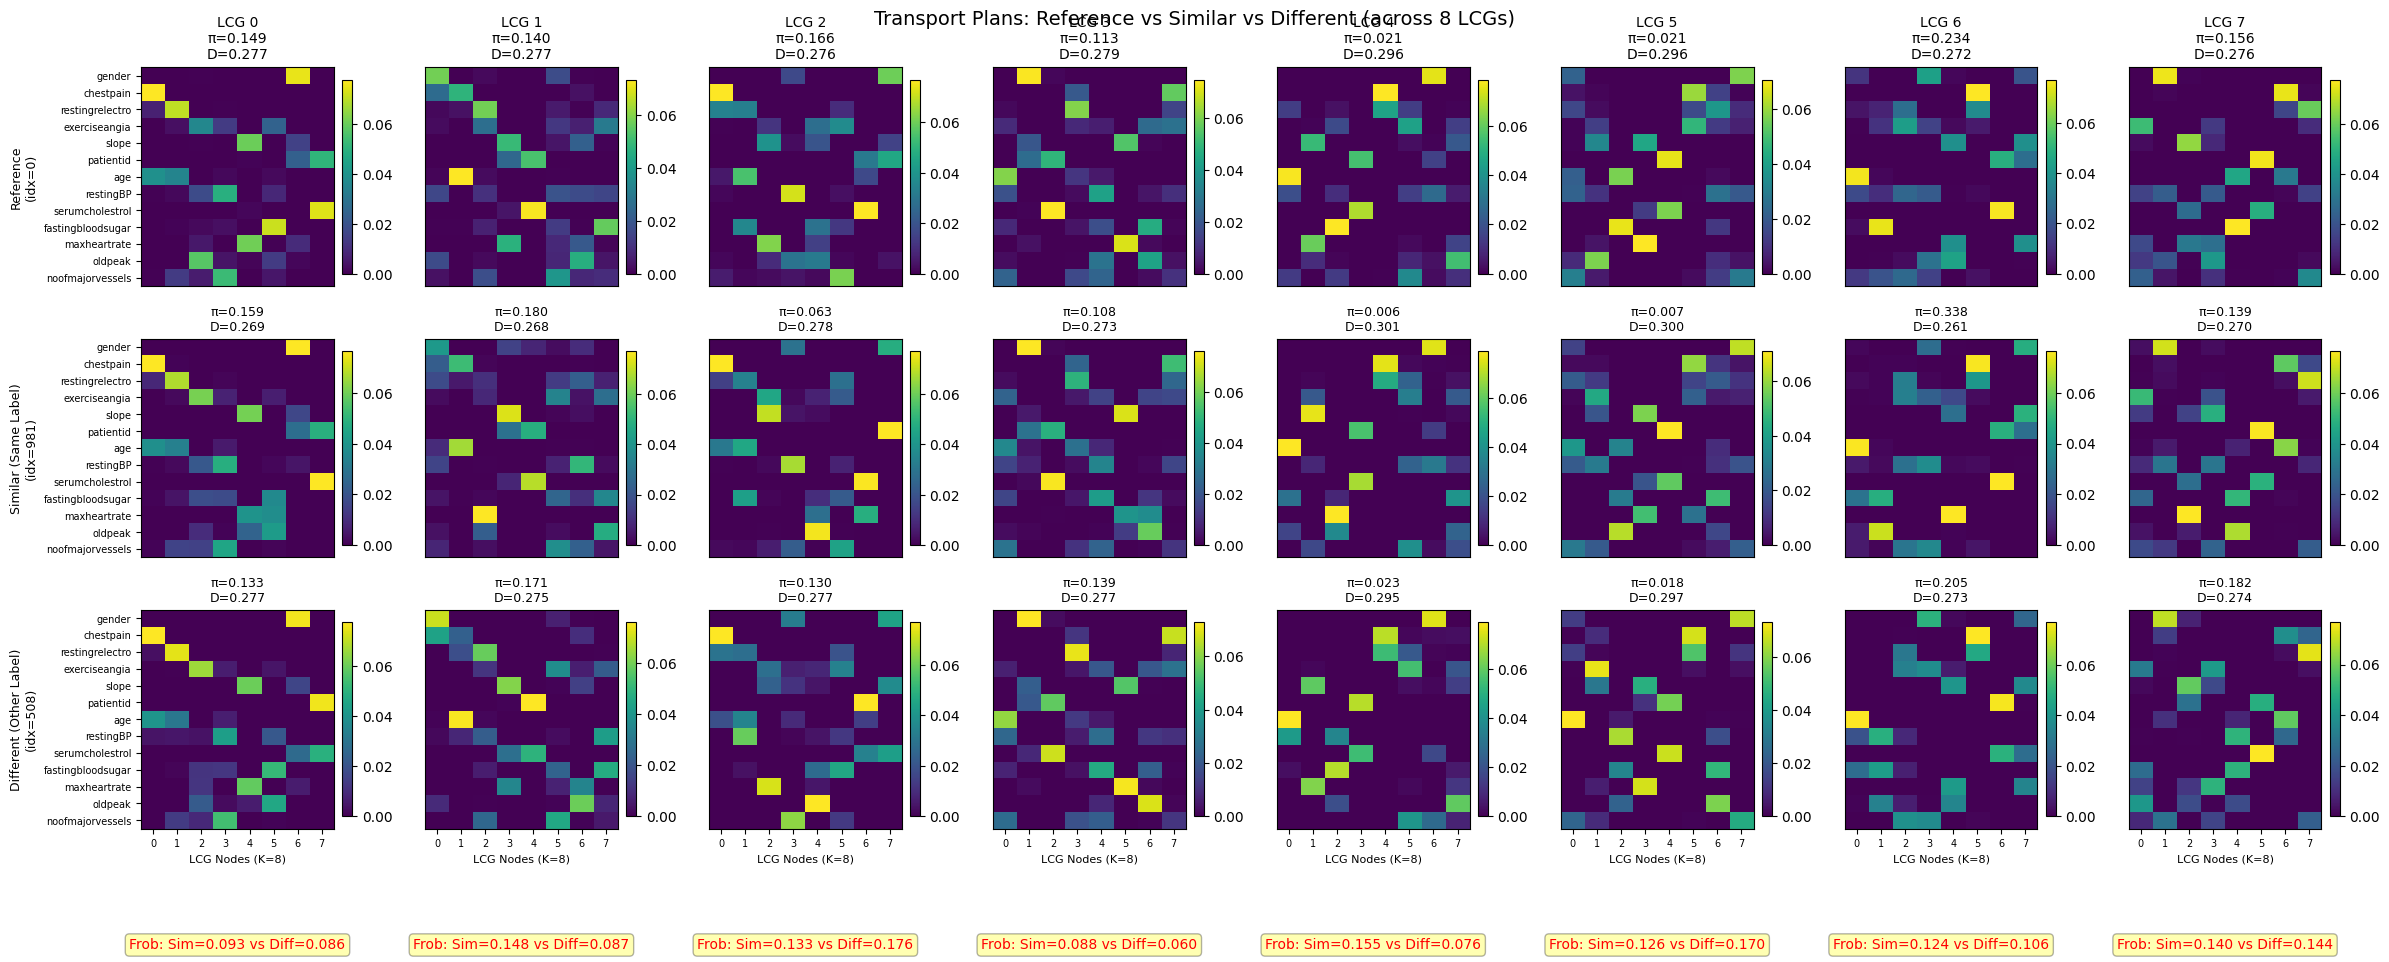

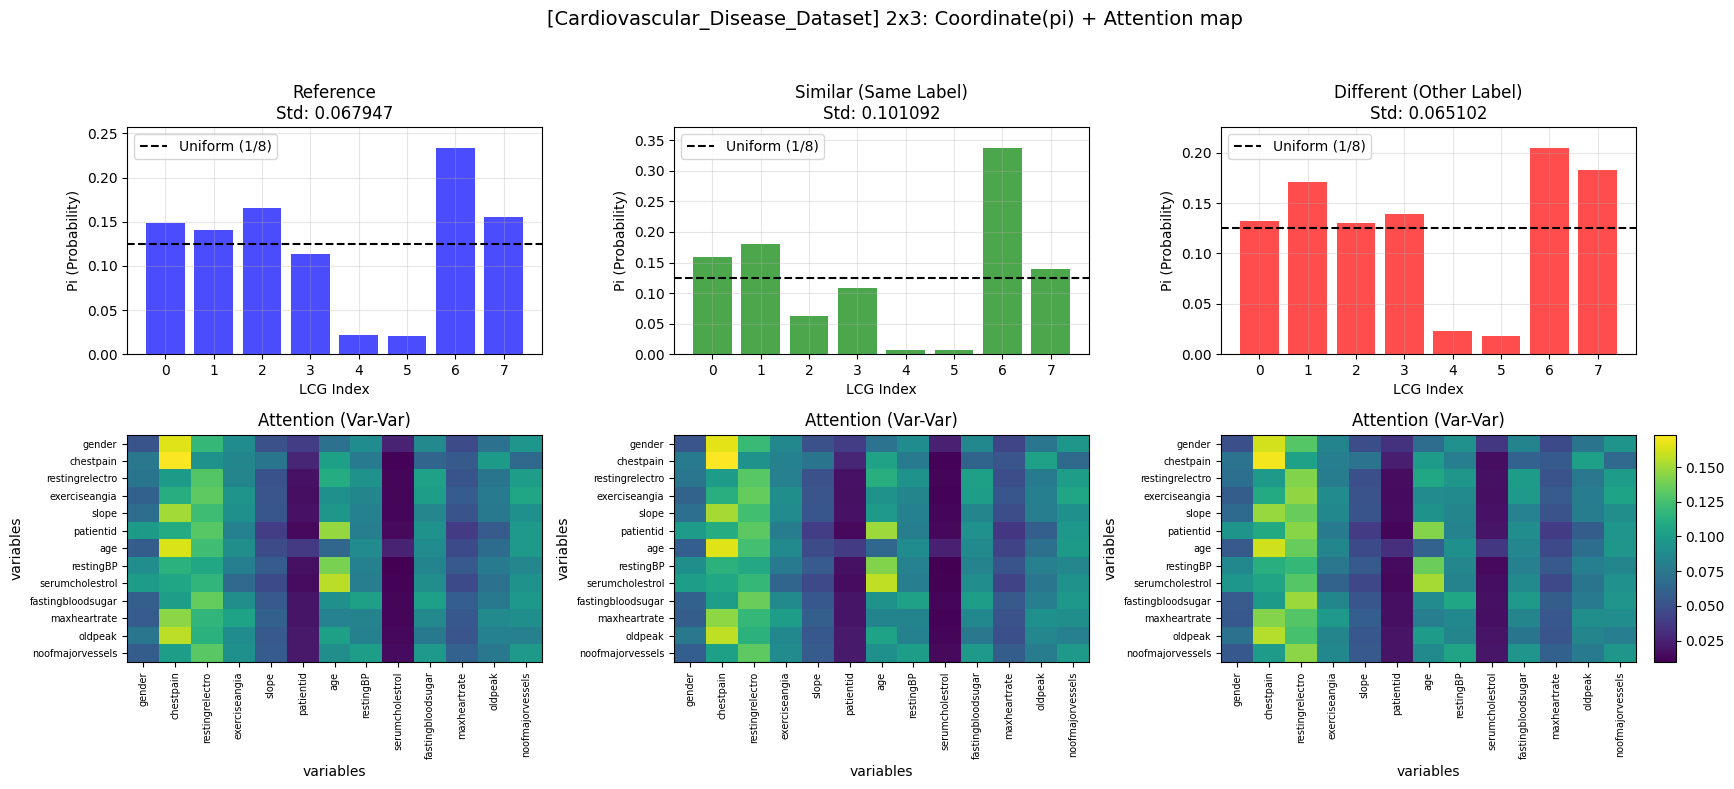

In [23]:

# =========================================================
# 실행 예시
# =========================================================
src = sources[1]
loader = loaders[src]
out = run_ref_sim_other_attention_viz(
    model=joint_model_pretrain,
    loader=loader,
    device=device,
    source_name=src,
    extract_feature_names_fn=extract_feature_names,
    reference_idx=0
)

## 3. Coordinate Argmax 

- 각 coordinate의 entry의 argmax마다 어떤 샘플이 찍히는지를 살펴본다.
- 한 SOurce에 대해 Attention map을 순차적으로 본다.

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def collect_pi_attn_for_source(model, loader, device, extract_feature_names_fn):
    """한 source에서 pi, y, raw attention, feature names 수집"""
    model.eval()
    model.args.use_lcg = True

    all_pis, all_ys, all_atts, all_names = [], [], [], []

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        _ = model.predict(batch_t, return_all=True)
        pi = model.graph_quantizer.last_pi

        name_embeddings, value_embeddings = [], []
        if all(k in batch_t for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            name_embeddings.append(batch_t['cat_name_embeddings'])
            value_embeddings.append(batch_t['cat_value_embeddings'])
        if all(k in batch_t for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            name_embeddings.append(batch_t['num_name_embeddings'])
            value_embeddings.append(batch_t['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        B = value.size(0)

        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
        last_att = None
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        last_att = last_att[:, 0, 1:, 1:].detach().cpu().numpy()  # [B, N, N]
        var_names = extract_feature_names_fn(batch_t)

        for b in range(B):
            all_pis.append(pi[b].detach().cpu().numpy())
            all_ys.append(int(batch_t['y'][b].item()))
            all_atts.append(last_att[b])
            all_names.append(var_names)

    return np.stack(all_pis), np.array(all_ys), all_atts, all_names


def plot_argmax_attention(model, loaders, device, source_name,
                          extract_feature_names_fn, n_reps=3):
    # loader 찾기
    src_key, loader = None, None
    for k, v in loaders.items():
        if source_name.lower() in k.lower():
            src_key, loader = k, v
            break
    if loader is None:
        print(f"[ERROR] '{source_name}' not found.")
        return

    print(f"Using source: {src_key}")
    pis, ys, atts, names = collect_pi_attn_for_source(
        model, loader, device, extract_feature_names_fn
    )

    M = pis.shape[1]
    argmaxes = pis.argmax(axis=1)
    var_names = names[0]
    N_vars = atts[0].shape[0]

    active_lcgs = sorted(np.unique(argmaxes))
    n_cols = len(active_lcgs)

    print(f"M={M}, Active LCGs: {active_lcgs}")
    for m in active_lcgs:
        mask = (argmaxes == m)
        n_y0 = (ys[mask] == 0).sum()
        n_y1 = (ys[mask] == 1).sum()
        print(f"  LCG{m}: N={mask.sum()}, y=0:{n_y0}, y=1:{n_y1}")

    # mean attention (Frobenius 분석용)
    mean_atts = {}
    for m in active_lcgs:
        mask = (argmaxes == m)
        idx_group = np.where(mask)[0]
        att_stack = np.stack([atts[i] for i in idx_group])
        mean_atts[m] = att_stack.mean(axis=0)

    # attention shared scale (개별 샘플 기준)
    all_att_vals = [atts[i] for i in range(len(atts))]
    vmin = min(a.min() for a in all_att_vals)
    vmax = max(a.max() for a in all_att_vals)

    # pi y-limit
    group_mean_pis = []
    for m in active_lcgs:
        mask = (argmaxes == m)
        group_mean_pis.append(pis[mask].mean(axis=0))
    pi_ymax = max(p.max() for p in group_mean_pis) + 0.02

    # --- Layout: (1 + n_reps) rows × n_cols ---
    n_rows = 1 + n_reps
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.5 * n_rows))
    if n_cols == 1:
        axes = axes.reshape(n_rows, 1)

    for ci, m in enumerate(active_lcgs):
        mask = (argmaxes == m)
        idx_group = np.where(mask)[0]
        n_group = len(idx_group)
        n_y0 = (ys[mask] == 0).sum()
        n_y1 = (ys[mask] == 1).sum()
        mean_pi = pis[mask].mean(axis=0)
        mean_att = mean_atts[m]

        # centroid에서 가까운 순으로 정렬
        frob_dists = np.array([np.linalg.norm(atts[i] - mean_att, ord='fro') for i in idx_group])
        sorted_local = np.argsort(frob_dists)
        n_show = min(n_reps, n_group)

        # --- Row 0: mean pi ---
        ax = axes[0, ci]
        colors = ['steelblue'] * M
        colors[m] = 'orangered'
        ax.bar(np.arange(M), mean_pi, color=colors)
        ax.axhline(1.0 / M, linestyle="--", color="black")
        ax.set_ylim(0, pi_ymax)
        ax.set_title(f"argmax=LCG{m} | N={n_group}\ny0:{n_y0} y1:{n_y1}", fontsize=11)
        ax.set_xlabel("LCG index")
        ax.set_ylabel("mean pi")
        ax.grid(True, alpha=0.25)

        # --- Row 1~n_reps: individual sample attention ---
        for r in range(n_reps):
            ax = axes[1 + r, ci]
            if r >= n_show:
                ax.axis("off")
                continue

            local_idx = sorted_local[r]
            g_idx = idx_group[local_idx]
            sample_att = atts[g_idx]
            sample_y = ys[g_idx]
            sample_pi_top = pis[g_idx, m]

            # vmin/vmax 제거 → 각 샘플 자체 스케일
            im = ax.imshow(sample_att, cmap='viridis', aspect='auto')
            ax.set_title(f"idx={g_idx} | y={sample_y} | π{m}={sample_pi_top:.2f}", fontsize=9)
            ax.set_xticks(range(N_vars))
            ax.set_yticks(range(N_vars))
            ax.set_xticklabels(var_names, rotation=90, fontsize=6)
            ax.set_yticklabels(var_names, fontsize=6)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    fig.suptitle(f"[{src_key}] Argmax-based Attention | Active LCGs: {active_lcgs}",
                 fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # --- Frobenius 정량 분석 ---
    active_with_samples = [m for m in range(M) if (argmaxes == m).sum() > 0]
    print(f"\n=== Attention Frobenius Analysis [{src_key}] ===")

    print("\n[Inter-group] Mean Attention Frobenius Distance:")
    for i, m1 in enumerate(active_with_samples):
        for m2 in active_with_samples[i+1:]:
            d = np.linalg.norm(mean_atts[m1] - mean_atts[m2], ord='fro')
            print(f"  LCG{m1} vs LCG{m2}: {d:.4f}")

    print("\n[Intra-group] Mean Frobenius to group centroid:")
    intra_dists = {}
    for m in active_with_samples:
        idx_group = np.where(argmaxes == m)[0]
        dists = [np.linalg.norm(atts[i] - mean_atts[m], ord='fro') for i in idx_group]
        intra_dists[m] = np.mean(dists)
        print(f"  LCG{m}: mean_intra={np.mean(dists):.4f}, std={np.std(dists):.4f}")

    print("\n[Ratio] inter / mean(intra):  (>1 = groups are distinguishable)")
    mean_intra = np.mean(list(intra_dists.values()))
    for i, m1 in enumerate(active_with_samples):
        for m2 in active_with_samples[i+1:]:
            inter = np.linalg.norm(mean_atts[m1] - mean_atts[m2], ord='fro')
            ratio = inter / (mean_intra + 1e-8)
            status = "✓ distinct" if ratio > 1.0 else "✗ overlapping"
            print(f"  LCG{m1} vs LCG{m2}: ratio={ratio:.4f}  {status}")

    return {"pis": pis, "ys": ys, "atts": atts, "argmaxes": argmaxes,
            "mean_atts": mean_atts, "active_lcgs": active_lcgs}



Using source: Medicaldataset
M=8, Active LCGs: [0, 4, 5, 6, 7]
  LCG0: N=70, y=0:7, y=1:63
  LCG4: N=392, y=0:264, y=1:128
  LCG5: N=330, y=0:83, y=1:247
  LCG6: N=339, y=0:2, y=1:337
  LCG7: N=188, y=0:153, y=1:35


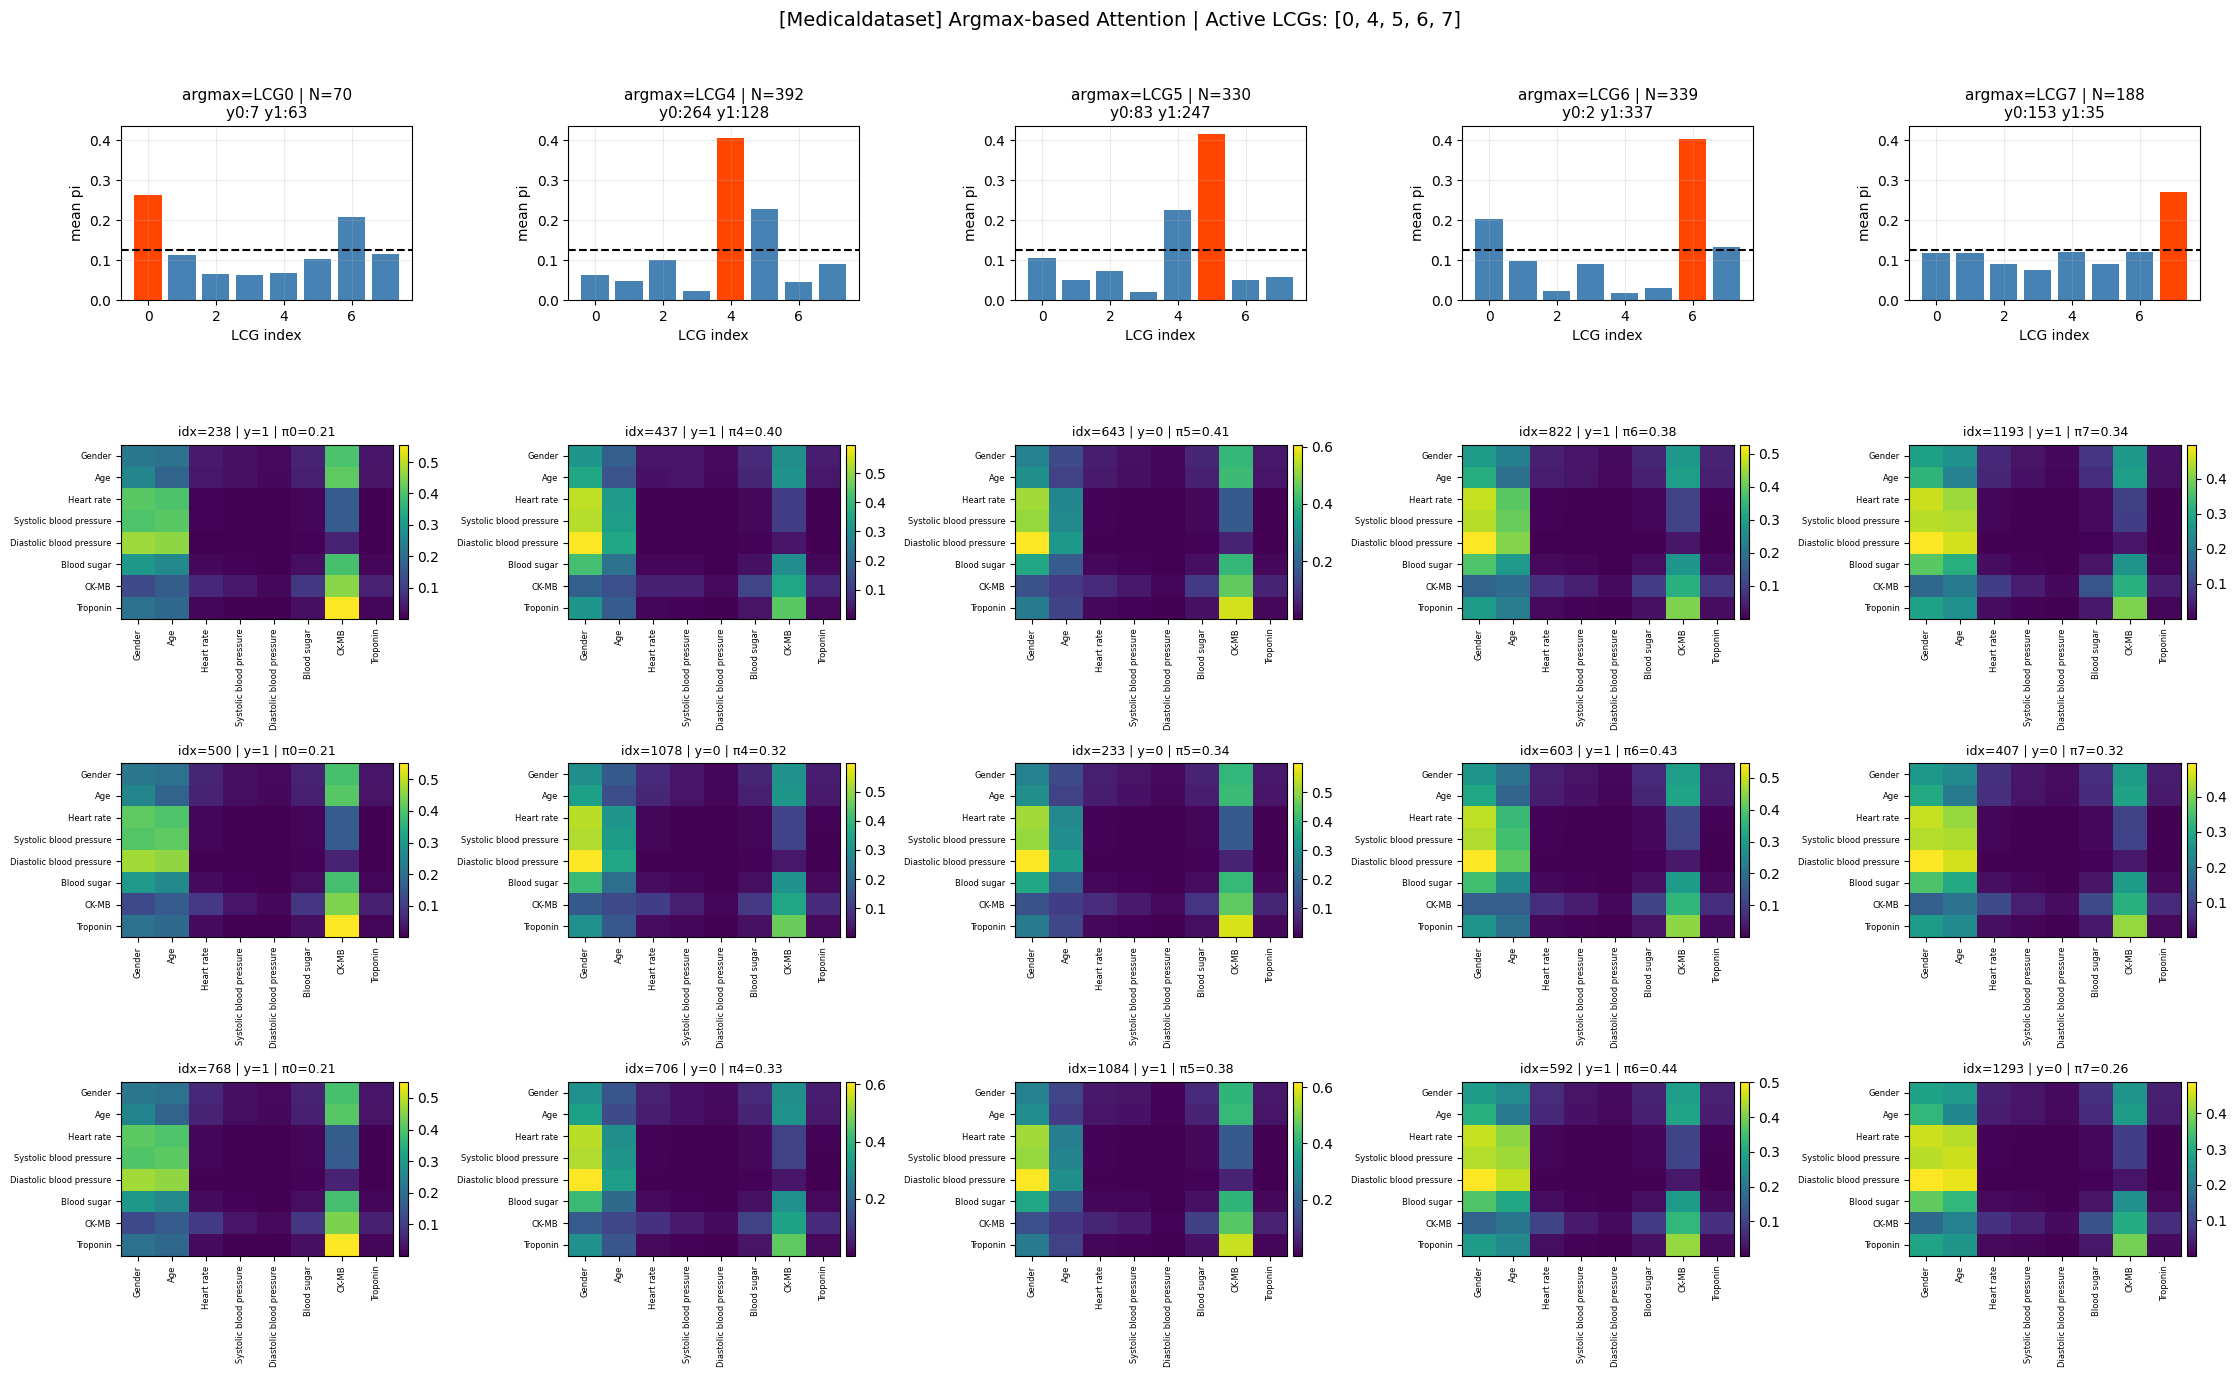


=== Attention Frobenius Analysis [Medicaldataset] ===

[Inter-group] Mean Attention Frobenius Distance:
  LCG0 vs LCG4: 0.4035
  LCG0 vs LCG5: 0.3674
  LCG0 vs LCG6: 0.2646
  LCG0 vs LCG7: 0.3665
  LCG4 vs LCG5: 0.3373
  LCG4 vs LCG6: 0.2027
  LCG4 vs LCG7: 0.2825
  LCG5 vs LCG6: 0.4008
  LCG5 vs LCG7: 0.5374
  LCG6 vs LCG7: 0.1419

[Intra-group] Mean Frobenius to group centroid:
  LCG0: mean_intra=0.2302, std=0.1603
  LCG4: mean_intra=0.3550, std=0.1444
  LCG5: mean_intra=0.2719, std=0.1330
  LCG6: mean_intra=0.3603, std=0.1417
  LCG7: mean_intra=0.2311, std=0.1439

[Ratio] inter / mean(intra):  (>1 = groups are distinguishable)
  LCG0 vs LCG4: ratio=1.3930  ✓ distinct
  LCG0 vs LCG5: ratio=1.2681  ✓ distinct
  LCG0 vs LCG6: ratio=0.9133  ✗ overlapping
  LCG0 vs LCG7: ratio=1.2650  ✓ distinct
  LCG4 vs LCG5: ratio=1.1643  ✓ distinct
  LCG4 vs LCG6: ratio=0.6996  ✗ overlapping
  LCG4 vs LCG7: ratio=0.9751  ✗ overlapping
  LCG5 vs LCG6: ratio=1.3835  ✓ distinct
  LCG5 vs LCG7: ratio=1.

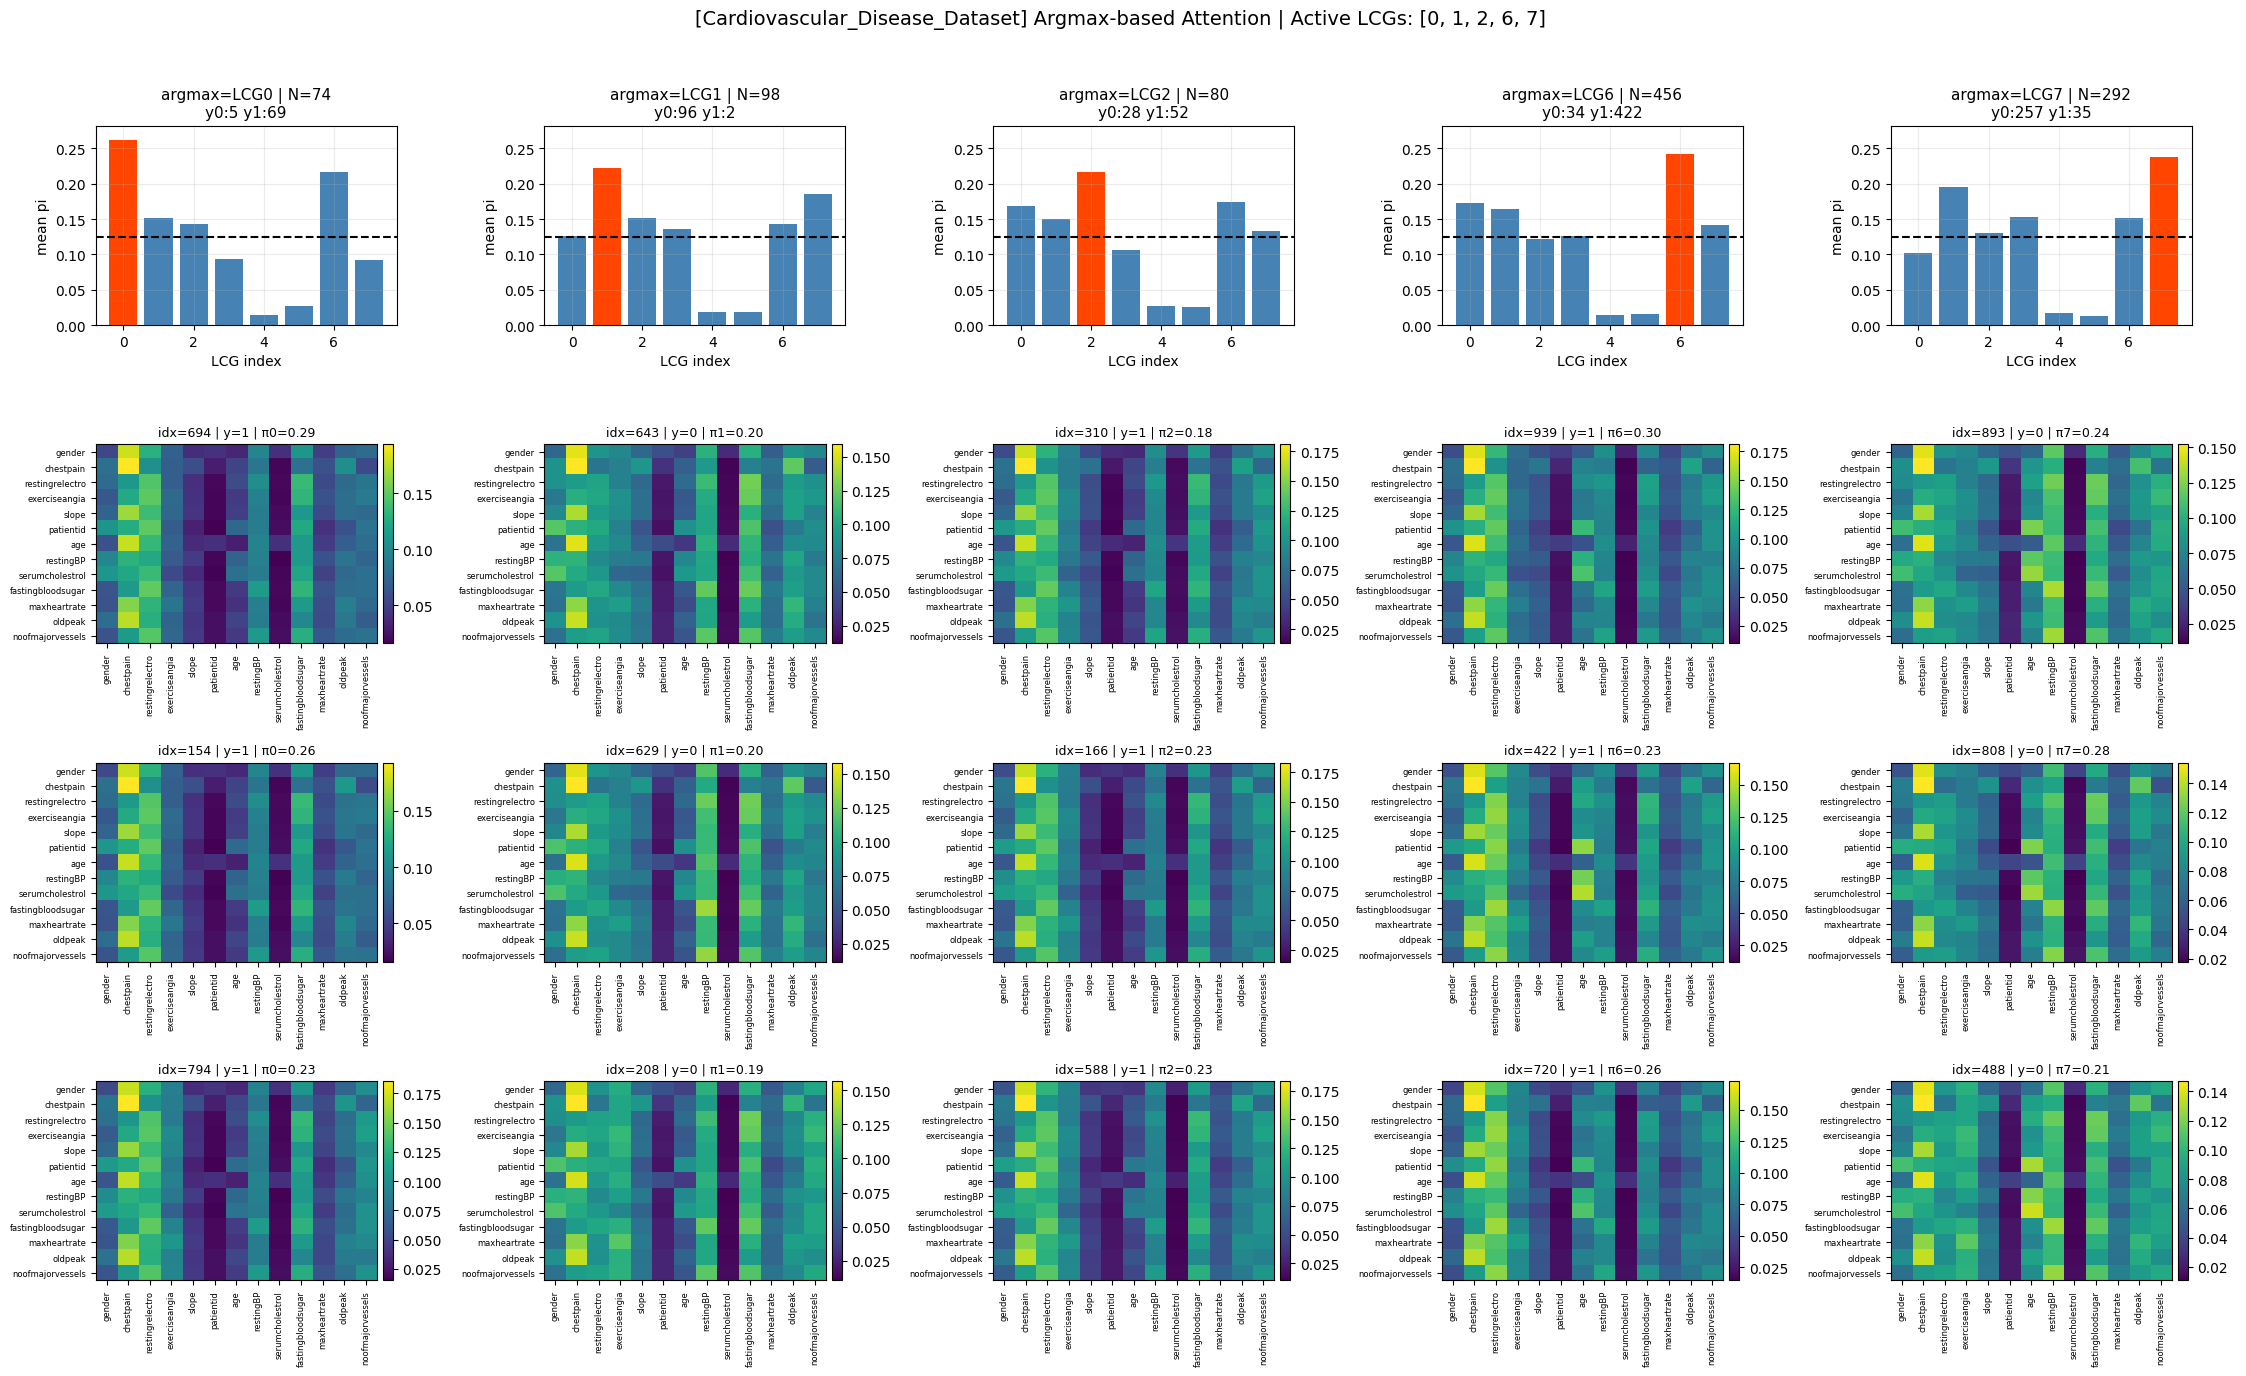


=== Attention Frobenius Analysis [Cardiovascular_Disease_Dataset] ===

[Inter-group] Mean Attention Frobenius Distance:
  LCG0 vs LCG1: 0.1172
  LCG0 vs LCG2: 0.0933
  LCG0 vs LCG6: 0.1383
  LCG0 vs LCG7: 0.1903
  LCG1 vs LCG2: 0.0823
  LCG1 vs LCG6: 0.1333
  LCG1 vs LCG7: 0.1291
  LCG2 vs LCG6: 0.1155
  LCG2 vs LCG7: 0.1450
  LCG6 vs LCG7: 0.0833

[Intra-group] Mean Frobenius to group centroid:
  LCG0: mean_intra=0.1326, std=0.0557
  LCG1: mean_intra=0.2207, std=0.0678
  LCG2: mean_intra=0.1463, std=0.0466
  LCG6: mean_intra=0.1673, std=0.0386
  LCG7: mean_intra=0.2016, std=0.0553

[Ratio] inter / mean(intra):  (>1 = groups are distinguishable)
  LCG0 vs LCG1: ratio=0.6748  ✗ overlapping
  LCG0 vs LCG2: ratio=0.5372  ✗ overlapping
  LCG0 vs LCG6: ratio=0.7960  ✗ overlapping
  LCG0 vs LCG7: ratio=1.0958  ✓ distinct
  LCG1 vs LCG2: ratio=0.4737  ✗ overlapping
  LCG1 vs LCG6: ratio=0.7673  ✗ overlapping
  LCG1 vs LCG7: ratio=0.7431  ✗ overlapping
  LCG2 vs LCG6: ratio=0.6647  ✗ overlapp

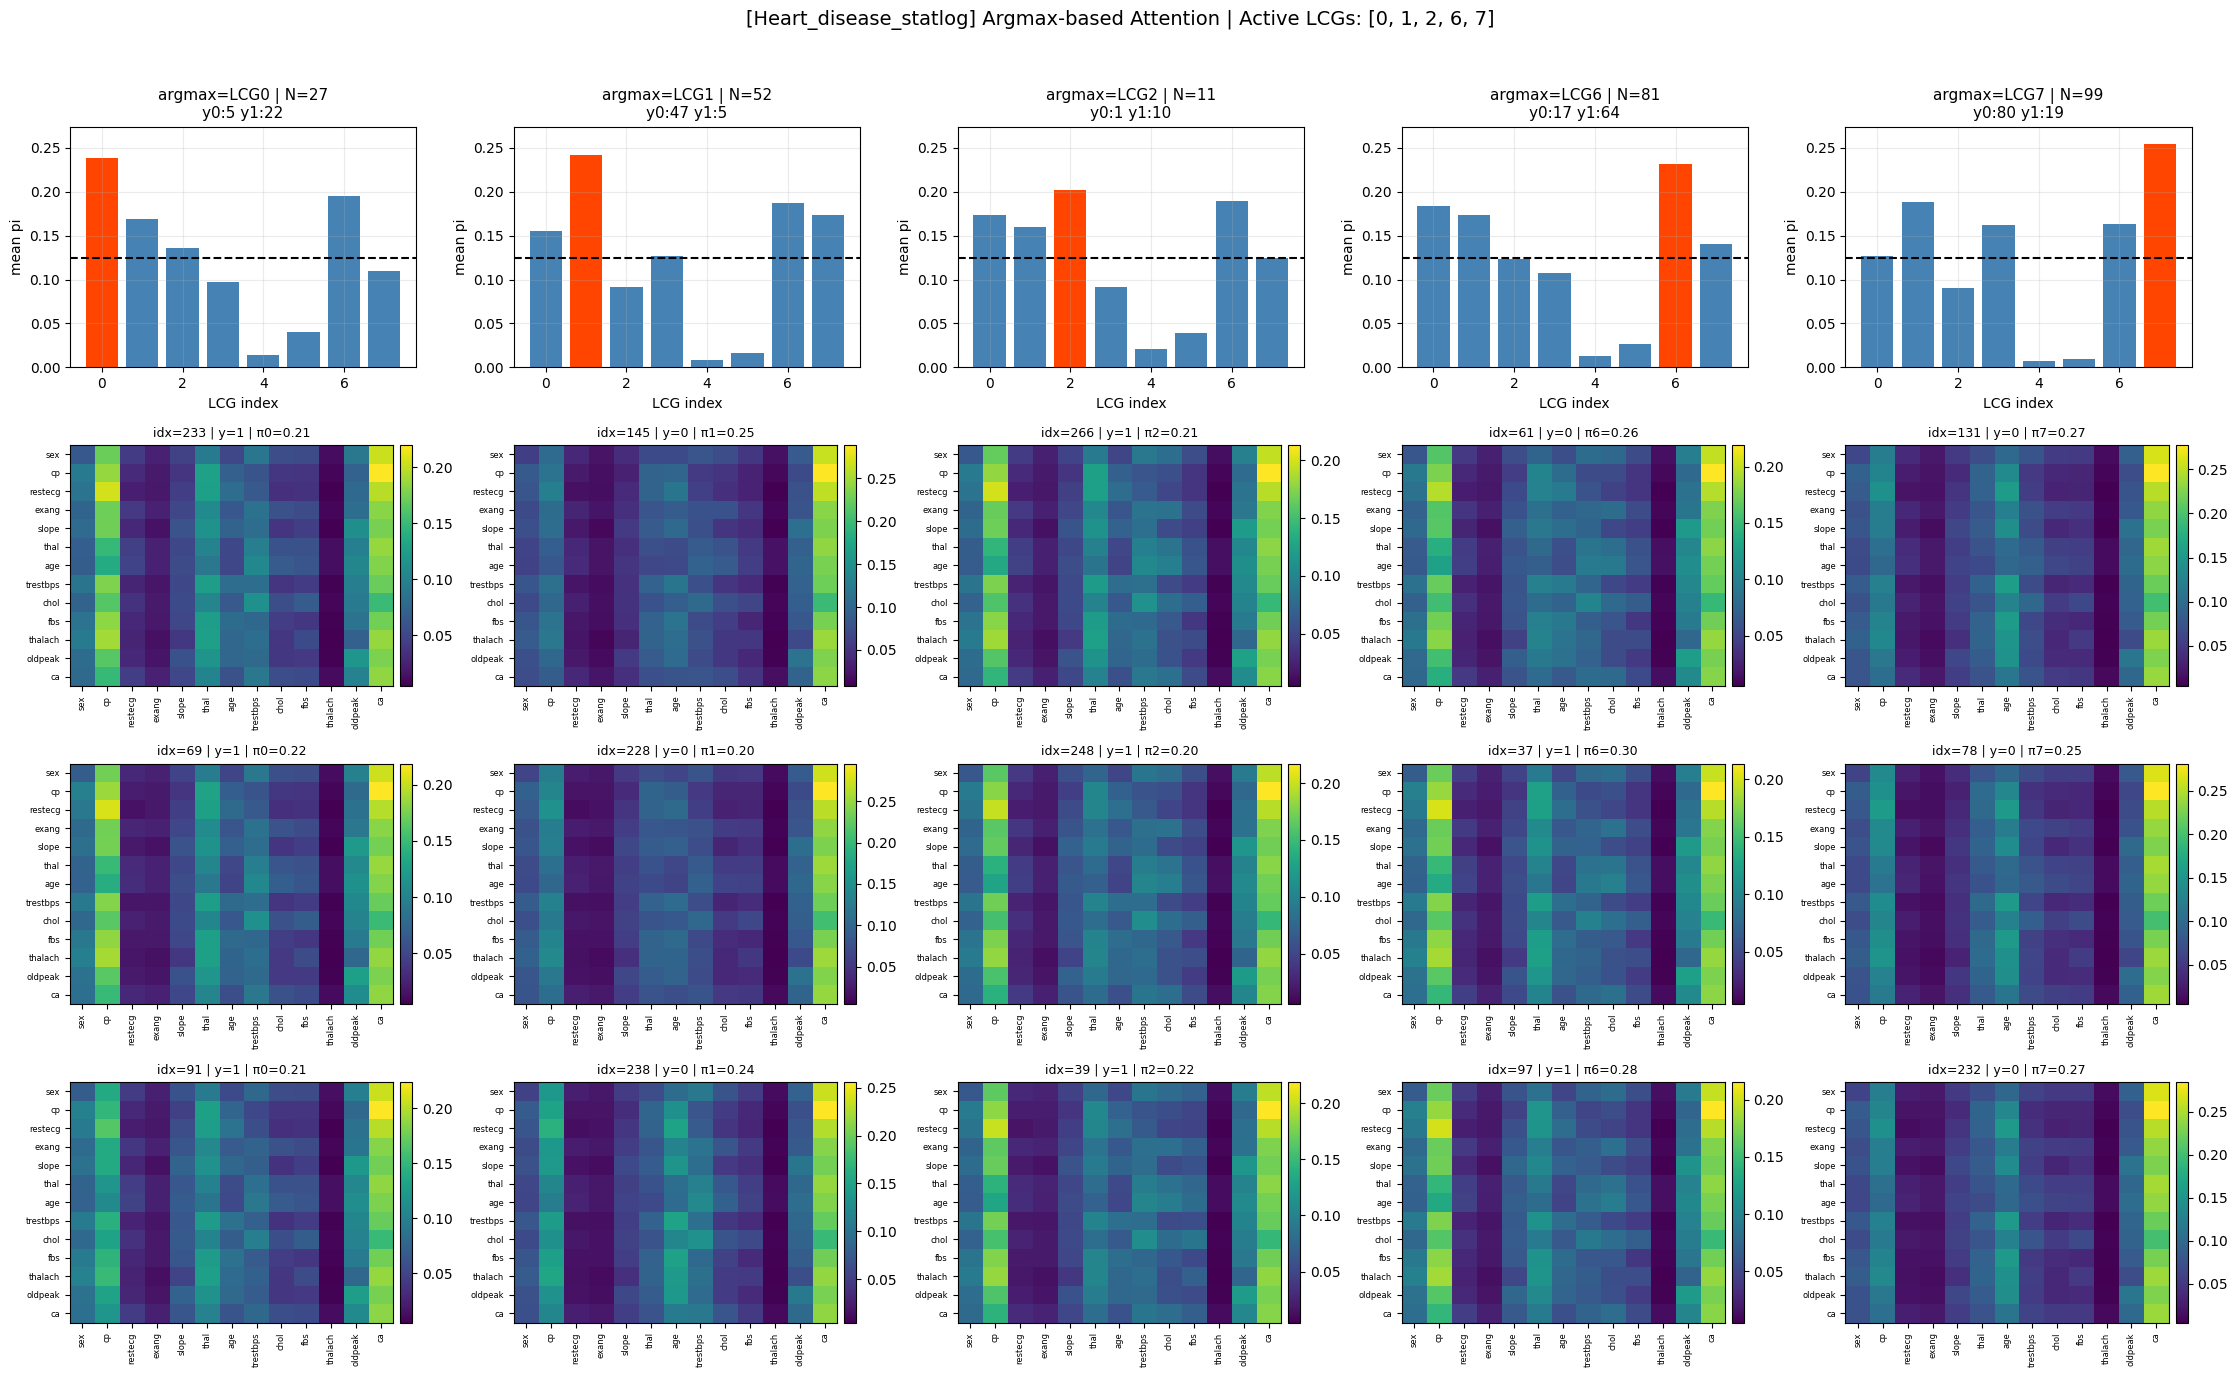


=== Attention Frobenius Analysis [Heart_disease_statlog] ===

[Inter-group] Mean Attention Frobenius Distance:
  LCG0 vs LCG1: 0.2249
  LCG0 vs LCG2: 0.1027
  LCG0 vs LCG6: 0.0696
  LCG0 vs LCG7: 0.2521
  LCG1 vs LCG2: 0.2276
  LCG1 vs LCG6: 0.2119
  LCG1 vs LCG7: 0.0826
  LCG2 vs LCG6: 0.0816
  LCG2 vs LCG7: 0.2823
  LCG6 vs LCG7: 0.2498

[Intra-group] Mean Frobenius to group centroid:
  LCG0: mean_intra=0.1947, std=0.0770
  LCG1: mean_intra=0.2234, std=0.0759
  LCG2: mean_intra=0.1313, std=0.0503
  LCG6: mean_intra=0.1617, std=0.0592
  LCG7: mean_intra=0.1529, std=0.0689

[Ratio] inter / mean(intra):  (>1 = groups are distinguishable)
  LCG0 vs LCG1: ratio=1.3015  ✓ distinct
  LCG0 vs LCG2: ratio=0.5942  ✗ overlapping
  LCG0 vs LCG6: ratio=0.4029  ✗ overlapping
  LCG0 vs LCG7: ratio=1.4586  ✓ distinct
  LCG1 vs LCG2: ratio=1.3173  ✓ distinct
  LCG1 vs LCG6: ratio=1.2263  ✓ distinct
  LCG1 vs LCG7: ratio=0.4782  ✗ overlapping
  LCG2 vs LCG6: ratio=0.4719  ✗ overlapping
  LCG2 vs LCG7

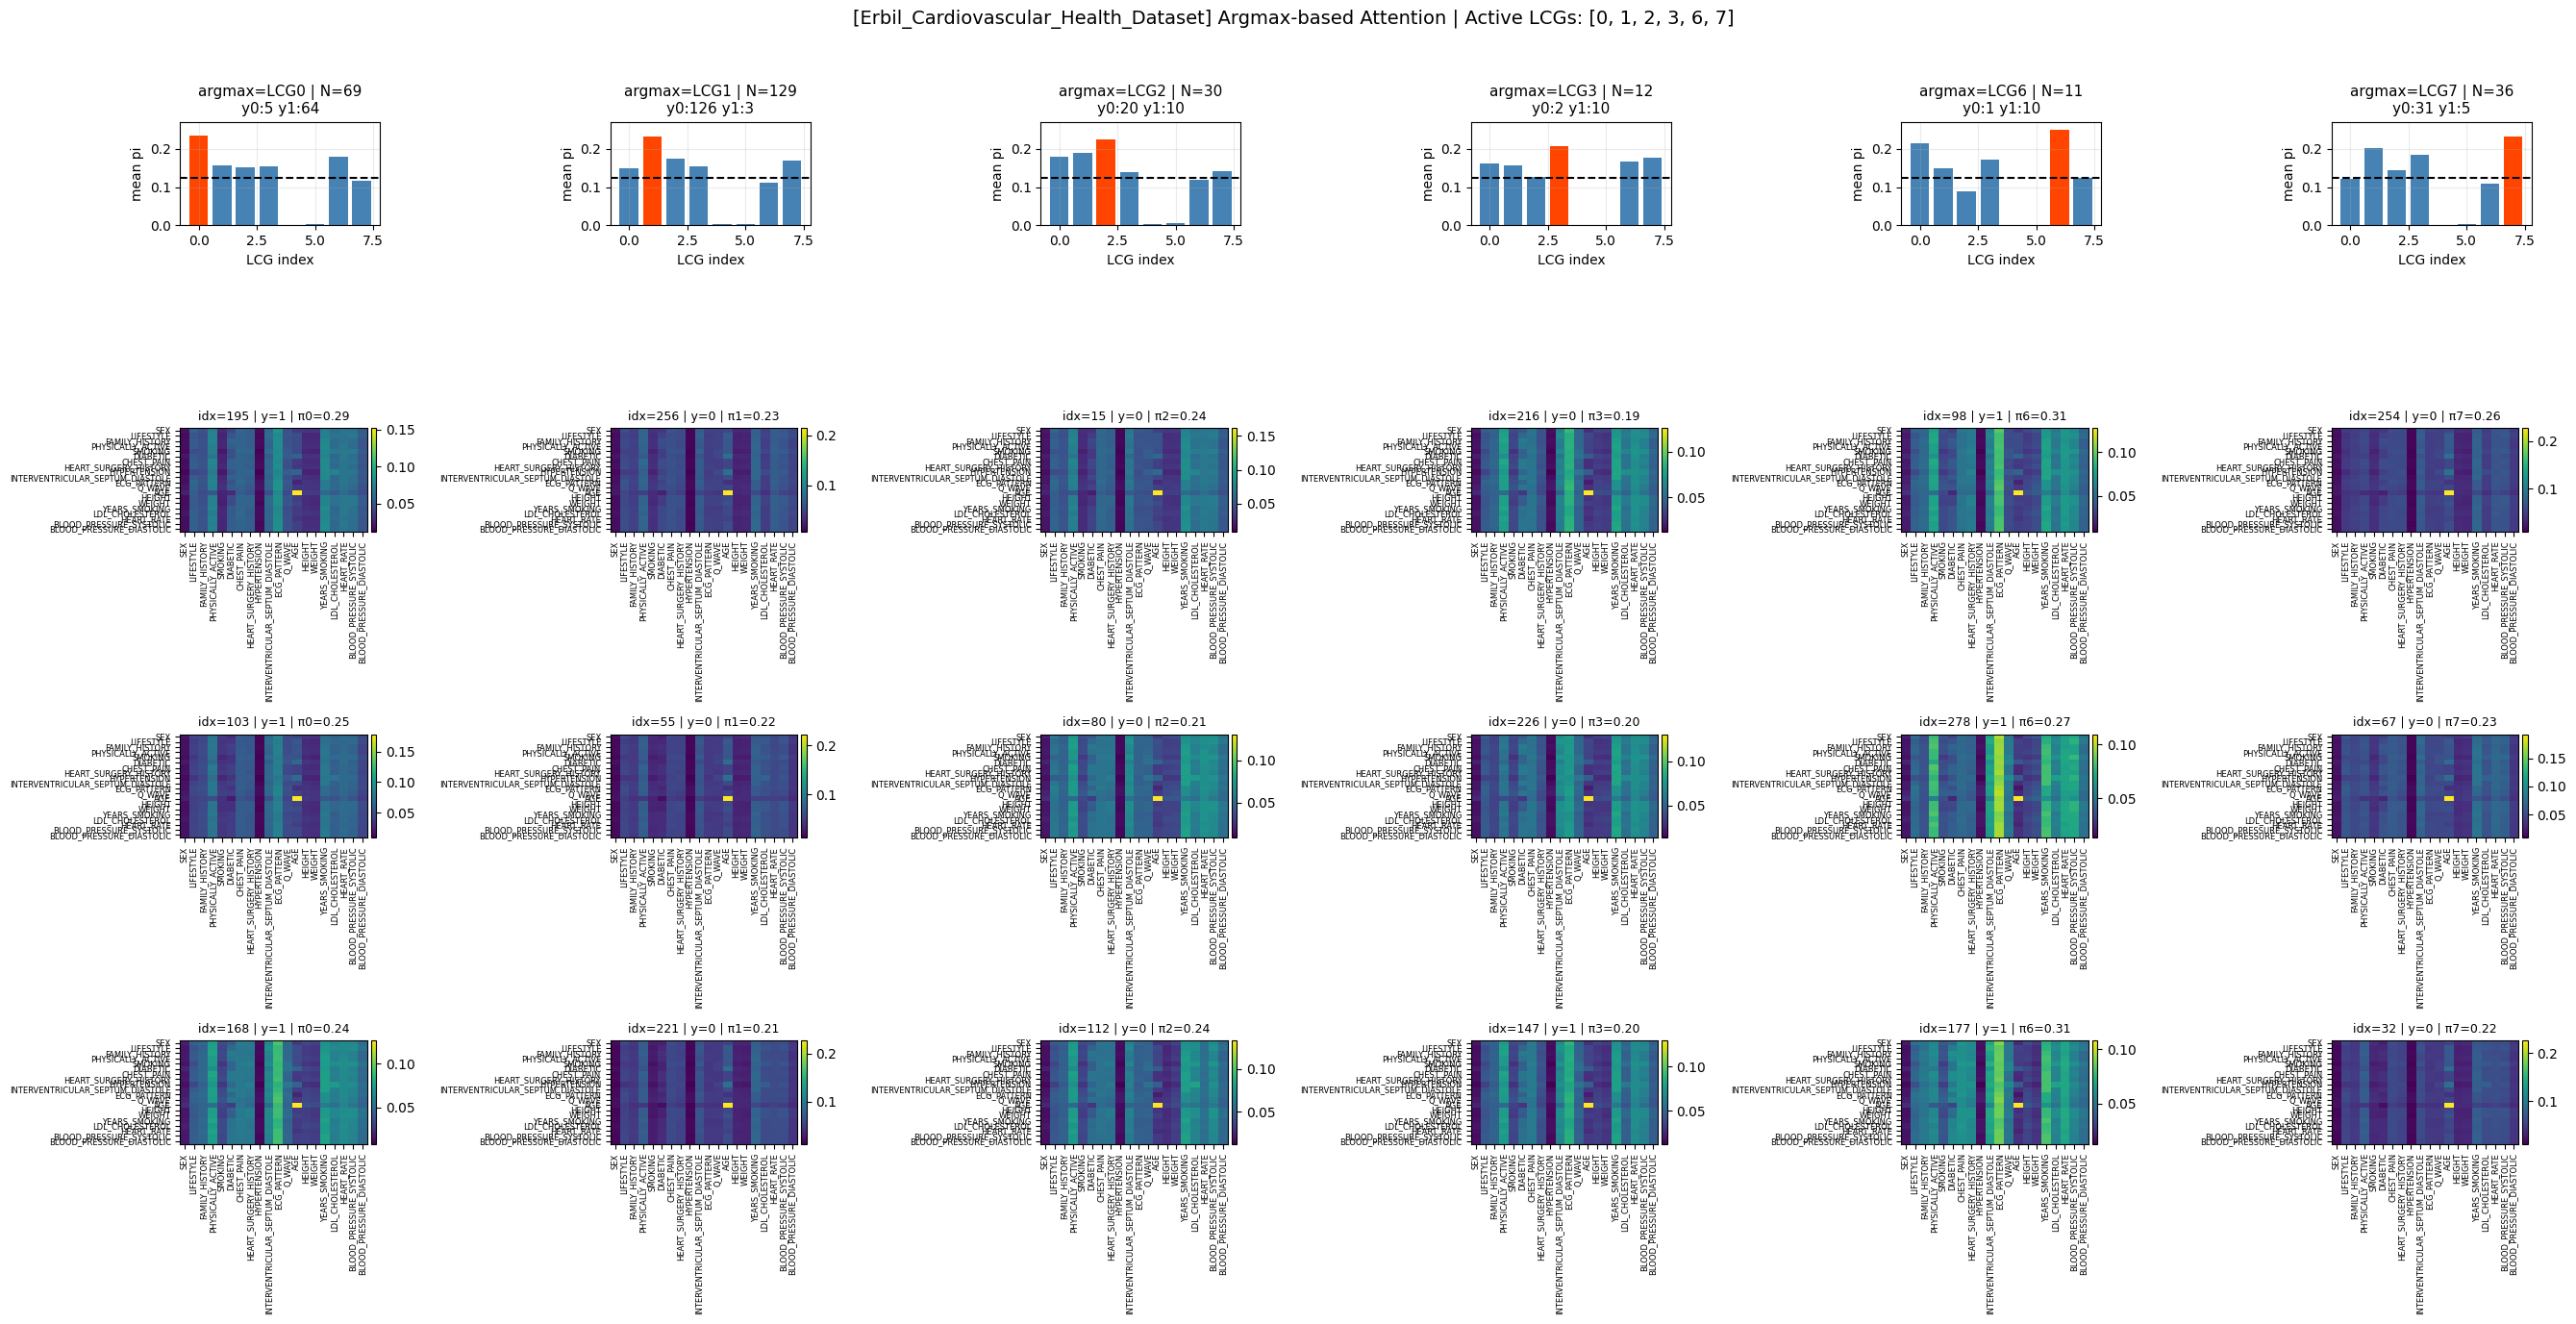


=== Attention Frobenius Analysis [Erbil_Cardiovascular_Health_Dataset] ===

[Inter-group] Mean Attention Frobenius Distance:
  LCG0 vs LCG1: 0.1775
  LCG0 vs LCG2: 0.1221
  LCG0 vs LCG3: 0.0459
  LCG0 vs LCG6: 0.0227
  LCG0 vs LCG7: 0.1728
  LCG1 vs LCG2: 0.0732
  LCG1 vs LCG3: 0.1719
  LCG1 vs LCG6: 0.1846
  LCG1 vs LCG7: 0.0412
  LCG2 vs LCG3: 0.1247
  LCG2 vs LCG6: 0.1321
  LCG2 vs LCG7: 0.0797
  LCG3 vs LCG6: 0.0520
  LCG3 vs LCG7: 0.1620
  LCG6 vs LCG7: 0.1805

[Intra-group] Mean Frobenius to group centroid:
  LCG0: mean_intra=0.1254, std=0.0394
  LCG1: mean_intra=0.1616, std=0.0307
  LCG2: mean_intra=0.1582, std=0.0240
  LCG3: mean_intra=0.1351, std=0.0394
  LCG6: mean_intra=0.1494, std=0.0240
  LCG7: mean_intra=0.1555, std=0.0363

[Ratio] inter / mean(intra):  (>1 = groups are distinguishable)
  LCG0 vs LCG1: ratio=1.2034  ✓ distinct
  LCG0 vs LCG2: ratio=0.8280  ✗ overlapping
  LCG0 vs LCG3: ratio=0.3110  ✗ overlapping
  LCG0 vs LCG6: ratio=0.1537  ✗ overlapping
  LCG0 vs LCG7

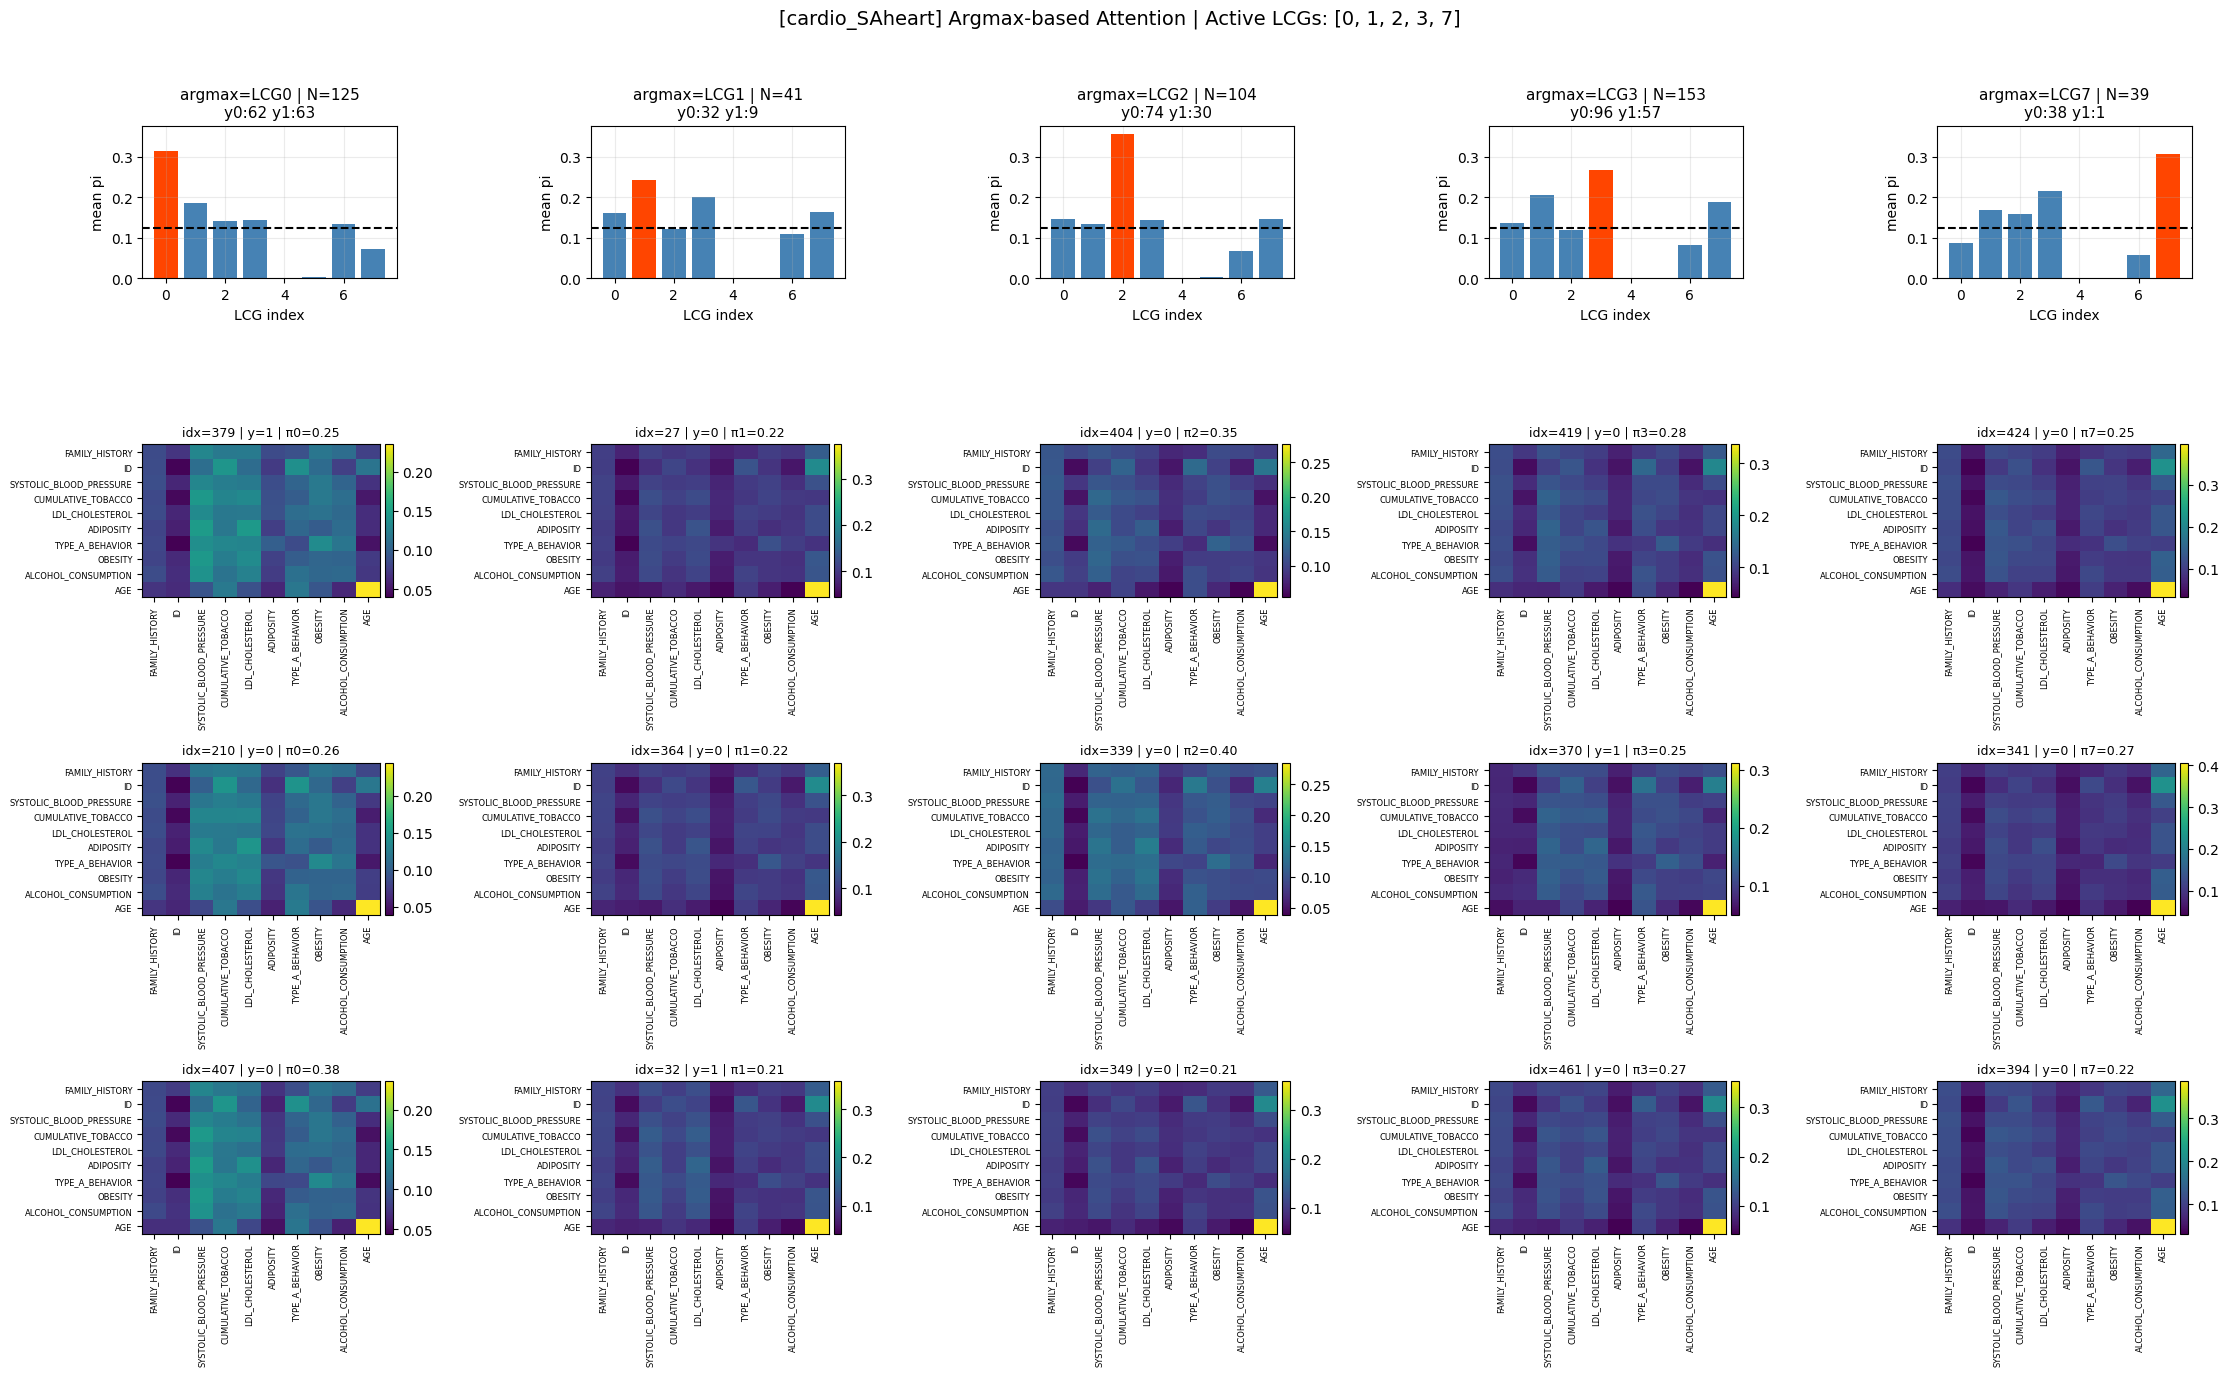


=== Attention Frobenius Analysis [cardio_SAheart] ===

[Inter-group] Mean Attention Frobenius Distance:
  LCG0 vs LCG1: 0.1796
  LCG0 vs LCG2: 0.1216
  LCG0 vs LCG3: 0.1330
  LCG0 vs LCG7: 0.2803
  LCG1 vs LCG2: 0.0798
  LCG1 vs LCG3: 0.0504
  LCG1 vs LCG7: 0.1069
  LCG2 vs LCG3: 0.0450
  LCG2 vs LCG7: 0.1751
  LCG3 vs LCG7: 0.1535

[Intra-group] Mean Frobenius to group centroid:
  LCG0: mean_intra=0.1527, std=0.0697
  LCG1: mean_intra=0.1651, std=0.0811
  LCG2: mean_intra=0.1841, std=0.0487
  LCG3: mean_intra=0.1801, std=0.0397
  LCG7: mean_intra=0.1598, std=0.0836

[Ratio] inter / mean(intra):  (>1 = groups are distinguishable)
  LCG0 vs LCG1: ratio=1.0667  ✓ distinct
  LCG0 vs LCG2: ratio=0.7224  ✗ overlapping
  LCG0 vs LCG3: ratio=0.7901  ✗ overlapping
  LCG0 vs LCG7: ratio=1.6651  ✓ distinct
  LCG1 vs LCG2: ratio=0.4742  ✗ overlapping
  LCG1 vs LCG3: ratio=0.2995  ✗ overlapping
  LCG1 vs LCG7: ratio=0.6350  ✗ overlapping
  LCG2 vs LCG3: ratio=0.2675  ✗ overlapping
  LCG2 vs LCG7:

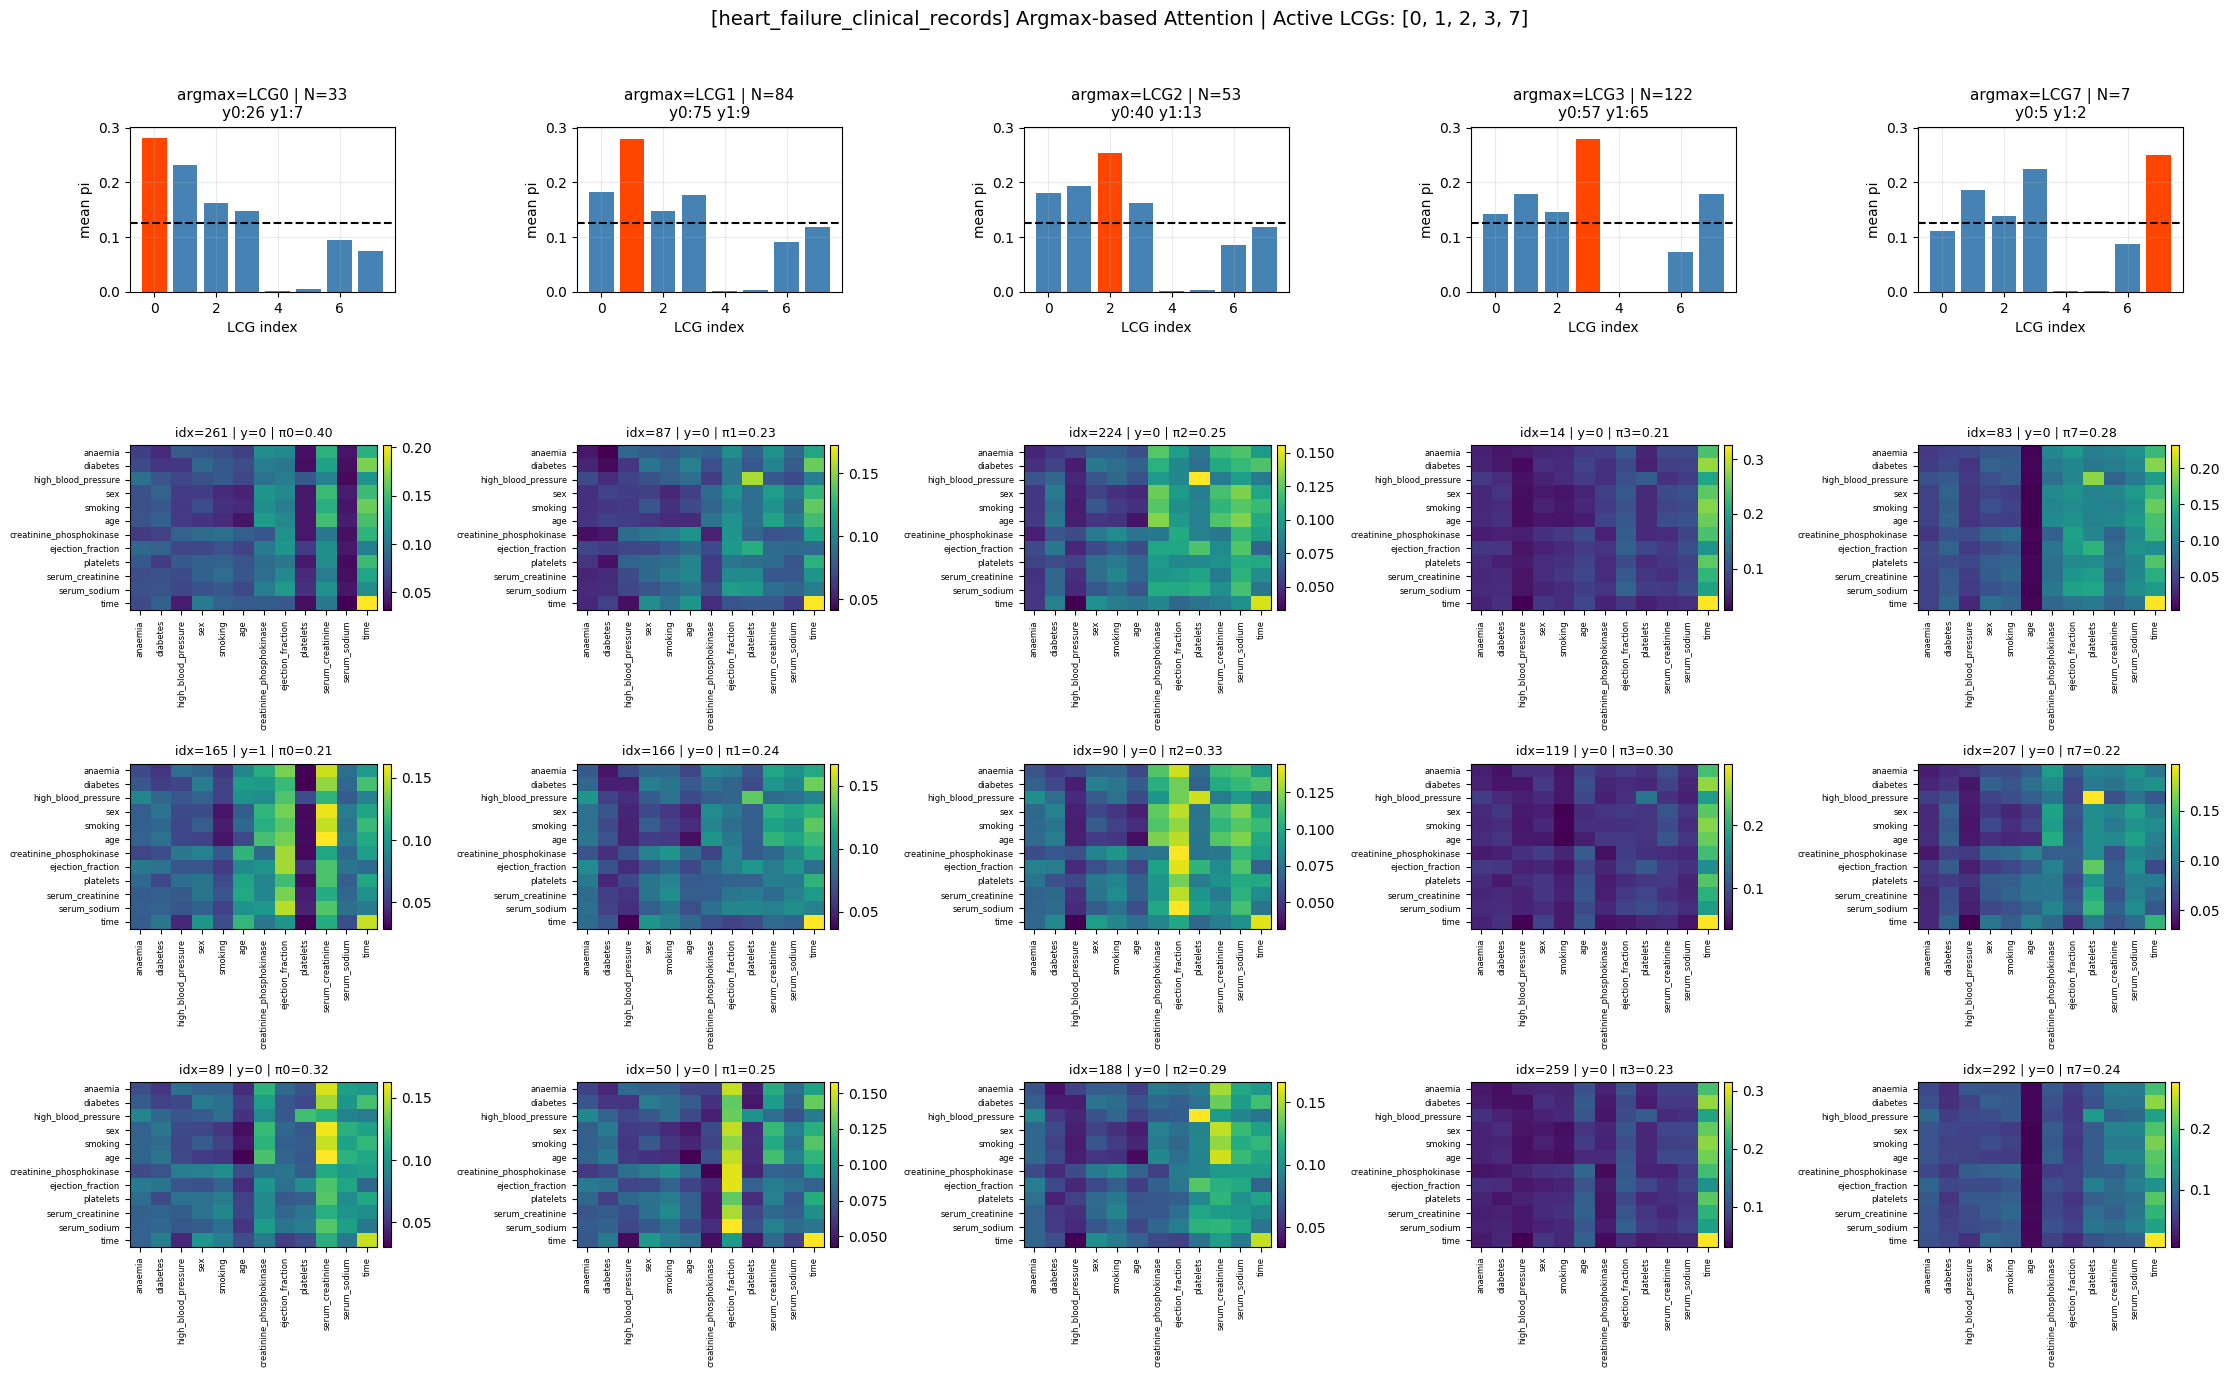


=== Attention Frobenius Analysis [heart_failure_clinical_records] ===

[Inter-group] Mean Attention Frobenius Distance:
  LCG0 vs LCG1: 0.1318
  LCG0 vs LCG2: 0.1334
  LCG0 vs LCG3: 0.3967
  LCG0 vs LCG7: 0.1605
  LCG1 vs LCG2: 0.1149
  LCG1 vs LCG3: 0.4626
  LCG1 vs LCG7: 0.2140
  LCG2 vs LCG3: 0.4066
  LCG2 vs LCG7: 0.1402
  LCG3 vs LCG7: 0.3089

[Intra-group] Mean Frobenius to group centroid:
  LCG0: mean_intra=0.3605, std=0.1072
  LCG1: mean_intra=0.3519, std=0.1172
  LCG2: mean_intra=0.3209, std=0.1584
  LCG3: mean_intra=0.3916, std=0.1735
  LCG7: mean_intra=0.3414, std=0.0540

[Ratio] inter / mean(intra):  (>1 = groups are distinguishable)
  LCG0 vs LCG1: ratio=0.3732  ✗ overlapping
  LCG0 vs LCG2: ratio=0.3778  ✗ overlapping
  LCG0 vs LCG3: ratio=1.1231  ✓ distinct
  LCG0 vs LCG7: ratio=0.4543  ✗ overlapping
  LCG1 vs LCG2: ratio=0.3253  ✗ overlapping
  LCG1 vs LCG3: ratio=1.3095  ✓ distinct
  LCG1 vs LCG7: ratio=0.6059  ✗ overlapping
  LCG2 vs LCG3: ratio=1.1511  ✓ distinct
  

In [25]:
for src in sources:
    result = plot_argmax_attention(model, loaders, device, src, extract_feature_names)


## Coordinate Clustering

In [26]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

def compute_tsne_coords(pis, seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(
        n_components=2, perplexity=perp,
        learning_rate=200, init="pca", random_state=seed
    ).fit_transform(pis)
    return xy

# =========================================================
# 1) Source 하나에서 pi, y, affinity(FGW용), raw_attn(시각화용), names 수집
# =========================================================
@torch.no_grad()
def collect_pi_and_affinity_for_one_source(model, loader, device, extract_feature_names_fn):
    model.eval()
    model.args.use_lcg = True

    all_pis = []
    all_ys = []
    all_affs = []       # FGW용: q90 정규화된 structure
    all_affs_raw = []   # 시각화용: raw attention [0,1]
    all_names = []

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        # --- pi 수집 ---
        _ = model.predict(batch_t, return_all=True)
        pi = model.graph_quantizer.last_pi  # [B, M]
        if pi is None:
            raise RuntimeError("last_pi is None. use_lcg=True?")

        # --- attention 수집 (collect_all_samples_from_source와 동일) ---
        name_embeddings, value_embeddings = [], []
        if all(k in batch_t for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            name_embeddings.append(batch_t['cat_name_embeddings'])
            value_embeddings.append(batch_t['cat_value_embeddings'])
        if all(k in batch_t for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            name_embeddings.append(batch_t['num_name_embeddings'])
            value_embeddings.append(batch_t['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        B = value.size(0)

        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
        last_att = None
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        last_att = last_att[:, 0, :, :]  # [B, T, T]

        # --- feature names ---
        var_names = extract_feature_names_fn(batch_t)

        for b in range(B):
            raw_attn = last_att[b, 1:, 1:].detach().cpu()  # [N, N]

            # FGW용: 모델과 동일한 q90 정규화
            log_attn = -torch.log(raw_attn.clamp_min(1e-8))
            q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            P_basis = (log_attn / q90).clamp_max(1.0)

            all_pis.append(pi[b].detach().cpu().numpy())
            all_ys.append(int(batch_t['y'][b].item()))
            all_affs.append(P_basis.numpy())          # FGW용
            all_affs_raw.append(raw_attn.numpy())      # 시각화용
            all_names.append(var_names)

    pis = np.stack(all_pis, axis=0)     # [N_total, M]
    ys = np.array(all_ys)               # [N_total]
    return pis, ys, all_affs, all_affs_raw, all_names

from sklearn.metrics import silhouette_score

# =========================================================
# 3) KMeans + 실루엣 기반 최적 K 탐색 + 대표 샘플 뽑기
# =========================================================
def find_best_K_by_silhouette(X, K_range=range(2, 11), seed=42):
    """pi space에서 실루엣 기반 최적 K 탐색"""
    if len(X) < 4:
        return 2, []
    
    sil_scores = []
    valid_ks = []
    for k in K_range:
        if k >= len(X):
            break
        km = KMeans(n_clusters=k, random_state=seed, n_init=20).fit(X)
        sil = silhouette_score(X, km.labels_, metric='cosine')
        sil_scores.append(sil)
        valid_ks.append(k)
    
    best_k = valid_ks[np.argmax(sil_scores)]
    return best_k, list(zip(valid_ks, sil_scores))


def fit_kmeans_and_pick_reps(pis, ys, label, K="auto", K_range=range(2, 11), seed=42):
    """
    K="auto": 실루엣 기반으로 최적 K 자동 탐색
    K=int:    고정 K 사용
    """
    idx = np.where(ys == label)[0]
    if len(idx) == 0:
        return {"idx": idx, "X": None, "cid": None, "km": None,
                "reps_global": [], "k_eff": 0,
                "sil_scores": [], "best_sil": None}

    X = pis[idx]

    # --- 실루엣 기반 K 선택 ---
    if K == "auto":
        best_k, sil_scores = find_best_K_by_silhouette(X, K_range=K_range, seed=seed)
        k_eff = min(best_k, len(idx))
        print(f"  [label={label}] Silhouette sweep: best K={best_k}")
        for k, s in sil_scores:
            marker = " <<<" if k == best_k else ""
            print(f"    K={k:2d} | sil={s:.4f}{marker}")
    else:
        k_eff = min(K, len(idx))
        # 실루엣은 참고용으로 계산
        _, sil_scores = find_best_K_by_silhouette(X, K_range=K_range, seed=seed)
        best_k = k_eff

    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_

    # 현재 k_eff에서의 실루엣
    best_sil = silhouette_score(X, cid, metric='cosine') if k_eff >= 2 else None

    # 대표 샘플
    reps_global = []
    for c in range(k_eff):
        mask = (cid == c)
        Xi = X[mask]
        d = np.linalg.norm(Xi - C[c][None, :], axis=1)
        within = int(np.argmin(d))
        local_candidates = np.where(mask)[0]
        local = int(local_candidates[within])
        reps_global.append(int(idx[local]))

    return {"idx": idx, "X": X, "cid": cid, "km": km,
            "reps_global": reps_global, "k_eff": k_eff,
            "sil_scores": sil_scores, "best_sil": best_sil}


# =========================================================
# 4) 3xK 시각화 — 실루엣 sweep 플롯 추가 (Row 0)
# =========================================================
def plot_3xK_per_label(
    pis, ys, affs_raw, names,
    label, K="auto", K_range=range(2, 11), seed=42,
    title_prefix="[source]",
    bg_alpha=0.12, fg_alpha=0.90,
    bg_size=10, fg_size=14
):
    M = pis.shape[1]
    res = fit_kmeans_and_pick_reps(pis, ys, label=label, K=K, K_range=K_range, seed=seed)
    k_eff = res["k_eff"]
    if k_eff == 0:
        print(f"[warn] label={label} has no samples.")
        return

    idx_lab = res["idx"]
    X_lab = res["X"]
    cid = res["cid"]
    C = res["km"].cluster_centers_
    reps_g = res["reps_global"]
    sil_scores = res["sil_scores"]
    best_sil = res["best_sil"]

    # t-SNE
    xy_lab = compute_tsne_coords(X_lab, seed=seed)
    x_min, x_max = xy_lab[:, 0].min(), xy_lab[:, 0].max()
    y_min, y_max = xy_lab[:, 1].min(), xy_lab[:, 1].max()
    mx = 0.03 * (x_max - x_min + 1e-9)
    my = 0.03 * (y_max - y_min + 1e-9)
    x_min, x_max = x_min - mx, x_max + mx
    y_min, y_max = y_min - my, y_max + my

    pi_ymin = max(0, float(C[:k_eff].min()) - 0.02)
    pi_ymax = float(C[:k_eff].max()) + 0.02

    mats = [affs_raw[g] for g in reps_g]
    vmin = min(m.min() for m in mats)
    vmax = max(m.max() for m in mats)

    # --- Layout: 4 rows ---
    # Row 0: silhouette sweep (한 칸으로 합침)
    # Row 1: t-SNE cluster highlight
    # Row 2: centroid pi
    # Row 3: raw attention
    fig = plt.figure(figsize=(4.2 * k_eff, 16))
    gs = fig.add_gridspec(4, k_eff, height_ratios=[0.6, 1, 0.8, 1])

    # --- Row 0: Silhouette sweep (전체 span) ---
    ax_sil = fig.add_subplot(gs[0, :])
    if sil_scores:
        ks_plot = [s[0] for s in sil_scores]
        sils_plot = [s[1] for s in sil_scores]
        ax_sil.plot(ks_plot, sils_plot, 'o-', color='steelblue')
        ax_sil.axvline(x=k_eff, color='red', linestyle='--',
                       label=f'Selected K={k_eff} (sil={best_sil:.4f})')
        ax_sil.set_xlabel('K (clusters)')
        ax_sil.set_ylabel('Silhouette Score')
        ax_sil.set_title(f'label={label} | Silhouette Sweep in Pi Space | N={len(idx_lab)}')
        ax_sil.legend()
        ax_sil.grid(True, alpha=0.3)

    for c in range(k_eff):
        # --- Row 1: t-SNE ---
        ax = fig.add_subplot(gs[1, c])
        ax.scatter(xy_lab[:, 0], xy_lab[:, 1],
                   s=bg_size, alpha=bg_alpha, color="gray")
        m = (cid == c)
        if m.sum() > 0:
            ax.scatter(xy_lab[m, 0], xy_lab[m, 1],
                       s=fg_size, alpha=fg_alpha, color=f"C{c % 10}")
            cx, cy = xy_lab[m, 0].mean(), xy_lab[m, 1].mean()
            ax.scatter([cx], [cy], s=160, marker="*",
                       edgecolors="black", linewidths=1.2, color=f"C{c % 10}")

        rep_local = int(np.where(idx_lab == reps_g[c])[0][0])
        ax.scatter([xy_lab[rep_local, 0]], [xy_lab[rep_local, 1]],
                   s=200, marker="X", edgecolors="black",
                   linewidths=2.0, color=f"C{c % 10}")
        ax.set_title(f"c={c} | N={m.sum()}", fontsize=10)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.25)

        # --- Row 2: centroid pi ---
        ax = fig.add_subplot(gs[2, c])
        ax.bar(np.arange(M), C[c])
        ax.axhline(1.0 / M, linestyle="--", linewidth=1, color="black")
        ax.set_ylim(pi_ymin, pi_ymax)
        ax.set_title(f"c={c} centroid pi", fontsize=10)
        ax.set_xlabel("LCG index")
        ax.grid(True, alpha=0.25)

        # --- Row 3: raw attention ---
        ax = fig.add_subplot(gs[3, c])
        A = affs_raw[reps_g[c]]
        node_names = names[reps_g[c]]
        N_nodes = A.shape[0]
        labels_list = list(node_names)[:N_nodes]

        im = ax.imshow(A, vmin=vmin, vmax=vmax, cmap='viridis', aspect="auto")
        ax.set_title(f"c={c} rep idx={reps_g[c]}", fontsize=10)
        ax.set_xticks(range(N_nodes))
        ax.set_yticks(range(N_nodes))
        ax.set_xticklabels(labels_list, rotation=90, fontsize=7)
        ax.set_yticklabels(labels_list, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    fig.suptitle(
        f"{title_prefix} | label={label} | K={k_eff} (sil={best_sil:.4f})",
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()


# =========================================================
# 5) Wrapper
# =========================================================
def plot_3xK_by_source(model, loaders, device, source_name,
                       extract_feature_names_fn, K="auto", K_range=range(2, 11), seed=42):
    src_key = None
    loader = None
    for k, v in loaders.items():
        if source_name.lower() in k.lower():
            src_key = k
            loader = v
            break
    if loader is None:
        print(f"[ERROR] '{source_name}' not found. Keys: {list(loaders.keys())}")
        return

    print(f"Using source: {src_key}")
    pis, ys, affs, affs_raw, names = collect_pi_and_affinity_for_one_source(
        model, loader, device, extract_feature_names_fn
    )
    print(f"Collected: {len(ys)} samples, M={pis.shape[1]}")

    for label in sorted(np.unique(ys)):
        plot_3xK_per_label(
            pis, ys, affs_raw, names,
            label=label, K=K, K_range=K_range, seed=seed,
            title_prefix=f"[{src_key}]"
        )

    return {"src_key": src_key, "pis": pis, "ys": ys,
            "affs": affs, "affs_raw": affs_raw, "names": names}

In [27]:
sources

['Medicaldataset',
 'Cardiovascular_Disease_Dataset',
 'Heart_disease_statlog',
 'Erbil_Cardiovascular_Health_Dataset',
 'cardio_SAheart',
 'heart_failure_clinical_records']

Using source: Medicaldataset
Collected: 1319 samples, M=8
  [label=0] Silhouette sweep: best K=2
    K= 2 | sil=0.6732 <<<
    K= 3 | sil=0.5659
    K= 4 | sil=0.5204
    K= 5 | sil=0.4703
    K= 6 | sil=0.4324
    K= 7 | sil=0.4572
    K= 8 | sil=0.4800
    K= 9 | sil=0.4460
    K=10 | sil=0.4618


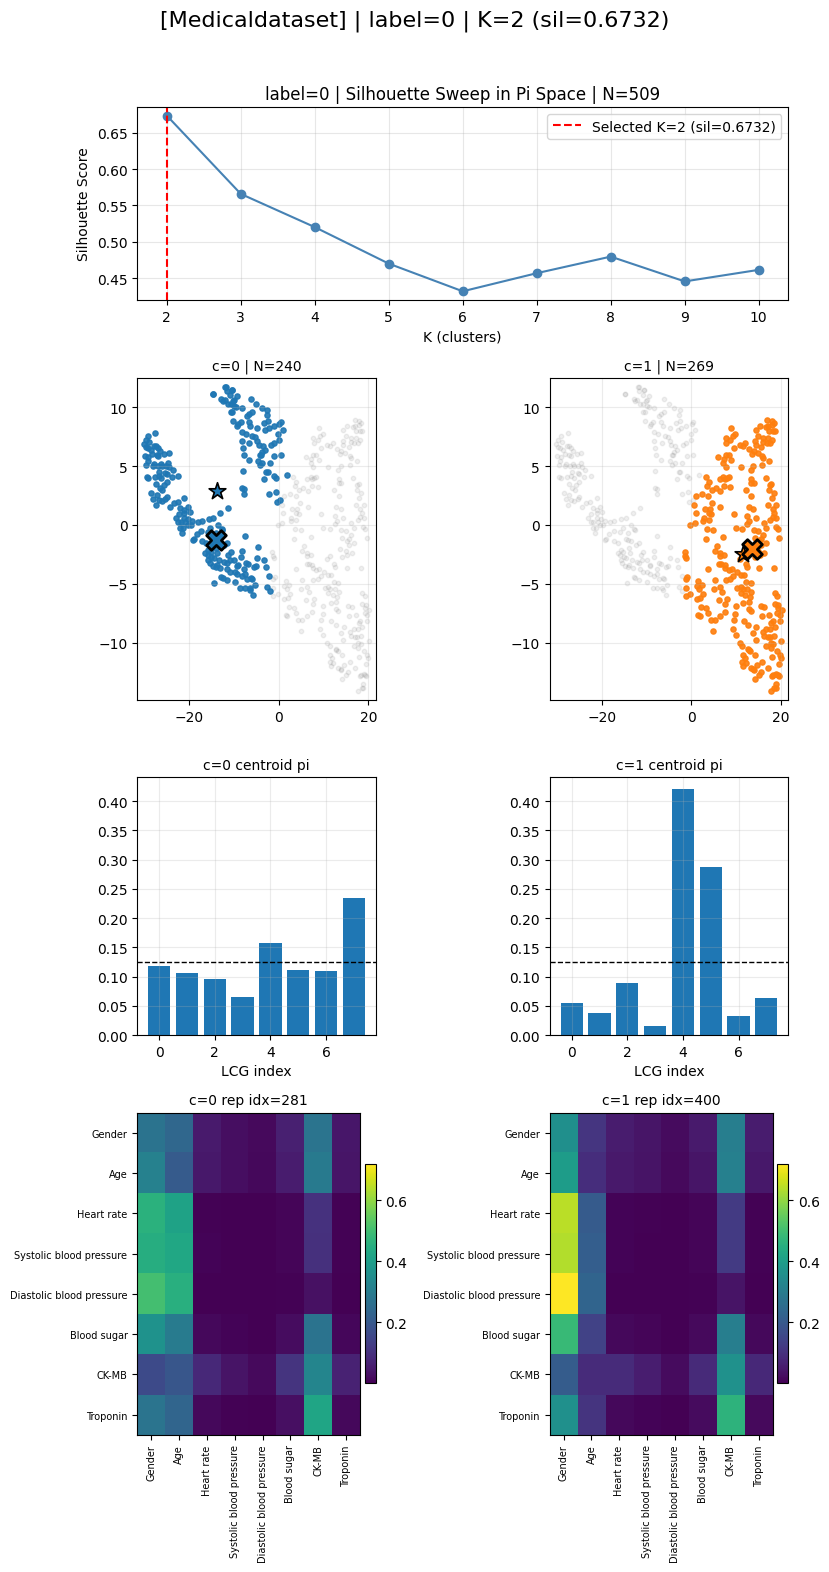

  [label=1] Silhouette sweep: best K=2
    K= 2 | sil=0.7557 <<<
    K= 3 | sil=0.6010
    K= 4 | sil=0.5973
    K= 5 | sil=0.4569
    K= 6 | sil=0.4761
    K= 7 | sil=0.4831
    K= 8 | sil=0.4521
    K= 9 | sil=0.4564
    K=10 | sil=0.4382


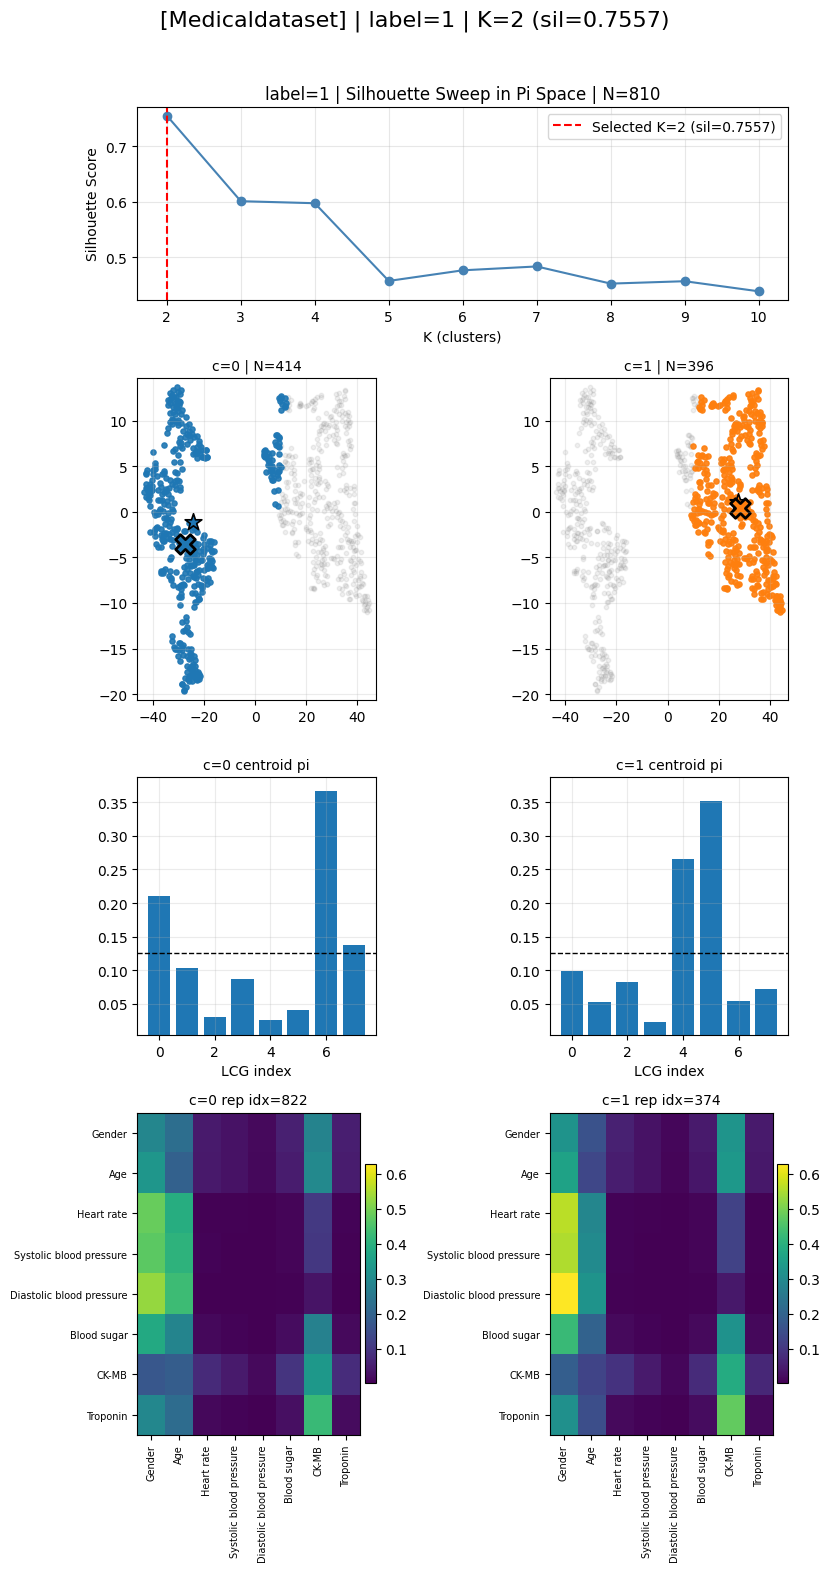

Using source: Cardiovascular_Disease_Dataset
Collected: 1000 samples, M=8
  [label=0] Silhouette sweep: best K=2
    K= 2 | sil=0.4954 <<<
    K= 3 | sil=0.3582
    K= 4 | sil=0.3817
    K= 5 | sil=0.3792
    K= 6 | sil=0.3518
    K= 7 | sil=0.3774
    K= 8 | sil=0.3859
    K= 9 | sil=0.3756
    K=10 | sil=0.3297


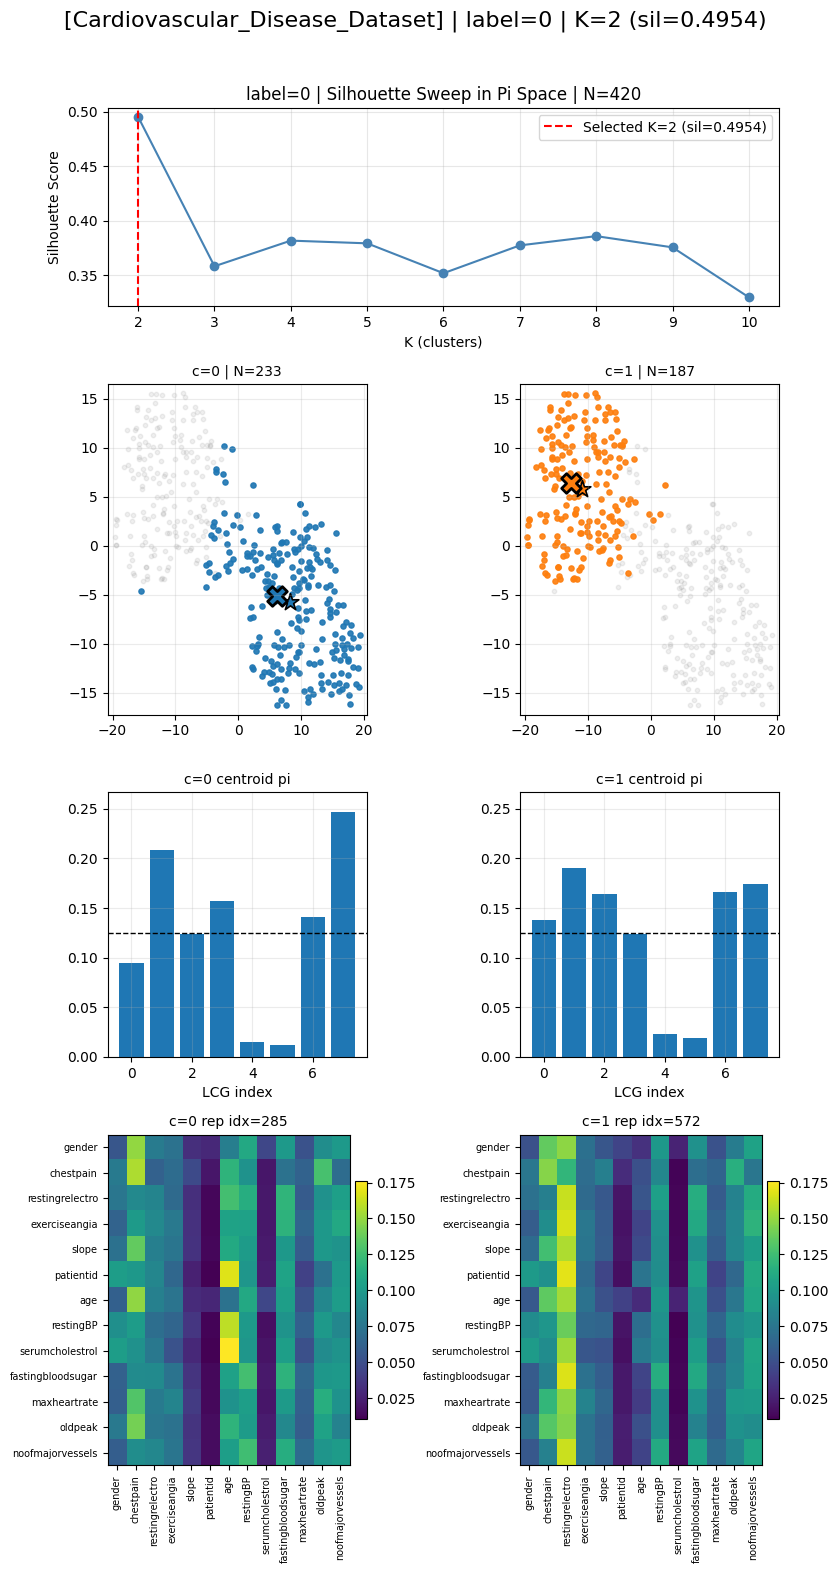

  [label=1] Silhouette sweep: best K=2
    K= 2 | sil=0.5144 <<<
    K= 3 | sil=0.4872
    K= 4 | sil=0.4493
    K= 5 | sil=0.4275
    K= 6 | sil=0.4340
    K= 7 | sil=0.4146
    K= 8 | sil=0.4265
    K= 9 | sil=0.3976
    K=10 | sil=0.3919


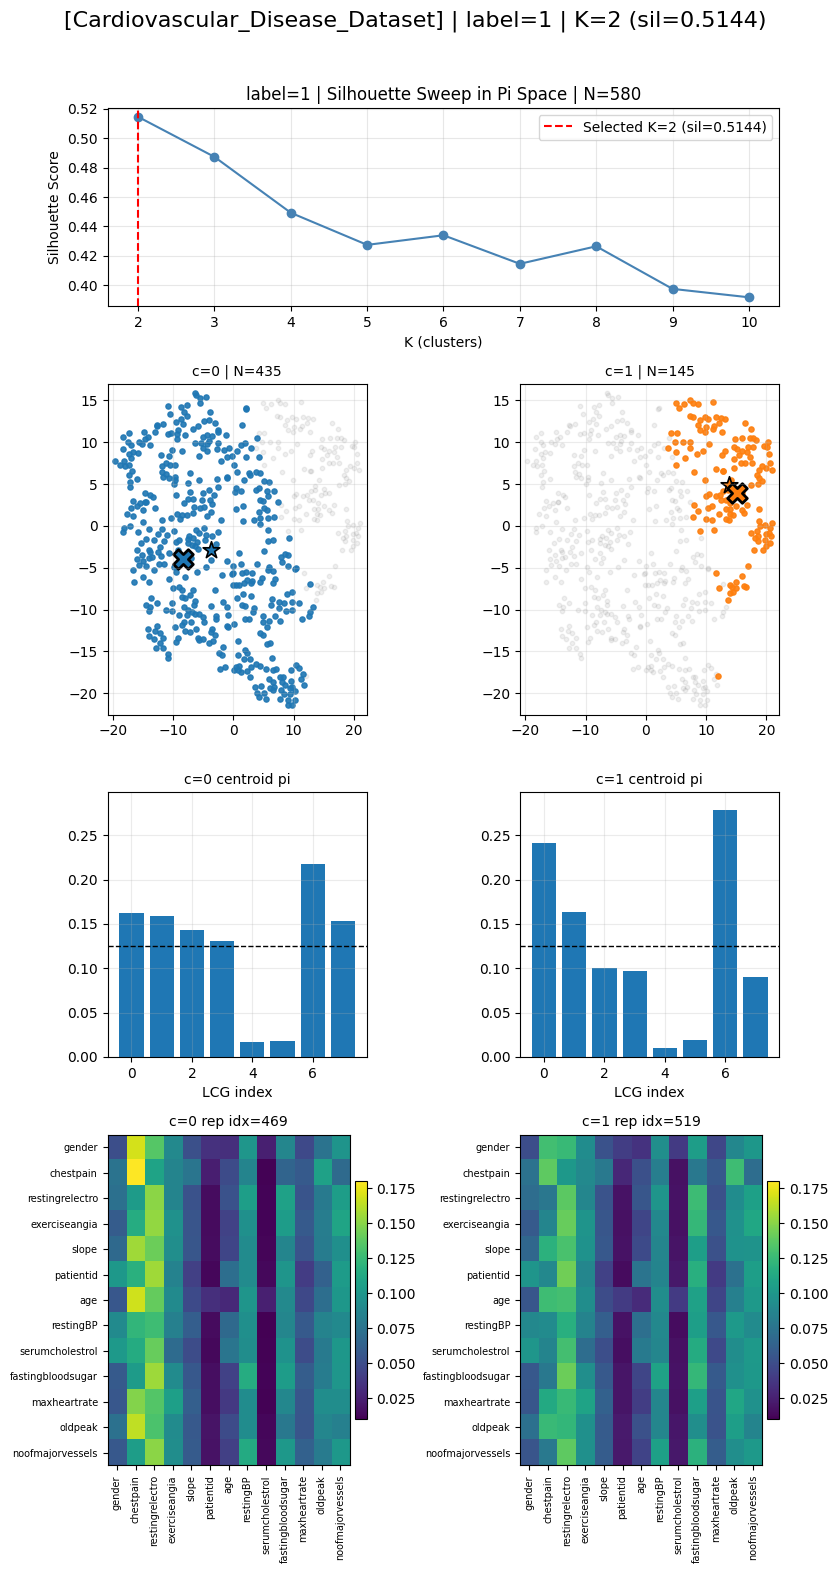

Using source: Heart_disease_statlog
Collected: 270 samples, M=8
  [label=0] Silhouette sweep: best K=3
    K= 2 | sil=0.5227
    K= 3 | sil=0.5538 <<<
    K= 4 | sil=0.5152
    K= 5 | sil=0.5265
    K= 6 | sil=0.4260
    K= 7 | sil=0.4633
    K= 8 | sil=0.3615
    K= 9 | sil=0.4605
    K=10 | sil=0.3753


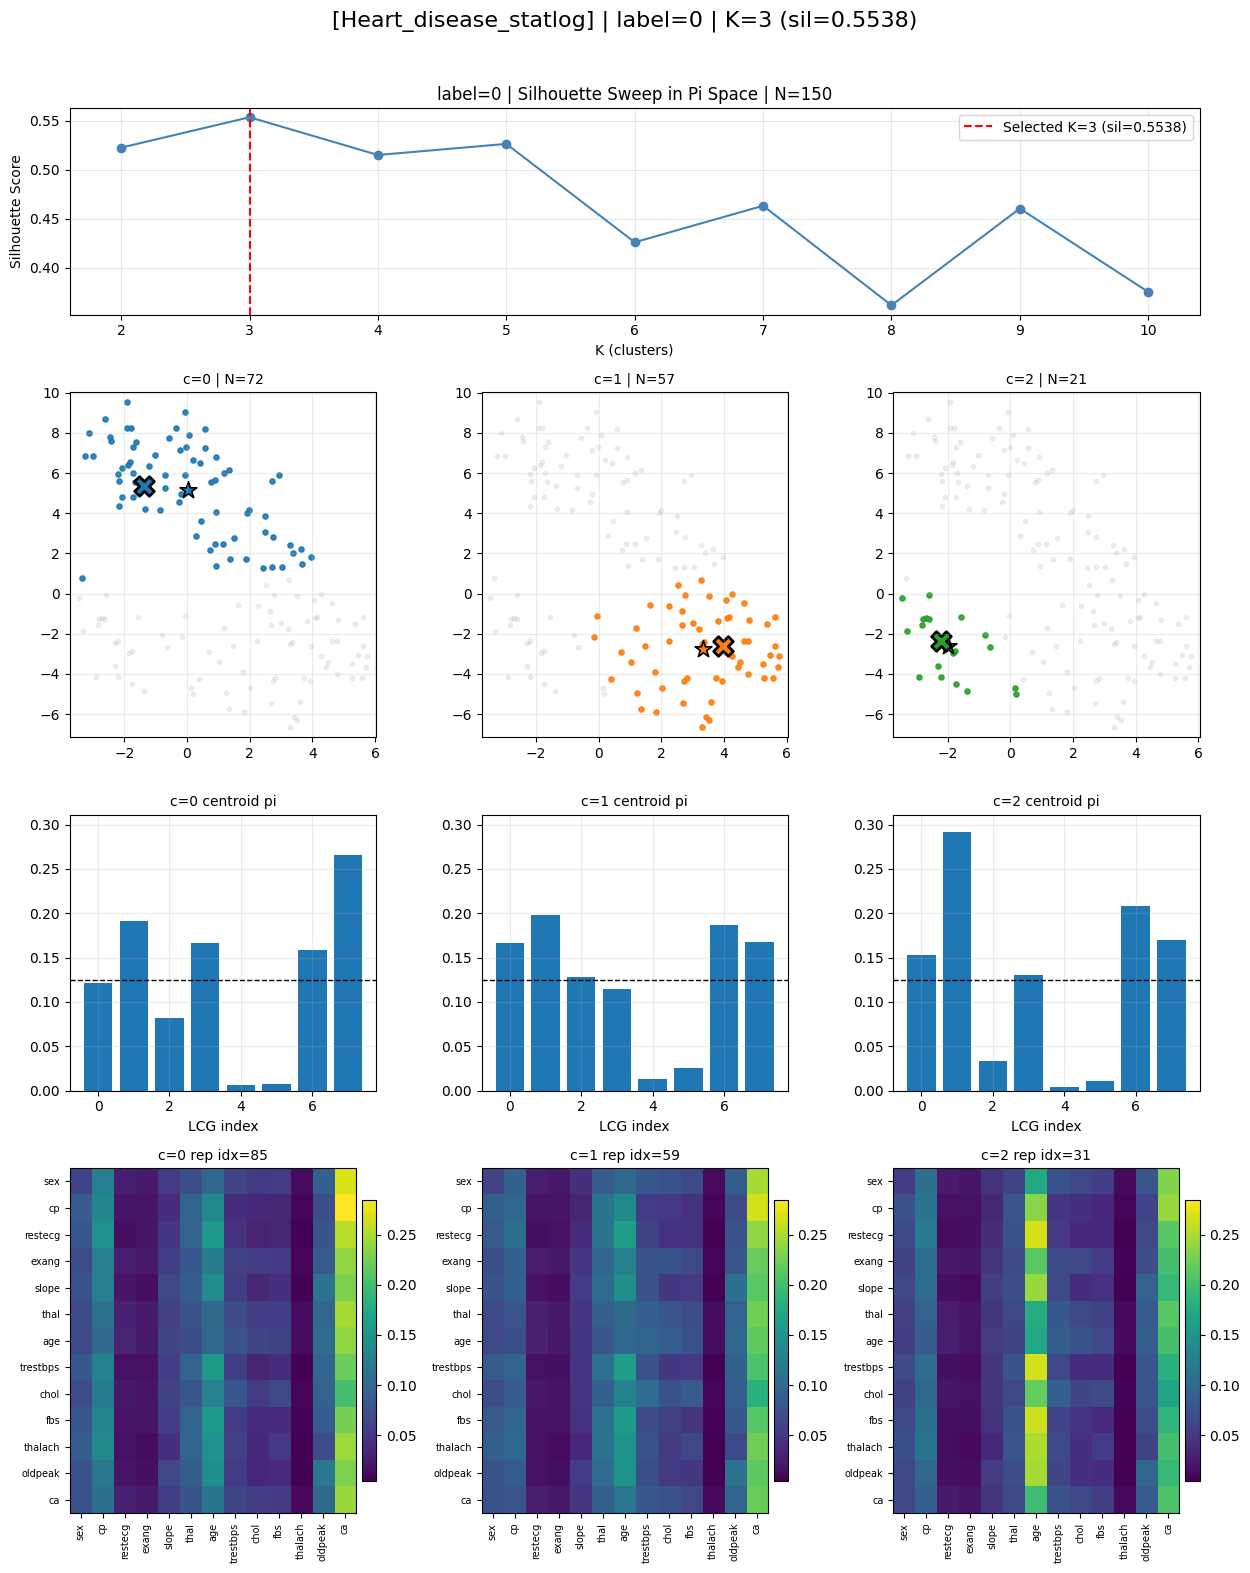

  [label=1] Silhouette sweep: best K=3
    K= 2 | sil=0.5389
    K= 3 | sil=0.5563 <<<
    K= 4 | sil=0.4697
    K= 5 | sil=0.4836
    K= 6 | sil=0.4539
    K= 7 | sil=0.4225
    K= 8 | sil=0.4558
    K= 9 | sil=0.4284
    K=10 | sil=0.4457


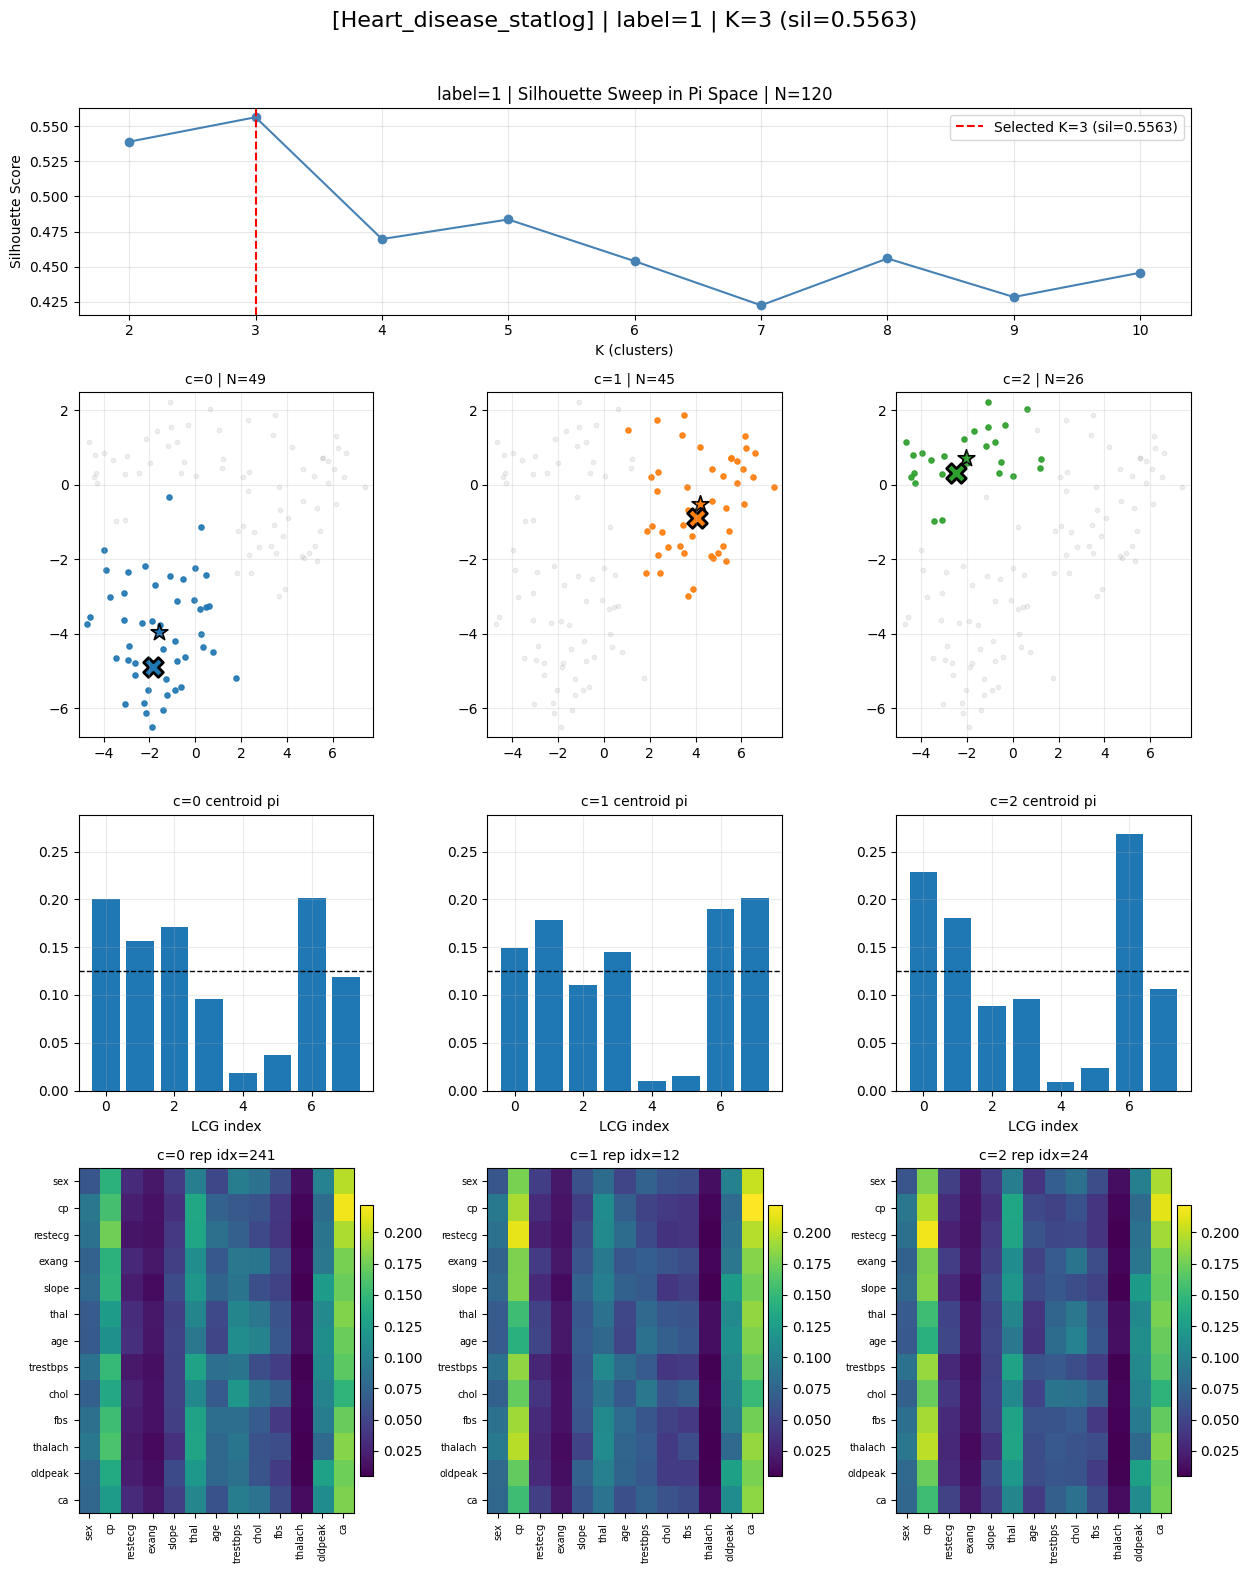

Using source: Erbil_Cardiovascular_Health_Dataset
Collected: 287 samples, M=8
  [label=0] Silhouette sweep: best K=3
    K= 2 | sil=0.4749
    K= 3 | sil=0.5368 <<<
    K= 4 | sil=0.5115
    K= 5 | sil=0.4969
    K= 6 | sil=0.4319
    K= 7 | sil=0.4694
    K= 8 | sil=0.4577
    K= 9 | sil=0.4357
    K=10 | sil=0.4144


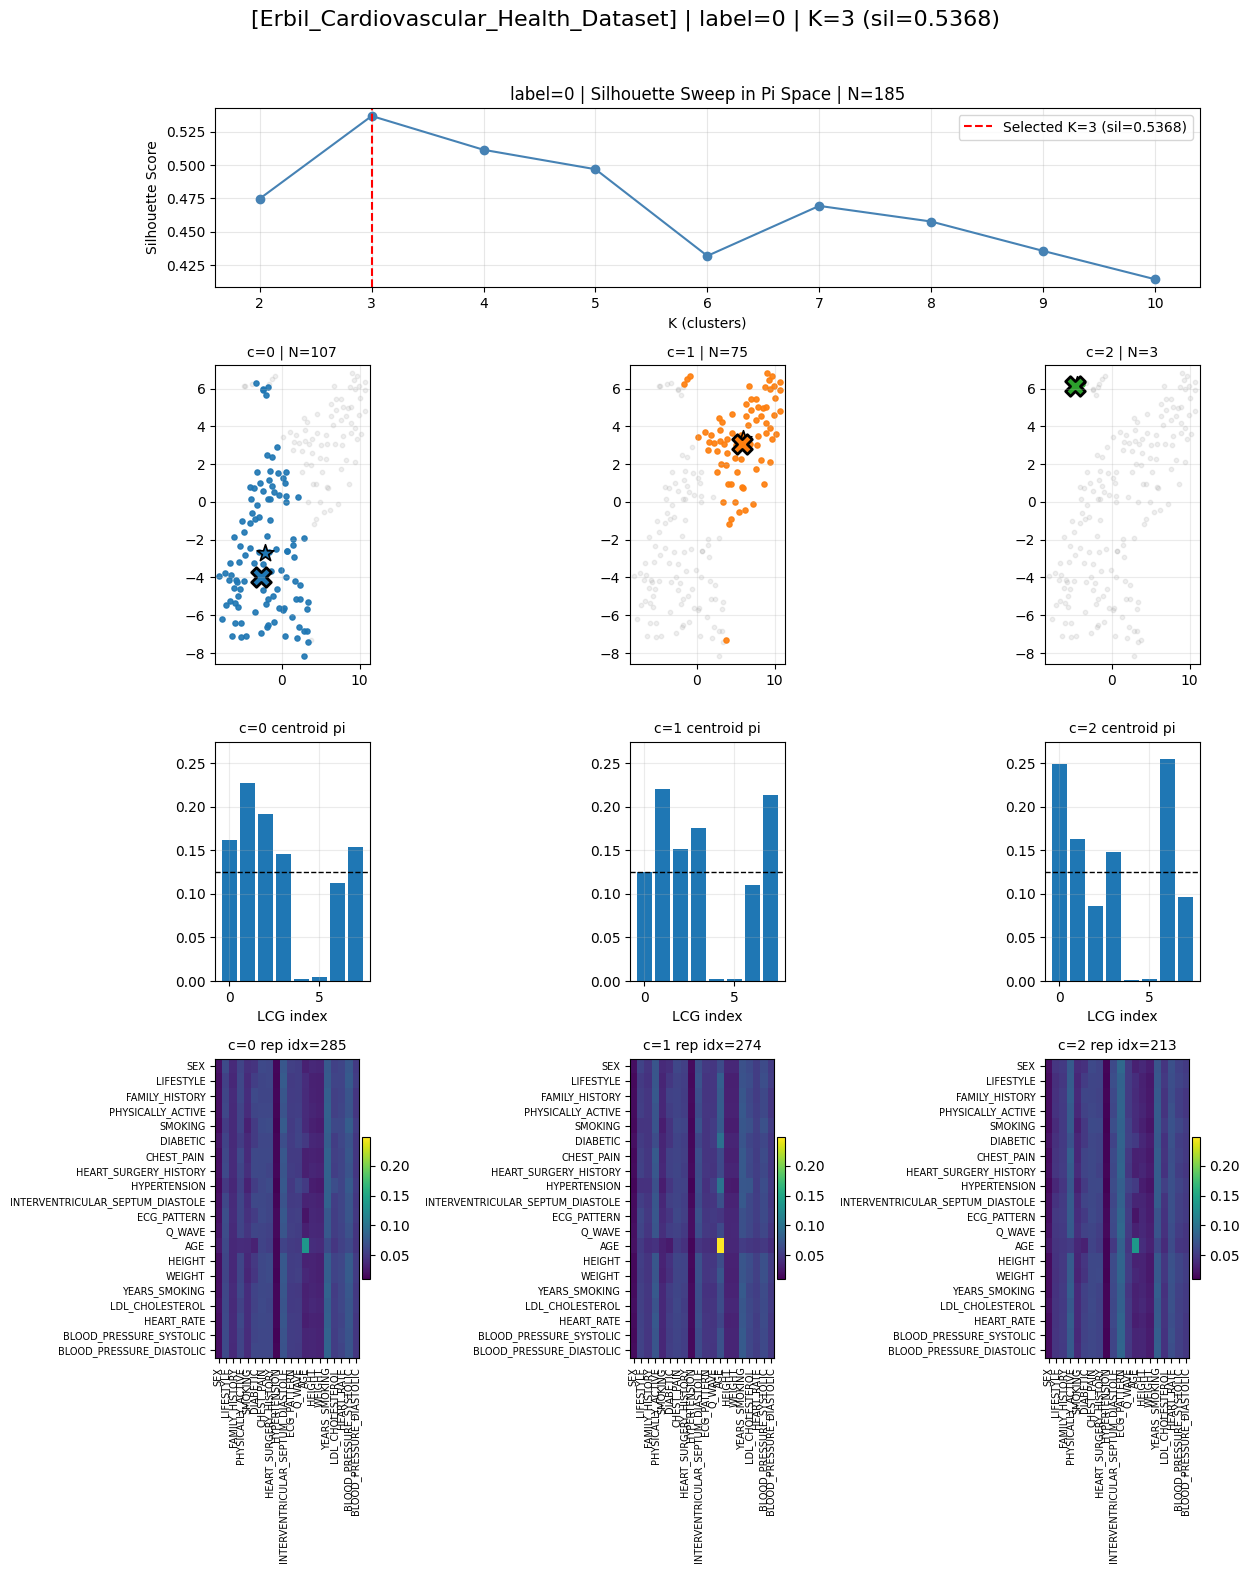

  [label=1] Silhouette sweep: best K=2
    K= 2 | sil=0.5415 <<<
    K= 3 | sil=0.5006
    K= 4 | sil=0.4804
    K= 5 | sil=0.4856
    K= 6 | sil=0.4524
    K= 7 | sil=0.4545
    K= 8 | sil=0.4542
    K= 9 | sil=0.4345
    K=10 | sil=0.4149


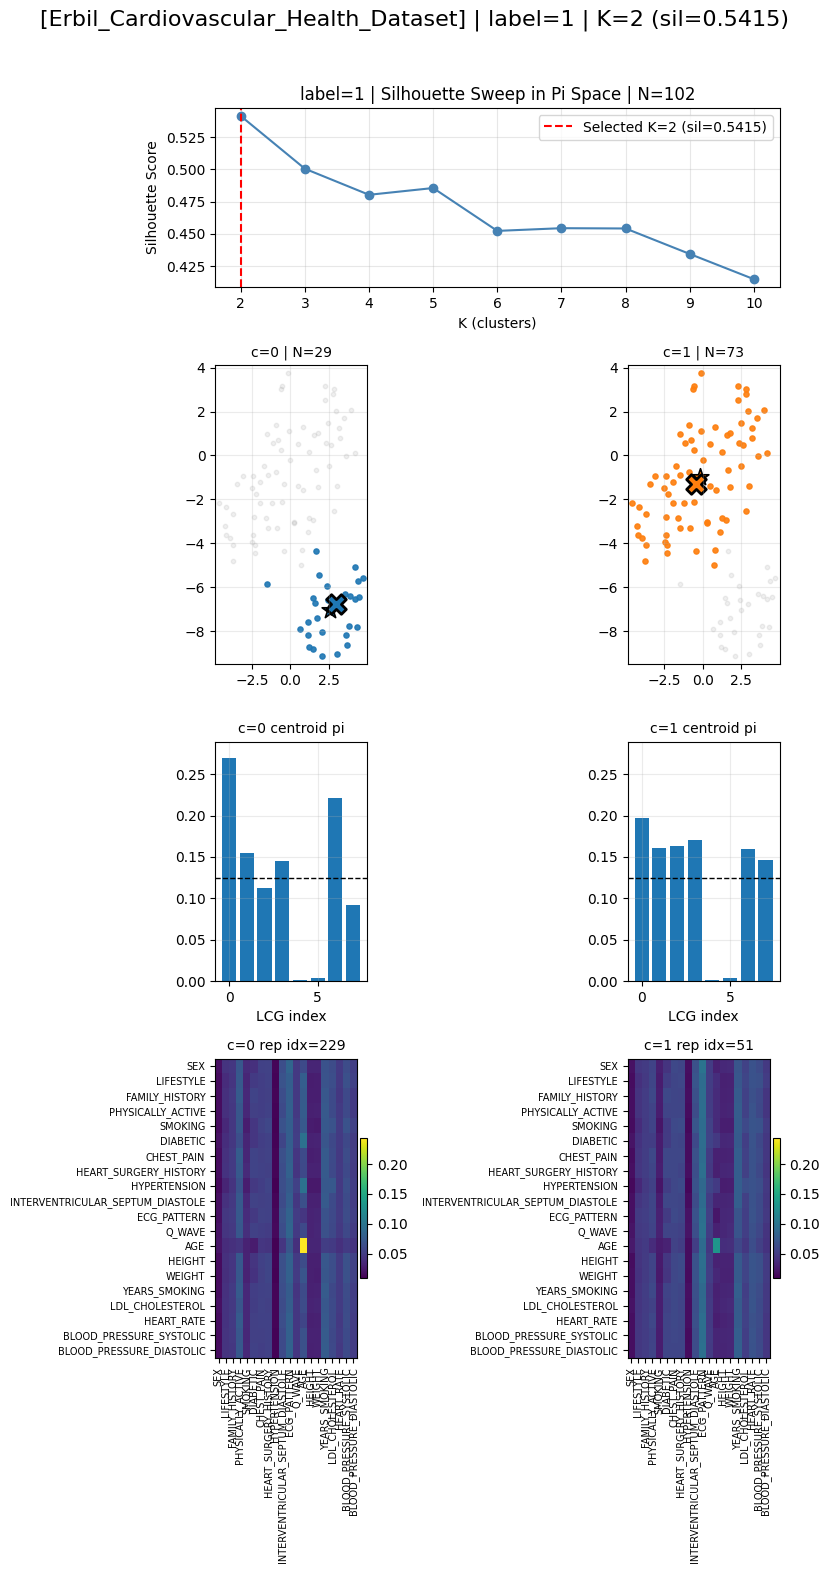

Using source: cardio_SAheart
Collected: 462 samples, M=8
  [label=0] Silhouette sweep: best K=2
    K= 2 | sil=0.5957 <<<
    K= 3 | sil=0.5811
    K= 4 | sil=0.5956
    K= 5 | sil=0.5924
    K= 6 | sil=0.5796
    K= 7 | sil=0.5668
    K= 8 | sil=0.5344
    K= 9 | sil=0.5430
    K=10 | sil=0.4850


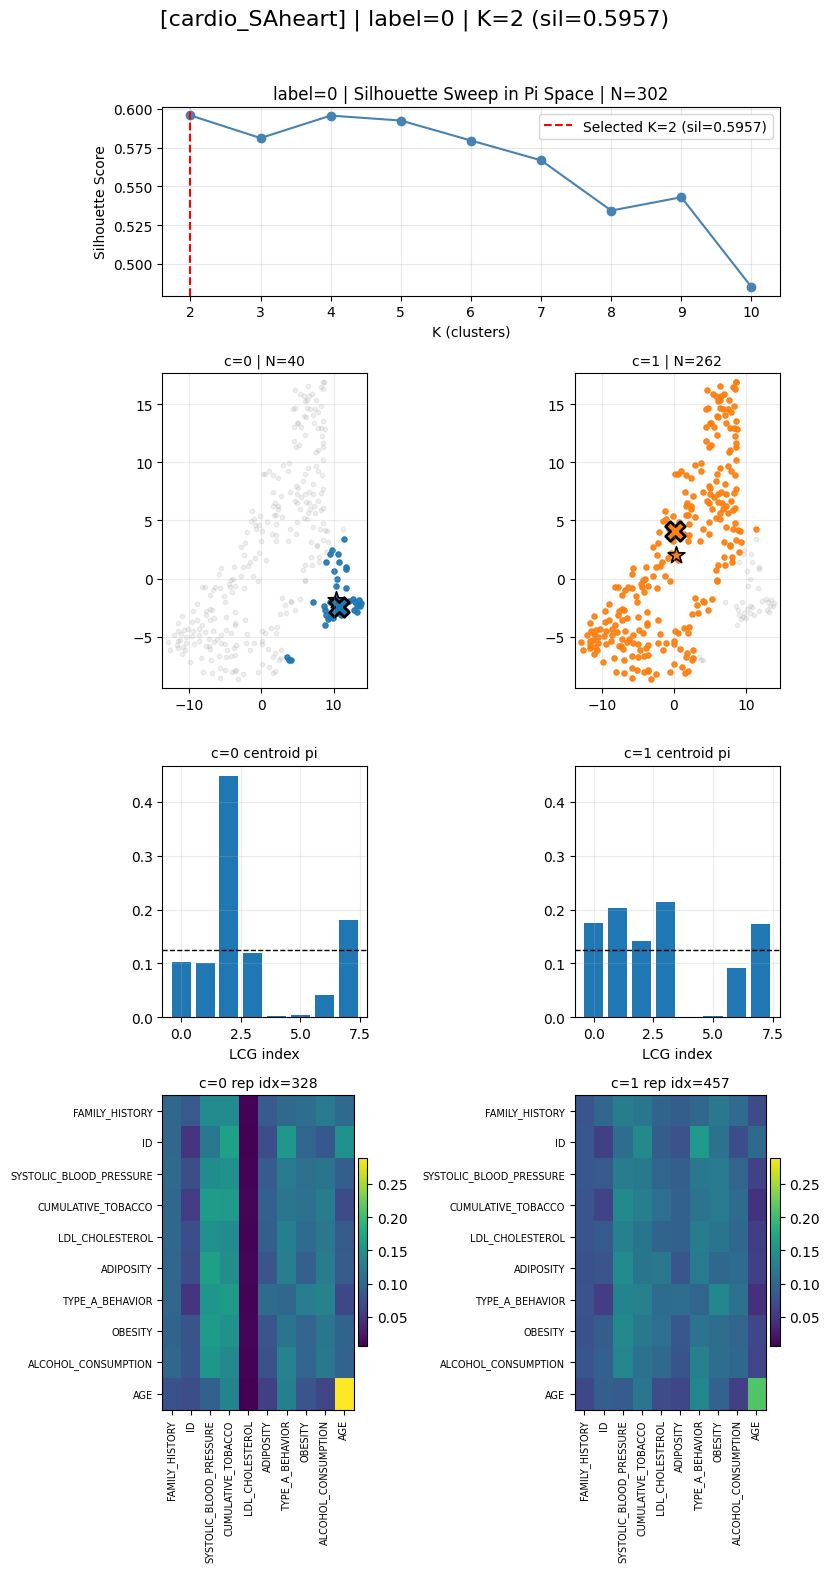

  [label=1] Silhouette sweep: best K=2
    K= 2 | sil=0.7451 <<<
    K= 3 | sil=0.5591
    K= 4 | sil=0.5685
    K= 5 | sil=0.4826
    K= 6 | sil=0.5125
    K= 7 | sil=0.4439
    K= 8 | sil=0.4341
    K= 9 | sil=0.4321
    K=10 | sil=0.4271


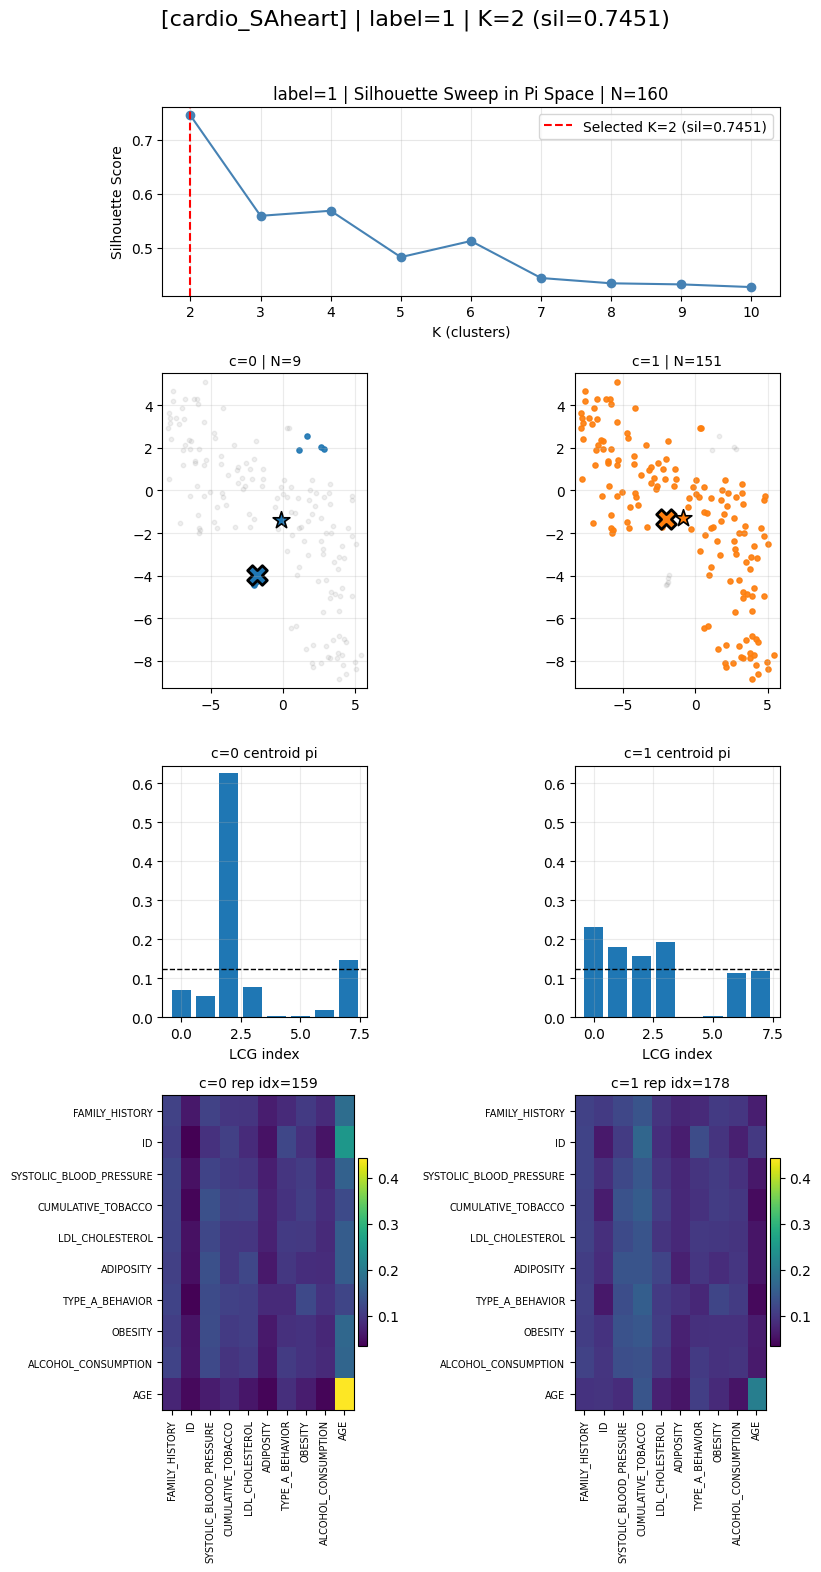

Using source: heart_failure_clinical_records
Collected: 299 samples, M=8
  [label=0] Silhouette sweep: best K=3
    K= 2 | sil=0.5027
    K= 3 | sil=0.5084 <<<
    K= 4 | sil=0.4298
    K= 5 | sil=0.4356
    K= 6 | sil=0.4286
    K= 7 | sil=0.4263
    K= 8 | sil=0.3887
    K= 9 | sil=0.3900
    K=10 | sil=0.3642


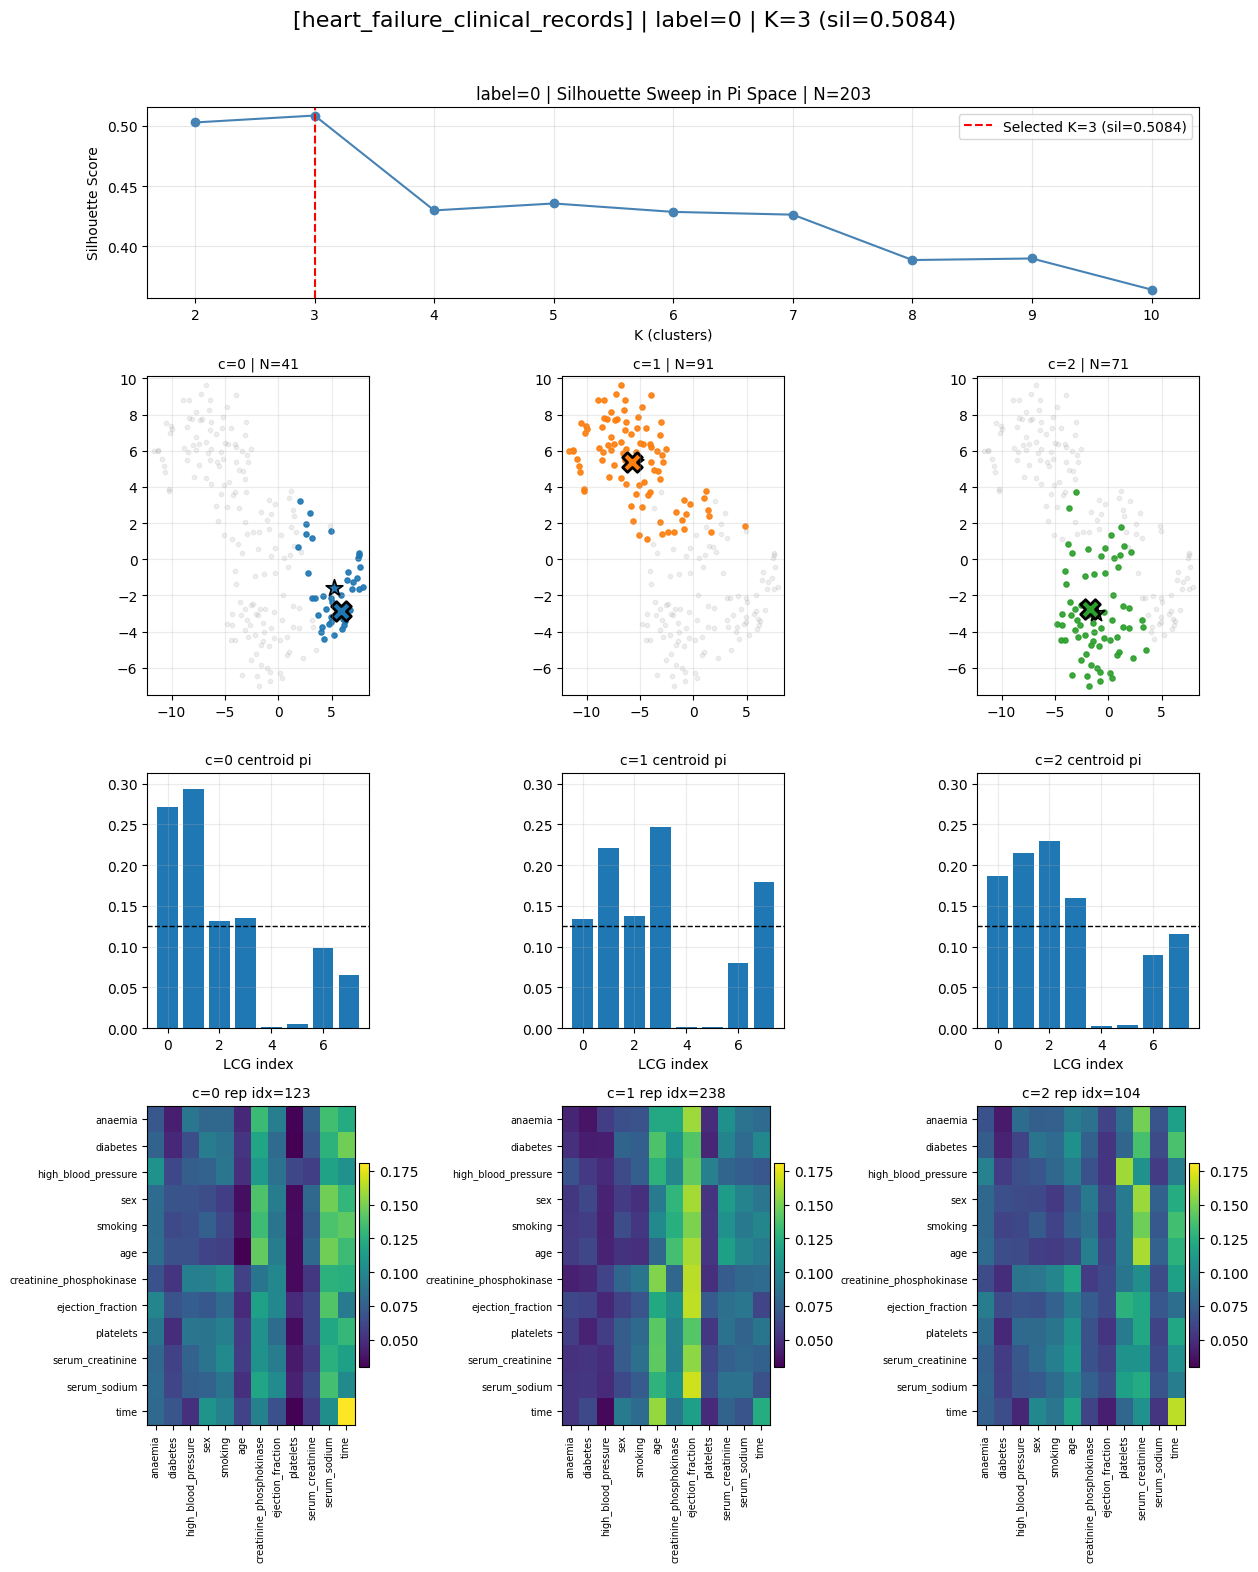

  [label=1] Silhouette sweep: best K=2
    K= 2 | sil=0.5197 <<<
    K= 3 | sil=0.4147
    K= 4 | sil=0.4345
    K= 5 | sil=0.4176
    K= 6 | sil=0.4384
    K= 7 | sil=0.4376
    K= 8 | sil=0.4540
    K= 9 | sil=0.4261
    K=10 | sil=0.3936


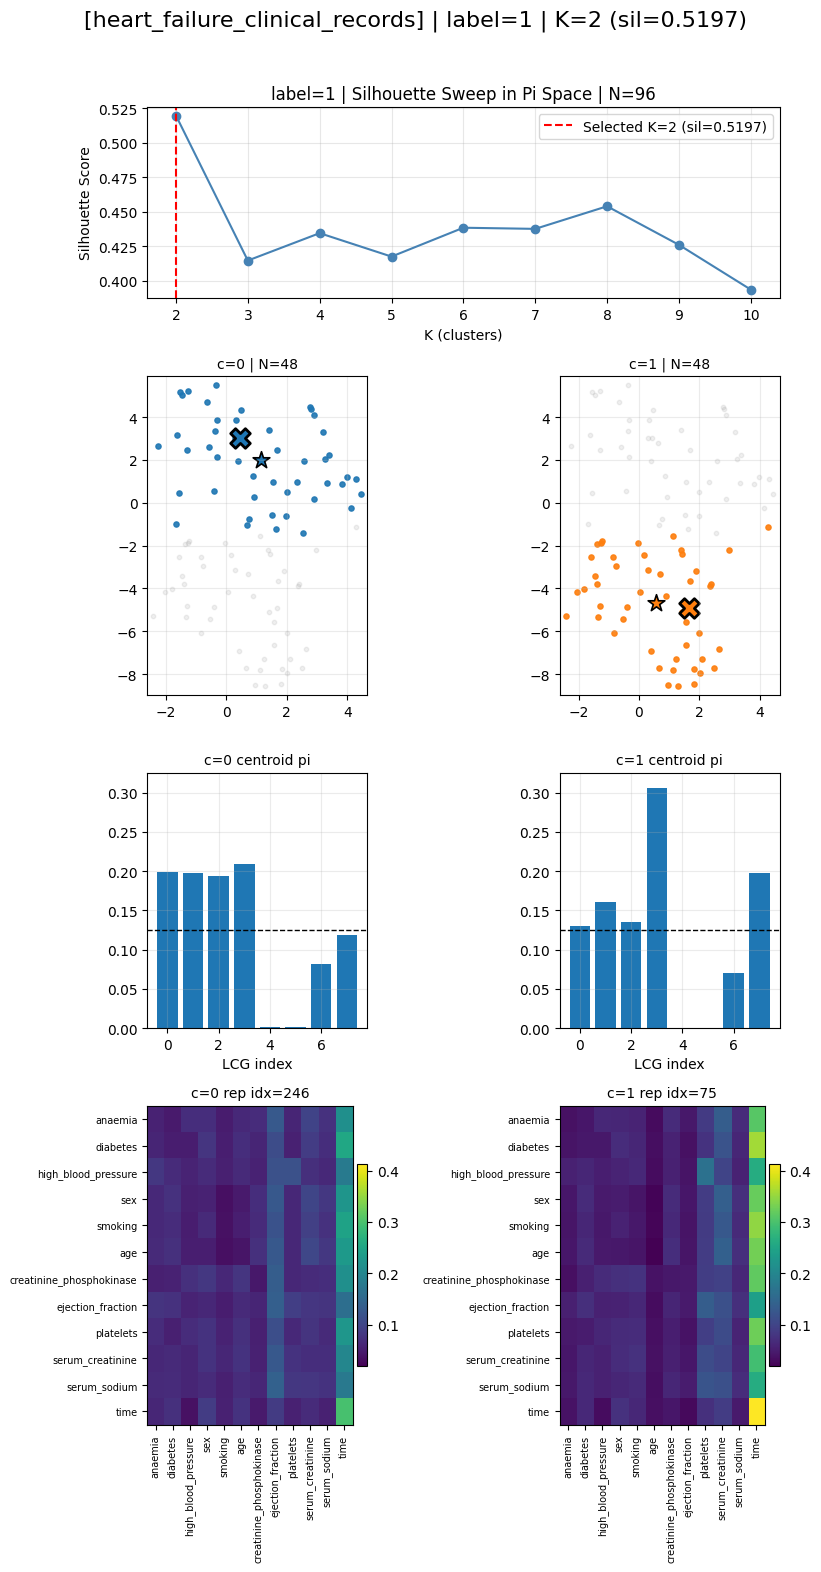

In [28]:
for src in sources:
    result = plot_3xK_by_source(
    model, loaders, device, src,
    extract_feature_names, K="auto"
)

Collected: 3637 samples, M=8, Sources=6

=== label=0 | N=1769 | K=2 | sil=0.7850 ===
  c=0 (N=357): {'Medicaldataset': 357}
  c=1 (N=1412): {'Medicaldataset': 152, 'Cardiovascular_Disease_Dataset': 420, 'Heart_disease_statlog': 150, 'Erbil_Cardiovascular_Health_Dataset': 185, 'cardio_SAheart': 302, 'heart_failure_clinical_records': 203}


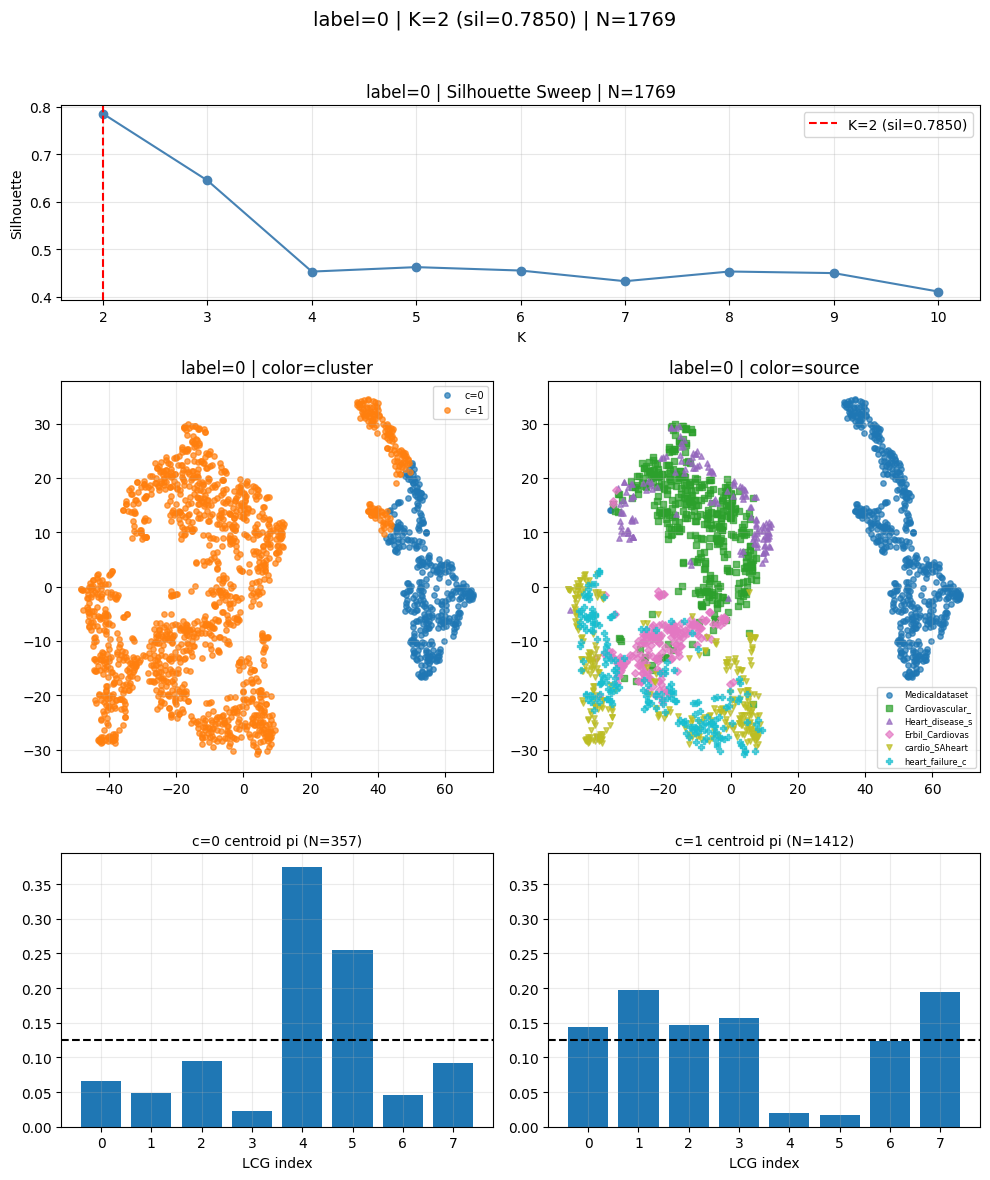


=== label=1 | N=1868 | K=2 | sil=0.7597 ===
  c=0 (N=1503): {'Medicaldataset': 445, 'Cardiovascular_Disease_Dataset': 580, 'Heart_disease_statlog': 120, 'Erbil_Cardiovascular_Health_Dataset': 102, 'cardio_SAheart': 160, 'heart_failure_clinical_records': 96}
  c=1 (N=365): {'Medicaldataset': 365}


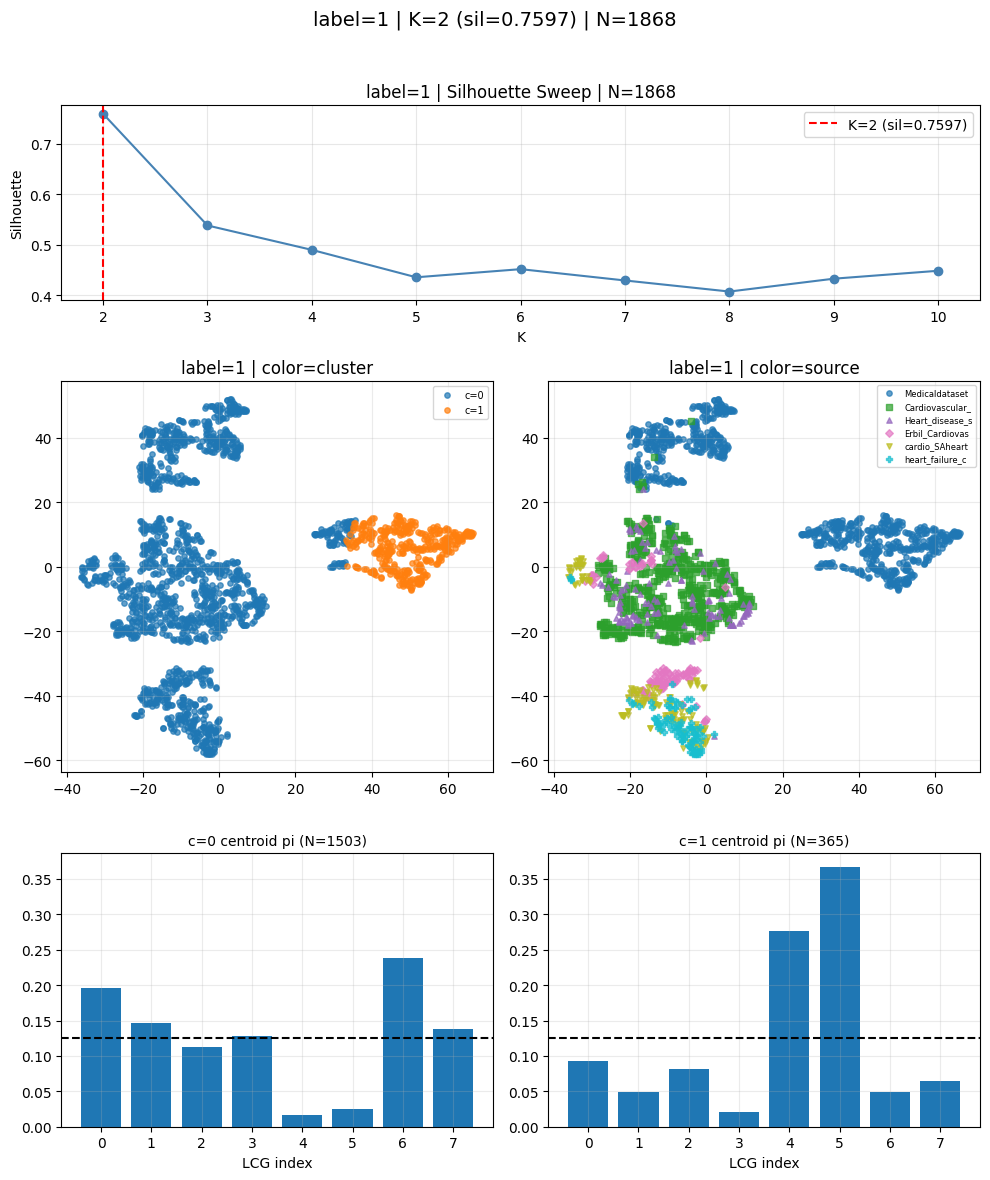

In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


@torch.no_grad()
def collect_all_pi_with_meta(model, loaders, device):
    """모든 source에서 pi, y, source label 수집"""
    model.eval()
    model.args.use_lcg = True

    all_pis, all_ys, all_src = [], [], []
    src_names = []

    for src_idx, (src_name, loader) in enumerate(loaders.items()):
        src_names.append(src_name)
        for batch in loader:
            batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
            _ = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi
            B = pi.shape[0]
            all_pis.append(pi.detach().cpu().numpy())
            all_ys.append(batch_t['y'].detach().cpu().numpy().flatten())
            all_src.extend([src_idx] * B)

    pis = np.concatenate(all_pis, axis=0)
    ys = np.concatenate(all_ys, axis=0).astype(int)
    src_labels = np.array(all_src)
    print(f"Collected: {len(ys)} samples, M={pis.shape[1]}, Sources={len(src_names)}")
    return pis, ys, src_labels, src_names


def find_best_K(X, K_range=range(2, 11), seed=42):
    sil_scores = []
    valid_ks = []
    for k in K_range:
        if k >= len(X):
            break
        km = KMeans(n_clusters=k, random_state=seed, n_init=20).fit(X)
        sil = silhouette_score(X, km.labels_, metric='cosine')
        sil_scores.append(sil)
        valid_ks.append(k)
    best_k = valid_ks[np.argmax(sil_scores)]
    return best_k, list(zip(valid_ks, sil_scores))


def plot_pi_clusters_by_label(pis, ys, src_labels, src_names,
                               K="auto", K_range=range(2, 11), seed=42):
    M = pis.shape[1]
    src_markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '<']
    src_colors = plt.cm.tab10(np.linspace(0, 1, len(src_names)))

    for label in sorted(np.unique(ys)):
        mask = (ys == label)
        X = pis[mask]
        src_sub = src_labels[mask]
        n = len(X)

        # 실루엣 sweep
        if K == "auto":
            best_k, sil_scores = find_best_K(X, K_range=K_range, seed=seed)
            k_eff = best_k
        else:
            k_eff = min(K, n - 1)
            _, sil_scores = find_best_K(X, K_range=K_range, seed=seed)

        km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20).fit(X)
        cid = km.labels_
        C = km.cluster_centers_
        best_sil = silhouette_score(X, cid, metric='cosine') if k_eff >= 2 else 0

        # t-SNE
        perp = max(5, min(40, (n - 1) // 3))
        xy = TSNE(n_components=2, perplexity=perp, learning_rate=200,
                  init="pca", random_state=seed).fit_transform(X)

        print(f"\n=== label={label} | N={n} | K={k_eff} | sil={best_sil:.4f} ===")
        for c in range(k_eff):
            c_mask = (cid == c)
            comp = {src_names[s]: int((c_mask & (src_sub == s)).sum())
                    for s in range(len(src_names)) if (c_mask & (src_sub == s)).sum() > 0}
            print(f"  c={c} (N={c_mask.sum()}): {comp}")

        # --- Plot: 3 rows ---
        # Row 0: silhouette sweep (full span)
        # Row 1: t-SNE (색=cluster, marker=source) + t-SNE (색=source)
        # Row 2: centroid pi bars
        fig = plt.figure(figsize=(max(4 * k_eff, 10), 12))
        gs = fig.add_gridspec(3, max(k_eff, 2), height_ratios=[0.5, 1, 0.7])

        # Row 0: silhouette
        ax = fig.add_subplot(gs[0, :])
        ks_plot = [s[0] for s in sil_scores]
        sils_plot = [s[1] for s in sil_scores]
        ax.plot(ks_plot, sils_plot, 'o-', color='steelblue')
        ax.axvline(x=k_eff, color='red', linestyle='--',
                   label=f'K={k_eff} (sil={best_sil:.4f})')
        ax.set_xlabel('K'); ax.set_ylabel('Silhouette')
        ax.set_title(f'label={label} | Silhouette Sweep | N={n}')
        ax.legend(); ax.grid(True, alpha=0.3)

        # Row 1 left: t-SNE colored by cluster
        ax = fig.add_subplot(gs[1, 0])
        for c in range(k_eff):
            c_mask = (cid == c)
            ax.scatter(xy[c_mask, 0], xy[c_mask, 1],
                       s=15, alpha=0.7, color=f"C{c % 10}", label=f"c={c}")
        ax.set_title(f"label={label} | color=cluster")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.25)

        # Row 1 right: t-SNE colored by source
        if k_eff >= 2:
            ax = fig.add_subplot(gs[1, 1])
        else:
            ax = fig.add_subplot(gs[1, 0])  # 1열이면 겹침
        for s in range(len(src_names)):
            s_mask = (src_sub == s)
            if s_mask.sum() == 0:
                continue
            ax.scatter(xy[s_mask, 0], xy[s_mask, 1],
                       s=15, alpha=0.7, color=src_colors[s],
                       marker=src_markers[s % len(src_markers)],
                       label=src_names[s][:15])
        ax.set_title(f"label={label} | color=source")
        ax.legend(fontsize=6); ax.grid(True, alpha=0.25)

        # Row 2: centroid pi bars
        pi_ymin = max(0, float(C.min()) - 0.02)
        pi_ymax = float(C.max()) + 0.02
        for c in range(k_eff):
            ax = fig.add_subplot(gs[2, c])
            ax.bar(np.arange(M), C[c])
            ax.axhline(1.0 / M, linestyle="--", color="black")
            ax.set_ylim(pi_ymin, pi_ymax)
            ax.set_title(f"c={c} centroid pi (N={int((cid == c).sum())})", fontsize=10)
            ax.set_xlabel("LCG index")
            ax.grid(True, alpha=0.25)

        fig.suptitle(f"label={label} | K={k_eff} (sil={best_sil:.4f}) | N={n}", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


# =========================================================
# 실행
# =========================================================
pis, ys, src_labels, src_names = collect_all_pi_with_meta(model, loaders, device)
plot_pi_clusters_by_label(pis, ys, src_labels, src_names, K="auto")

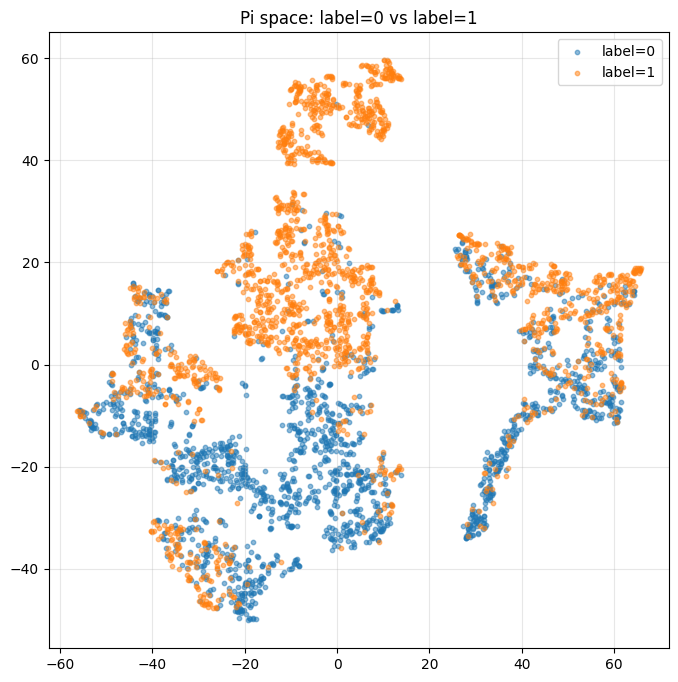

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# 전체 pi로 t-SNE
perp = max(5, min(40, (len(pis) - 1) // 3))
xy = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(pis)

for label in [0, 1]:
    mask = (ys == label)
    ax.scatter(xy[mask, 0], xy[mask, 1], s=10, alpha=0.5,
               label=f"label={label}", color=f"C{label}")

ax.set_title("Pi space: label=0 vs label=1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [31]:
from sklearn.metrics import silhouette_score
sil = silhouette_score(pis, ys)
print(f"Silhouette (label): {sil:.4f}")

Silhouette (label): 0.0897


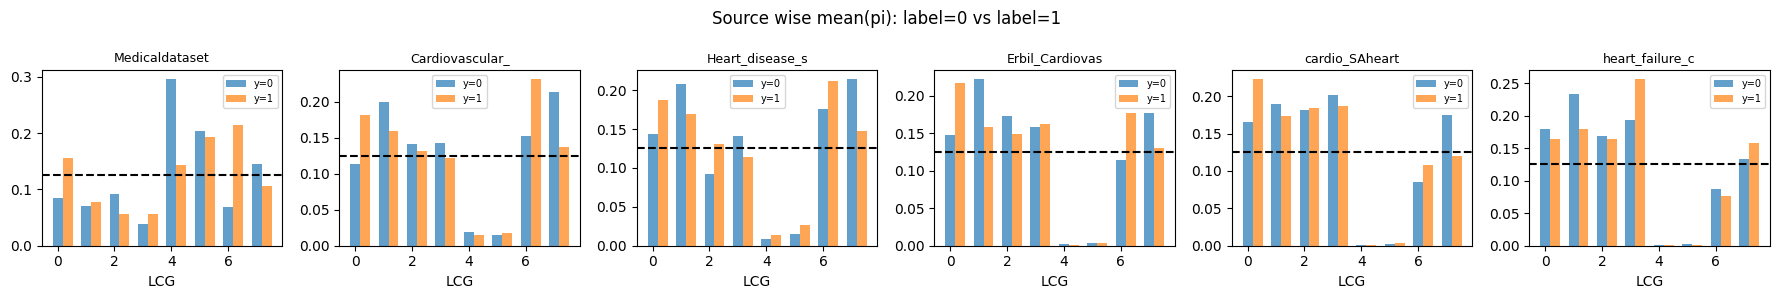

In [32]:
fig, axes = plt.subplots(1, len(src_names), figsize=(3 * len(src_names), 3))
for s, name in enumerate(src_names):
    ax = axes[s]
    s_mask = (src_labels == s)
    for label in [0, 1]:
        mask = s_mask & (ys == label)
        if mask.sum() == 0:
            continue
        mean_pi = pis[mask].mean(axis=0)
        ax.bar(np.arange(pis.shape[1]) + label * 0.35, mean_pi,
               width=0.35, alpha=0.7, label=f"y={label}")
    ax.axhline(1.0 / pis.shape[1], linestyle="--", color="black")
    ax.set_title(name[:15], fontsize=9)
    ax.set_xlabel("LCG")
    ax.legend(fontsize=7)
plt.suptitle("Source wise mean(pi): label=0 vs label=1")
plt.tight_layout()
plt.show()

In [33]:
mean_pi_all = pis.mean(axis=0)
print("Global mean(pi):", np.round(mean_pi_all, 4))
print("Active LCGs (>0.05):", np.where(mean_pi_all > 0.05)[0])
print("Dead LCGs (<0.02):", np.where(mean_pi_all < 0.02)[0])

Global mean(pi): [0.1522 0.147  0.1209 0.1186 0.0791 0.0785 0.1557 0.148 ]
Active LCGs (>0.05): [0 1 2 3 4 5 6 7]
Dead LCGs (<0.02): []


In [34]:
@torch.no_grad()
def collect_d_pi(model, loaders_by_src, device, max_batches=None):
    import torch.nn.functional as F
    model.eval()
    feat_distance = getattr(model.graph_quantizer.args, 'feat_distance', 'cosine')
    
    d_all, pi_all = [], []
    for src, loader in loaders_by_src.items():
        for bi, batch in enumerate(loader):
            if (max_batches is not None) and (bi >= max_batches):
                break
            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            name_embeddings, value_embeddings = [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name  = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            B, N, D = value.shape

            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            src_feat = x_basis[:, 1:, :].contiguous()
            var_att = last_att[:, 0, 1:, 1:]
            log_attn = -torch.log(var_att.clamp_min(1e-8))
            with torch.no_grad():
                q90 = torch.quantile(log_attn.flatten(), 0.9).clamp_min(1e-8)
            src_str = (log_attn / q90).clamp_max(1.0)

            lcg_feat, lcg_struct = model.latent_graph()
            M, K, _ = lcg_feat.shape

            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp  = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp  = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)

            if feat_distance == 'cosine':
                src_norm = F.normalize(src_feat_exp, dim=-1)
                tgt_norm = F.normalize(lcg_feat_exp, dim=-1)
                cos_sim = torch.bmm(src_norm, tgt_norm.transpose(1, 2))
                M_cost = 1.0 - torch.exp(-(1.0 - cos_sim))
            else:
                dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
                M_raw = dist_sq / float(D)
                q90 = torch.quantile(M_raw.detach().flatten(), 0.9).clamp_min(1e-8)
                M_cost = M_raw / q90

            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            alpha = float(model.graph_quantizer.alpha)
            reg   = float(model.graph_quantizer.reg)

            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost,
                alpha=alpha, reg=reg, a=a, b=b,
                max_iter=10, tol=1e-3, grad='envelope'
            )

            d = result.value.reshape(B, M)
            soft_tau = float(model.graph_quantizer.soft_tau)
            pi = torch.softmax(-d / soft_tau, dim=1)

            d_all.append(d.cpu().numpy())
            pi_all.append(pi.cpu().numpy())

    return np.concatenate(d_all, axis=0), np.concatenate(pi_all, axis=0)


[ALL_SOURCES:POOLED] N=3637, M=8
  H_sample_norm: mean=0.8338  (goal: LOW)
  H_batch_norm : 0.9856            (goal: HIGH)
  top1 prob    : mean=0.3006,  median=0.2626
  margin(top1-top2): mean=0.0900, median=0.0518
  mean(pi) deviation from uniform (L1): 0.2058
  argmax usage deviation from uniform (L1): 0.3513
  top4 coverage: min=0.2268, mean=0.5000, max=0.7157


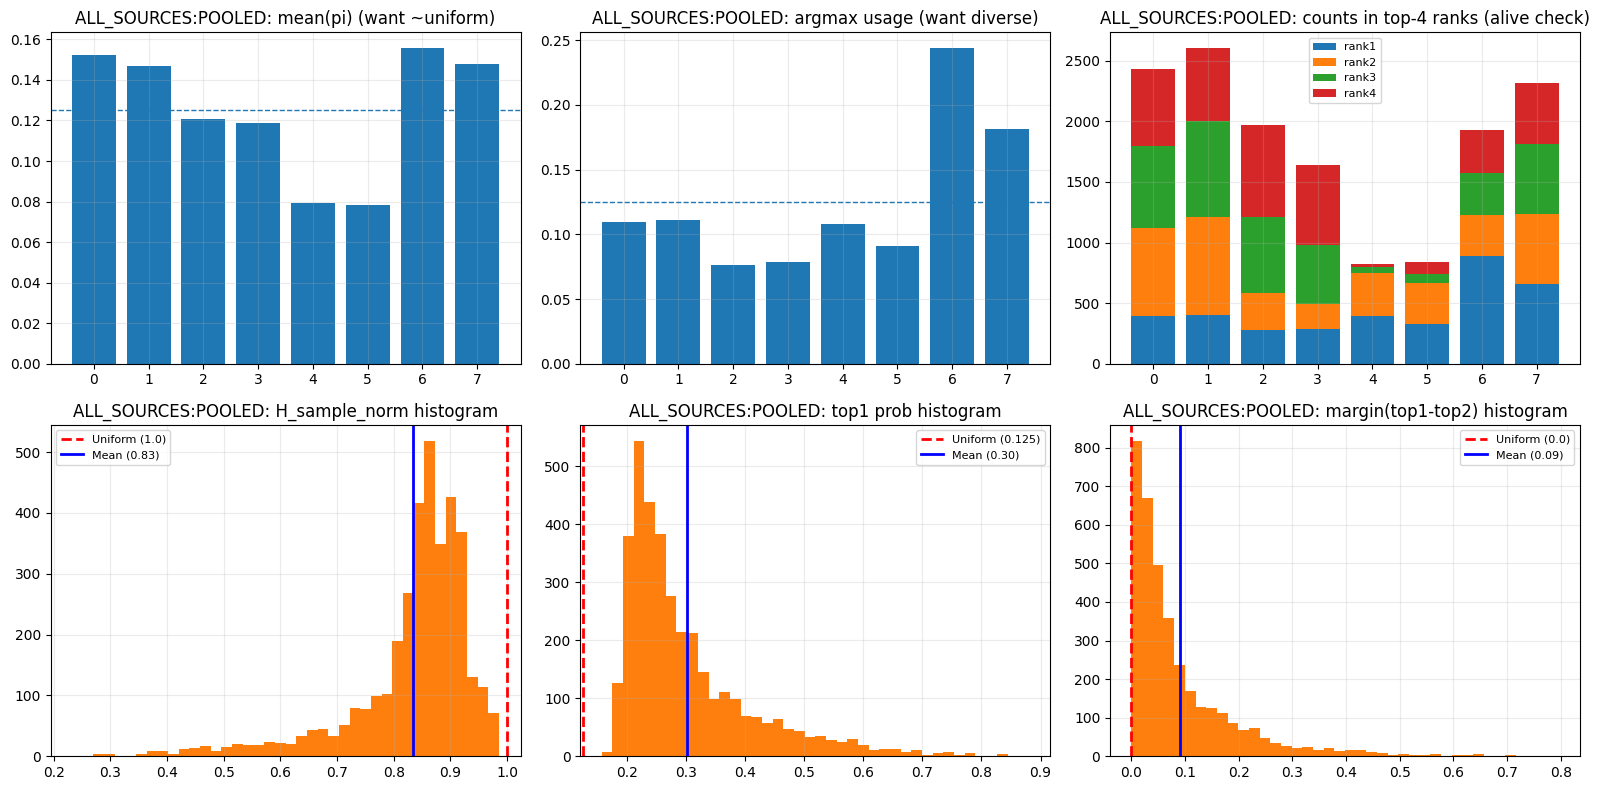


[SRC=Medicaldataset] N=1319, M=8
  H_sample_norm: mean=0.7904  (goal: LOW)
  H_batch_norm : 0.9530            (goal: HIGH)
  top1 prob    : mean=0.3802,  median=0.3629
  margin(top1-top2): mean=0.1555, median=0.1336
  mean(pi) deviation from uniform (L1): 0.3706
  argmax usage deviation from uniform (L1): 0.8939
  top4 coverage: min=0.1463, mean=0.5000, max=0.7430

[SRC=Cardiovascular_Disease_Dataset] N=1000, M=8
  H_sample_norm: mean=0.8890  (goal: LOW)
  H_batch_norm : 0.9101            (goal: HIGH)
  top1 prob    : mean=0.2385,  median=0.2298
  margin(top1-top2): mean=0.0421, median=0.0353
  mean(pi) deviation from uniform (L1): 0.4319
  argmax usage deviation from uniform (L1): 0.9960
  top4 coverage: min=0.0000, mean=0.5000, max=0.9380

[SRC=Heart_disease_statlog] N=270, M=8
  H_sample_norm: mean=0.8781  (goal: LOW)
  H_batch_norm : 0.9011            (goal: HIGH)
  top1 prob    : mean=0.2410,  median=0.2327
  margin(top1-top2): mean=0.0421, median=0.0310
  mean(pi) deviation from

In [35]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 1) collect pi (all samples)
# -----------------------------
@torch.no_grad()
def collect_all_pi(model, loaders, device, max_batches_per_src=None):
    model.eval()
    model.args.use_lcg = True  # 체크포인트 로드 시 꺼져있을 수 있음
    out = {}
    all_pi = []

    for src, loader in loaders.items():
        pis = []
        for bi, batch in enumerate(loader):
            if max_batches_per_src is not None and bi >= max_batches_per_src:
                break
            batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            _ = model.predict(batch_t, return_all=True)
            pi = model.graph_quantizer.last_pi
            if pi is None:
                raise RuntimeError("last_pi is None")

            pis.append(pi.detach().cpu().numpy())

        if len(pis) == 0:
            continue
        pis = np.concatenate(pis, axis=0)
        out[src] = pis
        all_pi.append(pis)

    all_pi = np.concatenate(all_pi, axis=0) if len(all_pi) else None
    return out, all_pi


# -----------------------------
# 2) diagnostics
# -----------------------------
def _entropy_rows(P, eps=1e-12):
    P = np.clip(P, eps, 1.0)
    return -(P * np.log(P)).sum(axis=1)  # [N]

def _top1_top2(P):
    # returns top1 prob, top2 prob, margin
    part = np.partition(P, -2, axis=1)          # last two are top2 (unordered)
    top2 = part[:, -2]
    top1 = part[:, -1]
    # ensure top1>=top2 (partition doesn't guarantee order between last two)
    t1 = np.maximum(top1, top2)
    t2 = np.minimum(top1, top2)
    return t1, t2, (t1 - t2)

def _rank_hist(P, max_rank=4):
    # counts: for each m, how often it appears in rank r (1..max_rank)
    # rank 1 = argmax
    N, M = P.shape
    order = np.argsort(-P, axis=1)  # descending
    counts = np.zeros((max_rank, M), dtype=np.int64)
    for r in range(max_rank):
        idx_m = order[:, r]
        counts[r] = np.bincount(idx_m, minlength=M)
    return counts  # [max_rank, M]

def diagnose_pi(P, tag="POOLED", show=True):
    P = np.asarray(P)
    N, M = P.shape
    H_max = np.log(M)

    # --- entropies ---
    Hs = _entropy_rows(P)            # [N]
    Hs_norm = Hs / H_max
    pibar = P.mean(axis=0)
    Hb = -(np.clip(pibar, 1e-12, 1.0) * np.log(np.clip(pibar, 1e-12, 1.0))).sum()
    Hb_norm = Hb / H_max

    # --- usage / sharpness proxies ---
    argmax = P.argmax(axis=1)
    usage = np.bincount(argmax, minlength=M) / N  # [M]
    mean_pi = pibar
    t1, t2, margin = _top1_top2(P)

    # --- "dead but alive" check: rank counts ---
    rank_counts = _rank_hist(P, max_rank=4)  # [4, M] ranks 1..4

    # --- prints ---
    print(f"\n[{tag}] N={N}, M={M}")
    print(f"  H_sample_norm: mean={Hs_norm.mean():.4f}  (goal: LOW)")
    print(f"  H_batch_norm : {Hb_norm:.4f}            (goal: HIGH)")
    print(f"  top1 prob    : mean={t1.mean():.4f},  median={np.median(t1):.4f}")
    print(f"  margin(top1-top2): mean={margin.mean():.4f}, median={np.median(margin):.4f}")
    print(f"  mean(pi) deviation from uniform (L1): {np.abs(mean_pi - 1.0/M).sum():.4f}")
    print(f"  argmax usage deviation from uniform (L1): {np.abs(usage - 1.0/M).sum():.4f}")

    # rank-based "alive" quick view
    # 각 m이 rank<=4에 들어오는 비율
    top4_frac = rank_counts.sum(axis=0) / N
    print(f"  top4 coverage: min={top4_frac.min():.4f}, mean={top4_frac.mean():.4f}, max={top4_frac.max():.4f}")

    if not show:
        return

    # ---------------- plots ----------------
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # (1) mean(pi) + argmax usage
    axes[0,0].bar(np.arange(M), mean_pi)
    axes[0,0].axhline(1.0/M, linestyle="--", linewidth=1)
    axes[0,0].set_title(f"{tag}: mean(pi) (want ~uniform)")
    axes[0,0].grid(True, alpha=0.25)

    axes[0,1].bar(np.arange(M), usage)
    axes[0,1].axhline(1.0/M, linestyle="--", linewidth=1)
    axes[0,1].set_title(f"{tag}: argmax usage (want diverse)")
    axes[0,1].grid(True, alpha=0.25)

    # (2) rank1~4 counts stacked (dead-but-alive 체크 핵심)
    # rank1=argmax, rank2, rank3, rank4
    bottoms = np.zeros(M, dtype=np.int64)
    labels = ["rank1", "rank2", "rank3", "rank4"]
    for r in range(4):
        axes[0,2].bar(np.arange(M), rank_counts[r], bottom=bottoms, label=labels[r])
        bottoms += rank_counts[r]
    axes[0,2].set_title(f"{tag}: counts in top-4 ranks (alive check)")
    axes[0,2].grid(True, alpha=0.25)
    axes[0,2].legend(fontsize=8, frameon=True)

    # (3) hist: sample entropy
    axes[1,0].hist(Hs_norm, bins=40)
    axes[1,0].set_title(f"{tag}: H_sample_norm histogram (want left)")
    axes[1,0].grid(True, alpha=0.25)

    # (4) hist: top1 prob
    axes[1,1].hist(t1, bins=40)
    axes[1,1].set_title(f"{tag}: top1 prob histogram (want right)")
    axes[1,1].grid(True, alpha=0.25)

    # (5) hist: margin
    axes[1,2].hist(margin, bins=40)
    axes[1,2].set_title(f"{tag}: margin(top1-top2) histogram (want right)")
    axes[1,2].grid(True, alpha=0.25)
    axes[1,0].hist(Hs_norm, bins=40)
    axes[1,0].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Uniform (1.0)')
    axes[1,0].axvline(x=Hs_norm.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean ({Hs_norm.mean():.2f})')
    axes[1,0].set_title(f"{tag}: H_sample_norm histogram")
    axes[1,0].legend(fontsize=8)
    axes[1,0].grid(True, alpha=0.25)

    # (4) hist: top1 prob
    axes[1,1].hist(t1, bins=40)
    axes[1,1].axvline(x=1.0/M, color='red', linestyle='--', linewidth=2, label=f'Uniform ({1/M:.3f})')
    axes[1,1].axvline(x=t1.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean ({t1.mean():.2f})')
    axes[1,1].set_title(f"{tag}: top1 prob histogram")
    axes[1,1].legend(fontsize=8)
    axes[1,1].grid(True, alpha=0.25)

    # (5) hist: margin
    axes[1,2].hist(margin, bins=40)
    axes[1,2].axvline(x=0.0, color='red', linestyle='--', linewidth=2, label='Uniform (0.0)')
    axes[1,2].axvline(x=margin.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean ({margin.mean():.2f})')
    axes[1,2].set_title(f"{tag}: margin(top1-top2) histogram")
    axes[1,2].legend(fontsize=8)
    axes[1,2].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 3) run (pooled + per source)
# -----------------------------
pi_by_src, pi_all = collect_all_pi(model, loaders, device, max_batches_per_src=None)

diagnose_pi(pi_all, tag="ALL_SOURCES:POOLED", show=True)

for src, P in pi_by_src.items():
    diagnose_pi(P, tag=f"SRC={src}", show=False)  # source별은 출력만, 그림은 원하면 True로


- H_sample norm histogram (want left)
    - 각 샘플의 entropy H(pi)를 최대 엔트로피 log M으로 나누어 normalize
    - 0에 가까우면 거의 one hot이고 
    - 1에 가까우면 uniform 
    - 현재 막대가 0.98 ~ 1.0 에 몰려 있어서 sample entropy 낮게와는 정반대

- top1 prob histogram (want right)
    - 각 샘플에서 max_m pi_m 가장 큰 값의 분포 
    - flat이면 top 1이 1/M

- top1 - top2 histogram 
    - 각 샘플에서 (1등 확률 - 2등 확률) 차이 
    - 결정의 확신도 
    - 샤프하면 top1이 크고, top2가 작아서 margin이 크게 나옴 
    - 애매하면 top 1 ~ top 2여서 margin이 0 근처 
    - 현재 0 ~ 0.03 근처여서 top1과 top2가 거의 비슷함.

< 결과 >
- Top 1 과 Top 2의 차이가 거의 없다면 이들의 cost 차이가 없음을 의미 

In [36]:
# init_lcg 직후의 node_embeddings로 centrality 확인
node_emb = model.latent_graph.node_embeddings.data  # [M, K, D]
centroids = node_emb.mean(dim=1)  # [M, D]

# 데이터 전체 centroid (init_lcg에서 수집한 CLS의 평균)와의 거리
data_center = centroids.mean(dim=0)  # [D] — 전체 LCG 중심의 근사
dist_to_center = torch.cdist(centroids.unsqueeze(0), data_center.unsqueeze(0).unsqueeze(0)).squeeze()
print("LCG별 data center까지 거리:")
for m in range(M):
    print(f"  LCG {m}: {dist_to_center[m].item():.4f}")

LCG별 data center까지 거리:
  LCG 0: 6.9525
  LCG 1: 4.5826
  LCG 2: 13.0407
  LCG 3: 5.5710
  LCG 4: 4.8424
  LCG 5: 5.2412
  LCG 6: 5.3757
  LCG 7: 6.3395


In [37]:
# 1. Source별 d_commit 순서 + 2. Node embedding 다양성
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    for src_name, loader in loaders.items():
        batch = next(iter(loader))
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # forward해서 pi 얻기
        _ = model.predict(batch, return_all=True)
        pi = model.graph_quantizer.last_pi  # [B, M]
        
        # d_commit 순서
        argmax_counts = torch.bincount(pi.argmax(1), minlength=5)
        rank_order = pi.mean(0).argsort(descending=True)
        
        print(f"\n=== {src_name} (N nodes = {batch.get('cat_value_embeddings', batch.get('num_prompt_embeddings')).shape[1]}) ===")
        print(f"  mean pi: {pi.mean(0).cpu().numpy().round(4)}")
        print(f"  argmax:  {argmax_counts.cpu().numpy()}")
        print(f"  순서:    {rank_order.cpu().numpy()}")


=== Medicaldataset (N nodes = 1) ===
  mean pi: [0.1468 0.0813 0.0651 0.0502 0.183  0.1692 0.1888 0.1155]
  argmax:  [ 1  0  0  0 10  5 11  5]
  순서:    [6 4 5 0 7 1 2 3]

=== Cardiovascular_Disease_Dataset (N nodes = 5) ===
  mean pi: [0.1505 0.178  0.1303 0.1289 0.0185 0.0174 0.1992 0.1772]
  argmax:  [ 3  4  1  0  0  0 13 11]
  순서:    [6 1 7 0 2 3 4 5]

=== Heart_disease_statlog (N nodes = 6) ===
  mean pi: [0.1647 0.1878 0.1106 0.1299 0.0102 0.019  0.193  0.1847]
  argmax:  [ 2  7  1  0  0  0 10 12]
  순서:    [6 1 7 0 3 2 5 4]

=== Erbil_Cardiovascular_Health_Dataset (N nodes = 12) ===
  mean pi: [0.1703 0.2059 0.1755 0.1591 0.0019 0.004  0.1249 0.1585]
  argmax:  [ 5 16  5  1  0  0  1  4]
  순서:    [1 2 0 3 7 6 5 4]

=== cardio_SAheart (N nodes = 1) ===
  mean pi: [0.1913 0.1956 0.1609 0.2073 0.0009 0.0019 0.0969 0.1453]
  argmax:  [ 9  1  8 13  0  0  0  1]
  순서:    [3 1 0 2 7 6 5 4]

=== heart_failure_clinical_records (N nodes = 5) ===
  mean pi: [0.1792 0.2179 0.1853 0.2031 0.0011

In [38]:
# 각 LCG의 CT와 각 source의 CS 간 구조적 유사도
import torch

model.eval()
with torch.no_grad():
    # LCG의 CT (target structure)
    if model.latent_graph.struct_mode == 'static':
        CT = 1.0 - torch.sigmoid(model.latent_graph.adj_param.data)  # [M, K, K]
    
    print("=== CT 통계 ===")
    for m in range(M):
        ct = CT[m]
        print(f"  LCG {m}: mean={ct.mean():.4f}, std={ct.std():.4f}, "
              f"diag_mean={ct.diag().mean():.4f}, offdiag_mean={ct[~torch.eye(ct.size(0),dtype=bool)].mean():.4f}")
    
    # LCG 간 CT 유사도
    print("\n=== LCG 간 CT 유사도 (Frobenius) ===")
    for i in range(5):
        for j in range(i+1, 5):
            diff = (CT[i] - CT[j]).norm()
            print(f"  LCG {i} vs {j}: {diff.item():.4f}")
    
    # LCG 7 vs 나머지의 평균 차이
    print("\n=== LCG 7 vs 나머지 ===")
    for m in range(5):
        if m == 7: continue
        diff = (CT[4] - CT[m]).norm()
        print(f"  LCG 7 vs {m}: {diff.item():.4f}")

=== CT 통계 ===
  LCG 0: mean=0.4996, std=0.3370, diag_mean=0.0098, offdiag_mean=0.5695
  LCG 1: mean=0.4858, std=0.3128, diag_mean=0.0098, offdiag_mean=0.5538
  LCG 2: mean=0.4895, std=0.3244, diag_mean=0.0134, offdiag_mean=0.5575
  LCG 3: mean=0.5027, std=0.3316, diag_mean=0.0093, offdiag_mean=0.5732
  LCG 4: mean=0.3625, std=0.3012, diag_mean=0.0134, offdiag_mean=0.4124
  LCG 5: mean=0.3922, std=0.3375, diag_mean=0.0133, offdiag_mean=0.4463
  LCG 6: mean=0.4623, std=0.3133, diag_mean=0.0110, offdiag_mean=0.5268
  LCG 7: mean=0.4751, std=0.3153, diag_mean=0.0118, offdiag_mean=0.5413

=== LCG 간 CT 유사도 (Frobenius) ===
  LCG 0 vs 1: 2.7026
  LCG 0 vs 2: 2.2254
  LCG 0 vs 3: 3.2311
  LCG 0 vs 4: 3.3554
  LCG 1 vs 2: 2.5554
  LCG 1 vs 3: 3.3048
  LCG 1 vs 4: 2.4585
  LCG 2 vs 3: 3.1561
  LCG 2 vs 4: 3.0580
  LCG 3 vs 4: 3.4047

=== LCG 7 vs 나머지 ===
  LCG 7 vs 0: 3.3554
  LCG 7 vs 1: 2.4585
  LCG 7 vs 2: 3.0580
  LCG 7 vs 3: 3.4047
  LCG 7 vs 4: 0.0000


In [39]:
# # 이미 data_pool이 있으니까 바로 hierarchical 시뮬레이션
# from sklearn.cluster import KMeans
# # data_pool 재구성: 모든 source의 node embeddings 수집
# model.eval()
# data_pool_list = []
# with torch.no_grad():
#     for src, loader in loaders.items():
#         for batch in loader:
#             batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
            
#             name_embs, val_embs = [], []
#             if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
#             if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
#             if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
#             if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
#             name = torch.cat(name_embs, dim=1)
#             val = torch.cat(val_embs, dim=1)
#             x = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
#             for l in range(model.num_basis_layers):
#                 norm_x = model.basis_layer_norms[l](x)
#                 out, _ = model.basis_layers[l](name, norm_x)
#                 x = x + out.reshape(x.size(0), x.size(1), model.input_dim)
            
#             node_emb = x[:, 1:, :].cpu().numpy()  # [B, N, D]
#             for b in range(node_emb.shape[0]):
#                 data_pool_list.append(node_emb[b])  # [N, D]

# data_pool = np.concatenate(data_pool_list, axis=0)  # [total_nodes, D]
# print(f"data_pool shape: {data_pool.shape}")
# K = model.latent_graph.node_embeddings.shape[1]  # 자동으로 4 or 8
# M = model.latent_graph.node_embeddings.shape[0]
# km_global = KMeans(n_clusters=M, n_init=10, random_state=args.random_seed).fit(data_pool)

# centroids_hier = np.zeros((M, K, 768))
# for m in range(M):
#     group = data_pool[km_global.labels_ == m]
#     print(f"LCG {m}: {len(group)} samples")
#     km_local = KMeans(n_clusters=K, n_init=10, random_state=args.random_seed).fit(group)
#     centroids_hier[m] = km_local.cluster_centers_

# # CT std 비교
# centroids_t = torch.tensor(centroids_hier, dtype=torch.float32)
# dist = torch.cdist(centroids_t, centroids_t, p=2) ** 2
# for m in range(M):
#     q90 = torch.quantile(dist[m].flatten(), 0.9).clamp_min(1e-8)
#     d = (dist[m] / q90).clamp_max(1.0)
#     ct = 1.0 - d
#     # data center 거리도
#     group_center = centroids_hier[m].mean(axis=0)
#     dc = np.linalg.norm(group_center - data_pool.mean(axis=0))
#     print(f"  LCG {m}: CT mean={ct.mean():.4f}, std={ct.std():.4f}, data_center_dist={dc:.4f}")

In [40]:
# # Round robin 시뮬레이션
# K = model.latent_graph.node_embeddings.shape[1]  # 자동으로 4 or 8
# M = model.latent_graph.node_embeddings.shape[0]

# kmeans_rr = KMeans(n_clusters=M*K, n_init=10, random_state=args.random_seed).fit(data_pool)
# centers_rr = torch.tensor(kmeans_rr.cluster_centers_, dtype=torch.float32)
# rr_centroids = centers_rr.view(K, M, 768).transpose(0, 1).contiguous()

# # 모델에 round robin 적용
# model.latent_graph.node_embeddings.data.copy_(rr_centroids.to(device))

# # adj_param도 초기화
# dist = torch.cdist(rr_centroids.to(device), rr_centroids.to(device), p=2) ** 2
# for m in range(M):
#     q90 = torch.quantile(dist[m].flatten(), 0.9).clamp_min(1e-8)
#     dist[m] = (dist[m] / q90).clamp_max(1.0)
# target = (1.0 - dist).clamp(0.01, 0.99)
# adj_init = torch.log(target / (1.0 - target))
# model.latent_graph.adj_param.data.copy_(adj_init.to(device))

# # Source별 확인
# args.use_lcg = True
# model.eval()
# with torch.no_grad():
#     for src_name, loader in loaders.items():
#         batch = next(iter(loader))
#         batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
#         _ = model.predict(batch, return_all=True)
#         pi = model.graph_quantizer.last_pi
#         margin = (pi.topk(2, dim=1)[0][:, 0] - pi.topk(2, dim=1)[0][:, 1]).mean()
#         print(f"{src_name}:")
#         print(f"  mean pi: {pi.mean(0).cpu().numpy().round(4)}")
#         print(f"  argmax:  {torch.bincount(pi.argmax(1), minlength=8).cpu().numpy()}")
#         print(f"  margin:  {margin.item():.4f}")

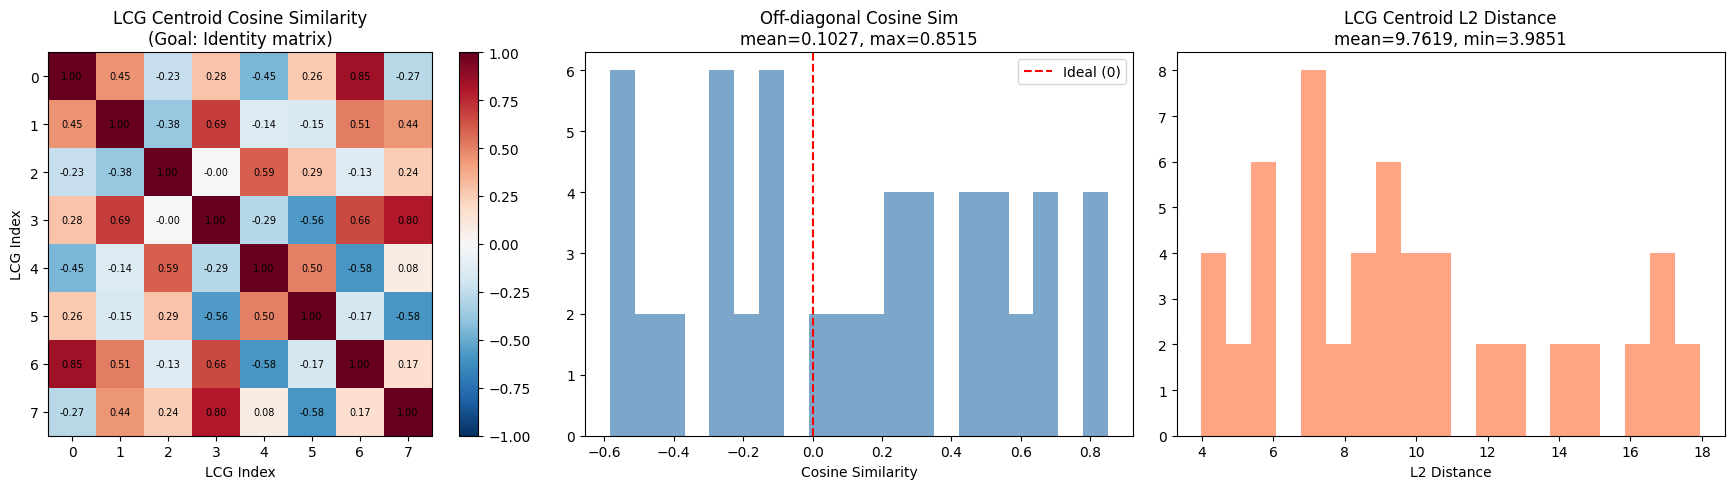


Orth loss value: 0.172313
Off-diag cosine sim: mean=0.1027, std=0.4317
L2 distance: mean=9.7619, min=3.9851


In [41]:
@torch.no_grad()
def visualize_orth_effect(model, device):
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    
    # LCG centroid
    centroids = lcg_feat.mean(dim=1)  # [M, D]
    centroids_norm = F.normalize(centroids, dim=-1)
    
    # Gram matrix (cosine similarity)
    gram = (centroids_norm @ centroids_norm.t()).cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # (1) Gram matrix heatmap — 대각선만 1이고 나머지 0이면 완벽
    im = axes[0].imshow(gram, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[0].set_title(f'LCG Centroid Cosine Similarity\n(Goal: Identity matrix)')
    axes[0].set_xlabel('LCG Index')
    axes[0].set_ylabel('LCG Index')
    for i in range(M):
        for j in range(M):
            axes[0].text(j, i, f'{gram[i,j]:.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=axes[0])
    
    # (2) Off-diagonal similarity 분포 — 0에 가까울수록 좋음
    mask = ~np.eye(M, dtype=bool)
    off_diag = gram[mask]
    axes[1].hist(off_diag, bins=20, color='steelblue', alpha=0.7)
    axes[1].axvline(x=0, color='red', linestyle='--', label='Ideal (0)')
    axes[1].set_title(f'Off-diagonal Cosine Sim\nmean={off_diag.mean():.4f}, max={np.abs(off_diag).max():.4f}')
    axes[1].set_xlabel('Cosine Similarity')
    axes[1].legend()
    
    # (3) LCG centroid L2 거리 — 클수록 좋음
    l2_dist = torch.cdist(centroids.unsqueeze(0), centroids.unsqueeze(0)).squeeze(0).cpu().numpy()
    off_diag_l2 = l2_dist[mask]
    axes[2].hist(off_diag_l2, bins=20, color='coral', alpha=0.7)
    axes[2].set_title(f'LCG Centroid L2 Distance\nmean={off_diag_l2.mean():.4f}, min={off_diag_l2.min():.4f}')
    axes[2].set_xlabel('L2 Distance')
    
    plt.tight_layout()
    plt.show()
    
    # Dead LCG 확인
    print(f"\nOrth loss value: {(np.eye(M) - gram).__pow__(2).mean():.6f}")
    print(f"Off-diag cosine sim: mean={off_diag.mean():.4f}, std={off_diag.std():.4f}")
    print(f"L2 distance: mean={off_diag_l2.mean():.4f}, min={off_diag_l2.min():.4f}")

visualize_orth_effect(model, device)

In [42]:
# import torch
# import numpy as np
# from sklearn.metrics import silhouette_score, silhouette_samples
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt

# # ============================================
# # 1. CLS 임베딩 수집 (init 때와 동일)
# # ============================================
# model.eval()
# all_cls = []
# with torch.no_grad():
#     for src_name, loader in loaders.items():
#         for batch in loader:
#             batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
#             _ = model.predict(batch, return_all=True)
#             cls = model.x_basis[:, 0, :]  # [B, D] — CLS token
#             all_cls.append(cls.cpu())

# data_pool = torch.cat(all_cls, dim=0).numpy()  # [N_total, D]
# print(f"CLS pool: {data_pool.shape}")

# # ============================================
# # 2. Level 1: 전체 CLS에 대해 M sweep → 최적 M 찾기
# # ============================================
# M_range = range(2, 13)
# sil_scores = []

# for m in M_range:
#     km = KMeans(n_clusters=m, n_init=10, random_state=42).fit(data_pool)
#     sil = silhouette_score(data_pool, km.labels_, metric='cosine')
#     sil_scores.append(sil)
#     print(f"M={m:2d} | Silhouette={sil:.4f}")

# best_M = list(M_range)[np.argmax(sil_scores)]
# print(f"\n>>> Best M={best_M} (silhouette={max(sil_scores):.4f})")

# # ============================================
# # 3. Level 2: Best M으로 클러스터링 후, 각 cluster 내부에서 K sweep
# # ============================================
# km_global = KMeans(n_clusters=best_M, n_init=10, random_state=42).fit(data_pool)

# print(f"\n=== Intra-cluster Silhouette (M={best_M}) ===")
# K_range = range(2, 11)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # (Left) M sweep
# ax = axes[0]
# ax.plot(list(M_range), sil_scores, 'o-', color='steelblue')
# ax.axvline(x=best_M, color='red', linestyle='--', label=f'Best M={best_M}')
# ax.set_xlabel('M (Number of Graphs)')
# ax.set_ylabel('Silhouette Score')
# ax.set_title('Level 1: Global Silhouette over M')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # (Right) 각 cluster 내부 K sweep
# ax = axes[1]
# for m in range(best_M):
#     cluster_data = data_pool[km_global.labels_ == m]
#     n_samples = len(cluster_data)
    
#     if n_samples < 4:
#         print(f"  Cluster {m}: {n_samples} samples (too few)")
#         continue
    
#     k_sils = []
#     valid_ks = []
#     for k in K_range:
#         if k >= n_samples:
#             break
#         km_inner = KMeans(n_clusters=k, n_init=10, random_state=42).fit(cluster_data)
#         sil_inner = silhouette_score(cluster_data, km_inner.labels_, metric='cosine')
#         k_sils.append(sil_inner)
#         valid_ks.append(k)
    
#     best_k = valid_ks[np.argmax(k_sils)] if k_sils else -1
#     print(f"  Cluster {m}: N={n_samples:4d} | Best K={best_k} (sil={max(k_sils):.4f})")
#     ax.plot(valid_ks, k_sils, 'o-', label=f'Cluster {m} (N={n_samples})')

# ax.set_xlabel('K (Nodes per Graph)')
# ax.set_ylabel('Silhouette Score')
# ax.set_title(f'Level 2: Intra-cluster Silhouette (M={best_M})')
# ax.legend(fontsize=8)
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [43]:
# import torch
# import numpy as np
# from sklearn.metrics import silhouette_score, silhouette_samples
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt

# # ============================================
# # 1. CLS 수집 + source label 보존
# # ============================================
# model.eval()
# all_cls = []
# all_src = []
# src_names = []

# with torch.no_grad():
#     for src_name, loader in loaders.items():
#         src_names.append(src_name)
#         for batch in loader:
#             batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
#             _ = model.predict(batch, return_all=True)
#             cls = model.x_basis[:, 0, :]
#             all_cls.append(cls.cpu())
#             all_src.extend([len(src_names)-1] * cls.shape[0])

# data_pool = torch.cat(all_cls, dim=0).numpy()
# src_labels = np.array(all_src)
# print(f"CLS pool: {data_pool.shape}, Sources: {len(src_names)}")

# # ============================================
# # 2. Level 1: M sweep + source 분포 확인
# # ============================================
# M_range = range(2, 13)
# sil_scores = []

# print("=== Level 1: Global M sweep (Hierarchical Step 1) ===")
# for m in M_range:
#     km = KMeans(n_clusters=m, n_init=10, random_state=42).fit(data_pool)
#     sil = silhouette_score(data_pool, km.labels_, metric='cosine')
#     sil_scores.append(sil)
#     print(f"M={m:2d} | Silhouette={sil:.4f}")

# best_M = list(M_range)[np.argmax(sil_scores)]
# print(f"\n>>> Best M={best_M} (silhouette={max(sil_scores):.4f})")

# # ============================================
# # 3. Best M으로 클러스터링 → 각 graph에 어떤 source가 속하는지
# # ============================================
# km_global = KMeans(n_clusters=best_M, n_init=10, random_state=42).fit(data_pool)

# print(f"\n=== Hierarchical Step 1: M={best_M} clusters ===")
# print(f"{'Cluster':<10}", end="")
# for s in src_names:
#     print(f"{s[:12]:>14}", end="")
# print(f"{'Total':>10}")

# for m in range(best_M):
#     mask = km_global.labels_ == m
#     print(f"Graph {m:<4}", end="")
#     for s_idx in range(len(src_names)):
#         count = ((src_labels[mask] == s_idx)).sum()
#         print(f"{count:>14}", end="")
#     print(f"{mask.sum():>10}")

# # ============================================
# # 4. Level 2: 각 cluster 내부 K sweep (Hierarchical Step 2)
# # ============================================
# print(f"\n=== Level 2: Intra-graph K sweep (Hierarchical Step 2) ===")
# K_range = range(2, 13)
# cluster_best_k = []

# for m in range(best_M):
#     cluster_data = data_pool[km_global.labels_ == m]
#     cluster_src = src_labels[km_global.labels_ == m]
#     n_samples = len(cluster_data)
    
#     # source 구성
#     src_composition = {src_names[s]: (cluster_src == s).sum() for s in range(len(src_names)) if (cluster_src == s).sum() > 0}
    
#     k_sils = []
#     valid_ks = []
#     for k in K_range:
#         if k >= n_samples:
#             break
#         km_inner = KMeans(n_clusters=k, n_init=10, random_state=42).fit(cluster_data)
#         sil_inner = silhouette_score(cluster_data, km_inner.labels_, metric='cosine')
#         k_sils.append(sil_inner)
#         valid_ks.append(k)
    
#     best_k = valid_ks[np.argmax(k_sils)] if k_sils else -1
#     cluster_best_k.append(best_k)
#     print(f"\nGraph {m}: N={n_samples}, Best K={best_k} (sil={max(k_sils):.4f})")
#     print(f"  Sources: {src_composition}")

# # ============================================
# # 5. 시각화
# # ============================================
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# # (1) M sweep
# ax = axes[0, 0]
# ax.plot(list(M_range), sil_scores, 'o-', color='steelblue')
# ax.axvline(x=best_M, color='red', linestyle='--', label=f'Best M={best_M}')
# ax.axvline(x=8, color='orange', linestyle=':', label='Current M=8')
# ax.set_xlabel('M (Number of Graphs)')
# ax.set_ylabel('Silhouette Score')
# ax.set_title('Level 1: How many graphs?')
# ax.legend()
# ax.grid(True, alpha=0.3)

# # (2) Source composition per graph
# ax = axes[0, 1]
# bottom = np.zeros(best_M)
# colors = plt.cm.tab10(np.linspace(0, 1, len(src_names)))
# for s_idx, s_name in enumerate(src_names):
#     counts = [(src_labels[km_global.labels_ == m] == s_idx).sum() for m in range(best_M)]
#     ax.bar(range(best_M), counts, bottom=bottom, label=s_name[:15], color=colors[s_idx])
#     bottom += counts
# ax.set_xlabel('Graph Index')
# ax.set_ylabel('Sample Count')
# ax.set_title(f'Source Distribution per Graph (M={best_M})')
# ax.legend(fontsize=7)

# # (3) Intra-graph K sweep
# ax = axes[1, 0]
# for m in range(best_M):
#     cluster_data = data_pool[km_global.labels_ == m]
#     k_sils = []
#     valid_ks = []
#     for k in K_range:
#         if k >= len(cluster_data):
#             break
#         km_inner = KMeans(n_clusters=k, n_init=10, random_state=42).fit(cluster_data)
#         k_sils.append(silhouette_score(cluster_data, km_inner.labels_, metric='cosine'))
#         valid_ks.append(k)
#     ax.plot(valid_ks, k_sils, 'o-', label=f'Graph {m} (N={len(cluster_data)})')
# ax.set_xlabel('K (Nodes per Graph)')
# ax.set_ylabel('Silhouette Score')
# ax.set_title('Level 2: How many nodes per graph?')
# ax.legend(fontsize=8)
# ax.grid(True, alpha=0.3)

# # (4) 요약: 현재 설정 vs 최적
# ax = axes[1, 1]
# ax.axis('off')
# summary = f"=== Silhouette Analysis Summary ===\n\n"
# summary += f"Current:  M={8}, K={8} (fixed)\n"
# summary += f"Optimal:  M={best_M}\n"
# for m in range(best_M):
#     n = (km_global.labels_ == m).sum()
#     summary += f"  Graph {m}: K={cluster_best_k[m]}, N={n} samples\n"
# summary += f"\nNote: K is feature-only.\n"
# summary += f"FGW uses structure too,\nso actual K can be larger."
# ax.text(0.1, 0.5, summary, fontsize=12, family='monospace', va='center',
#         bbox=dict(boxstyle='round', facecolor='lightyellow'))

# plt.tight_layout()
# plt.show()

In [44]:
print("=== latent_graph parameters ===")
total = 0
for name, p in model.latent_graph.named_parameters():
    print(f"{name:40s} | shape={str(list(p.shape)):20s} | numel={p.numel():>8d} | requires_grad={p.requires_grad}")
    total += p.numel()
print(f"\nTotal: {total:,} params")

=== latent_graph parameters ===
node_embeddings                          | shape=[8, 8, 768]          | numel=   49152 | requires_grad=True
adj_param                                | shape=[8, 8, 8]            | numel=     512 | requires_grad=True

Total: 49,664 params


In [45]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from pathlib import Path

# ── 1) 두 체크포인트 로드 ──
pretrain_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-GNN2_NOBARY_1AY/42/20260213_165714/best_joint.pt"

adapted_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-0.3_alpha-0.7_vq_beta-0.3_kl_gamma-2.0_tau-0.5_target_data-heart_entropic_reg-0.01_description-GNN2_NOBARY_1AY/42/20260213_165714/Embed:carte_Edge:mlp_A:gat_v1_S:42_20260213_182532.pt"

def load_model(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    _args = ckpt['args']
    m = Model(
        _args, _args.input_dim, _args.hidden_dim, _args.output_dim,
        _args.dropout_rate, _args.llm_model,
        experiment_id="viz", mode="viz"
    ).to(device)
    m.load_state_dict(ckpt['model_state_dict'], strict=False)
    m.eval()
    return m, _args

model_pre, args_pre = load_model(pretrain_ckpt_path)
model_adapt, args_adapt = load_model(adapted_ckpt_path)
print("Models loaded.")

Models loaded.


In [46]:
# 이거 먼저 실행
fix_seed(args_pre.random_seed)
target_res = prepare_embedding_dataloaders(args_pre, args_pre.target_data)
target_tr, target_va, target_te = target_res['loaders']

from torch.utils.data import ConcatDataset, DataLoader
target_all_ds = ConcatDataset([target_tr.dataset, target_va.dataset, target_te.dataset])
target_loader = DataLoader(target_all_ds, batch_size=32, shuffle=False)
print(f"Target: {args_pre.target_data}, N={len(target_all_ds)}")

>>> [System] Seed 42 FIXED. Deterministic algorithms ENABLED.
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
>>> [DataLoader] Created isolated generator with seed 42
Training data size: 550
Validation data size: 184
Test data size: 184
Target: heart, N=918


In [47]:
# ── 3) Coordinate 추출 ──
@torch.no_grad()
def extract_coordinates(model, loader, device):
    model.eval()
    model.args.use_lcg = True
    all_pis, all_ys = [], []
    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        _ = model.predict(batch_t, return_all=True)
        pi = model.graph_quantizer.last_pi  # [B, M]
        all_pis.append(pi.detach().cpu().numpy())
        all_ys.append(batch_t['y'].detach().cpu().numpy().flatten())
    pis = np.concatenate(all_pis, axis=0)
    ys = np.concatenate(all_ys, axis=0).astype(int)
    print(f"  Extracted: N={len(ys)}, M={pis.shape[1]}, label dist={np.bincount(ys)}")
    return pis, ys

print("Pretrain coordinates:")
pis_pre, ys_pre = extract_coordinates(model_pre, target_loader, device)
print("Adapted coordinates:")
pis_adapt, ys_adapt = extract_coordinates(model_adapt, target_loader, device)

Pretrain coordinates:
  Extracted: N=918, M=8, label dist=[410 508]
Adapted coordinates:
  Extracted: N=918, M=8, label dist=[410 508]


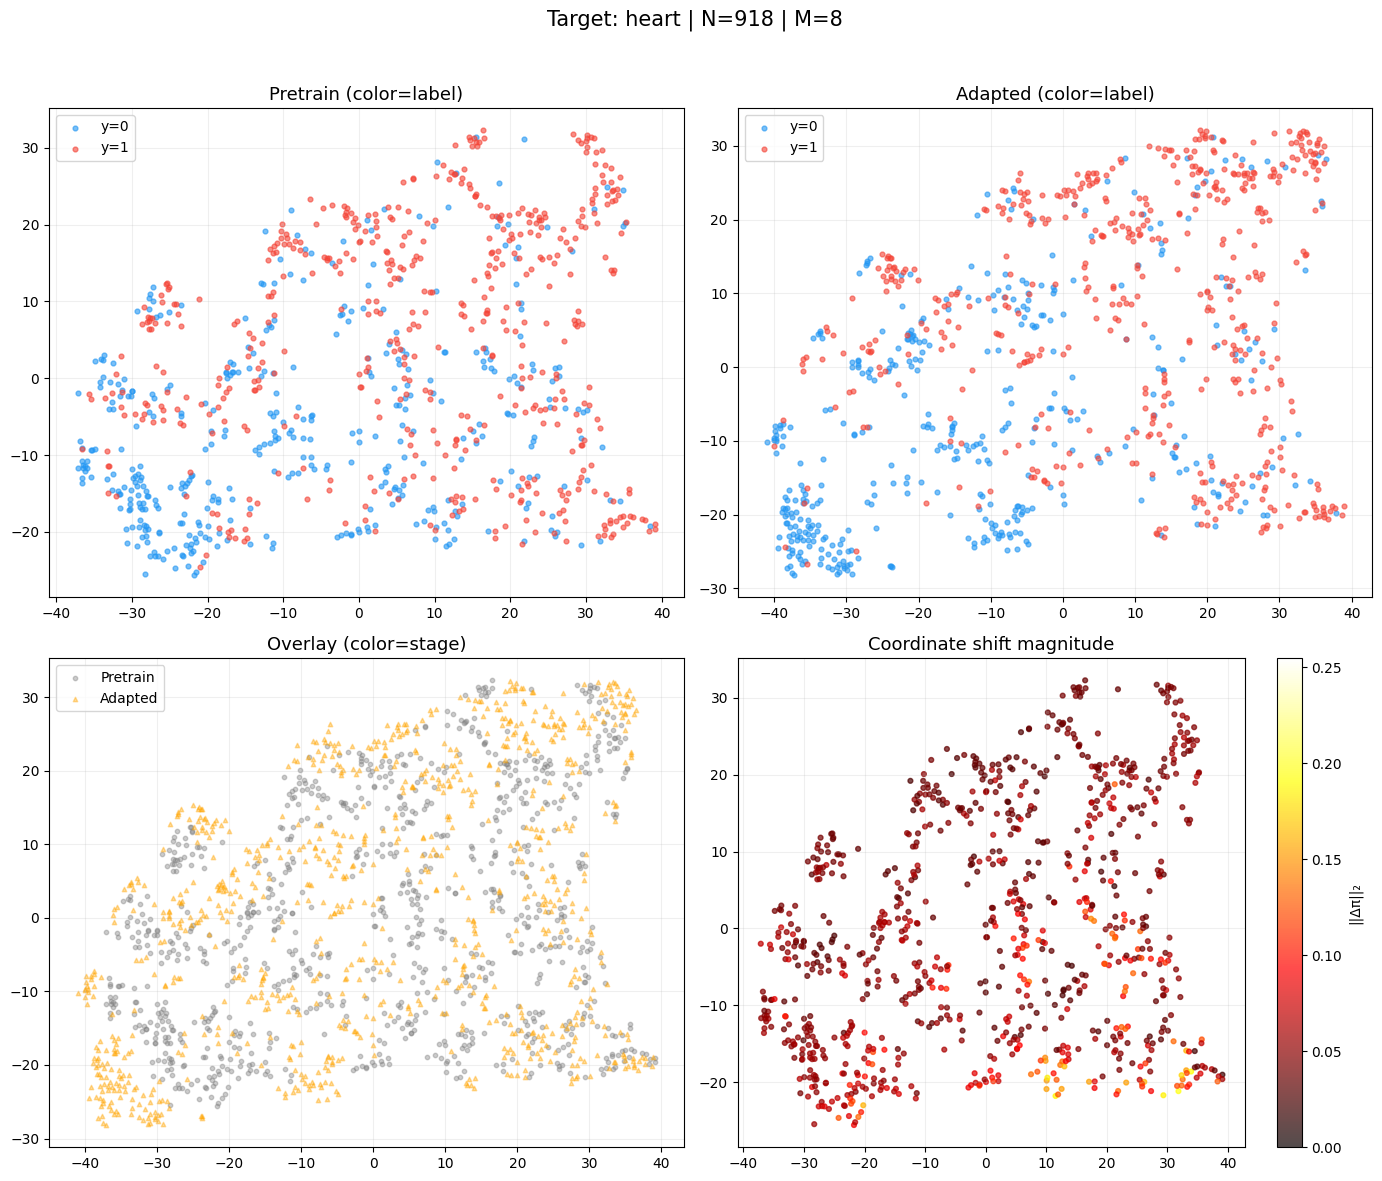

In [48]:
# ── 4) Visualization ──

M = pis_pre.shape[1]
N = len(ys_pre)

# 4-1) t-SNE: Pretrain vs Adapted (joint embedding)
pis_joint = np.concatenate([pis_pre, pis_adapt], axis=0)  # [2N, M]
ys_joint = np.concatenate([ys_pre, ys_adapt], axis=0)
stage_labels = np.array(['Pretrain'] * N + ['Adapted'] * N)

perp = max(5, min(50, (2 * N - 1) // 3))
tsne_joint = TSNE(n_components=2, perplexity=perp, learning_rate=200,
                  init='pca', random_state=42).fit_transform(pis_joint)

tsne_pre = tsne_joint[:N]
tsne_adapt = tsne_joint[N:]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# (0,0) Pretrain - color by label
ax = axes[0, 0]
for label, color in zip([0, 1], ['#2196F3', '#F44336']):
    mask = ys_pre == label
    ax.scatter(tsne_pre[mask, 0], tsne_pre[mask, 1], s=12, alpha=0.6,
               c=color, label=f'y={label}')
ax.set_title('Pretrain (color=label)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.2)

# (0,1) Adapted - color by label
ax = axes[0, 1]
for label, color in zip([0, 1], ['#2196F3', '#F44336']):
    mask = ys_adapt == label
    ax.scatter(tsne_adapt[mask, 0], tsne_adapt[mask, 1], s=12, alpha=0.6,
               c=color, label=f'y={label}')
ax.set_title('Adapted (color=label)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.2)

# (1,0) Overlay - color by stage
ax = axes[1, 0]
ax.scatter(tsne_pre[:, 0], tsne_pre[:, 1], s=10, alpha=0.4,
           c='gray', label='Pretrain', marker='o')
ax.scatter(tsne_adapt[:, 0], tsne_adapt[:, 1], s=10, alpha=0.4,
           c='orange', label='Adapted', marker='^')
ax.set_title('Overlay (color=stage)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.2)

# (1,1) Coordinate shift magnitude per sample
shift = np.linalg.norm(pis_adapt - pis_pre, axis=1)  # [N]
sc = ax_shift = axes[1, 1]
scatter = ax_shift.scatter(tsne_pre[:, 0], tsne_pre[:, 1], s=12, alpha=0.7,
                           c=shift, cmap='hot', vmin=0)
plt.colorbar(scatter, ax=ax_shift, label='||Δπ||₂')
ax_shift.set_title('Coordinate shift magnitude', fontsize=13)
ax_shift.grid(True, alpha=0.2)

fig.suptitle(f'Target: {args_pre.target_data} | N={N} | M={M}', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

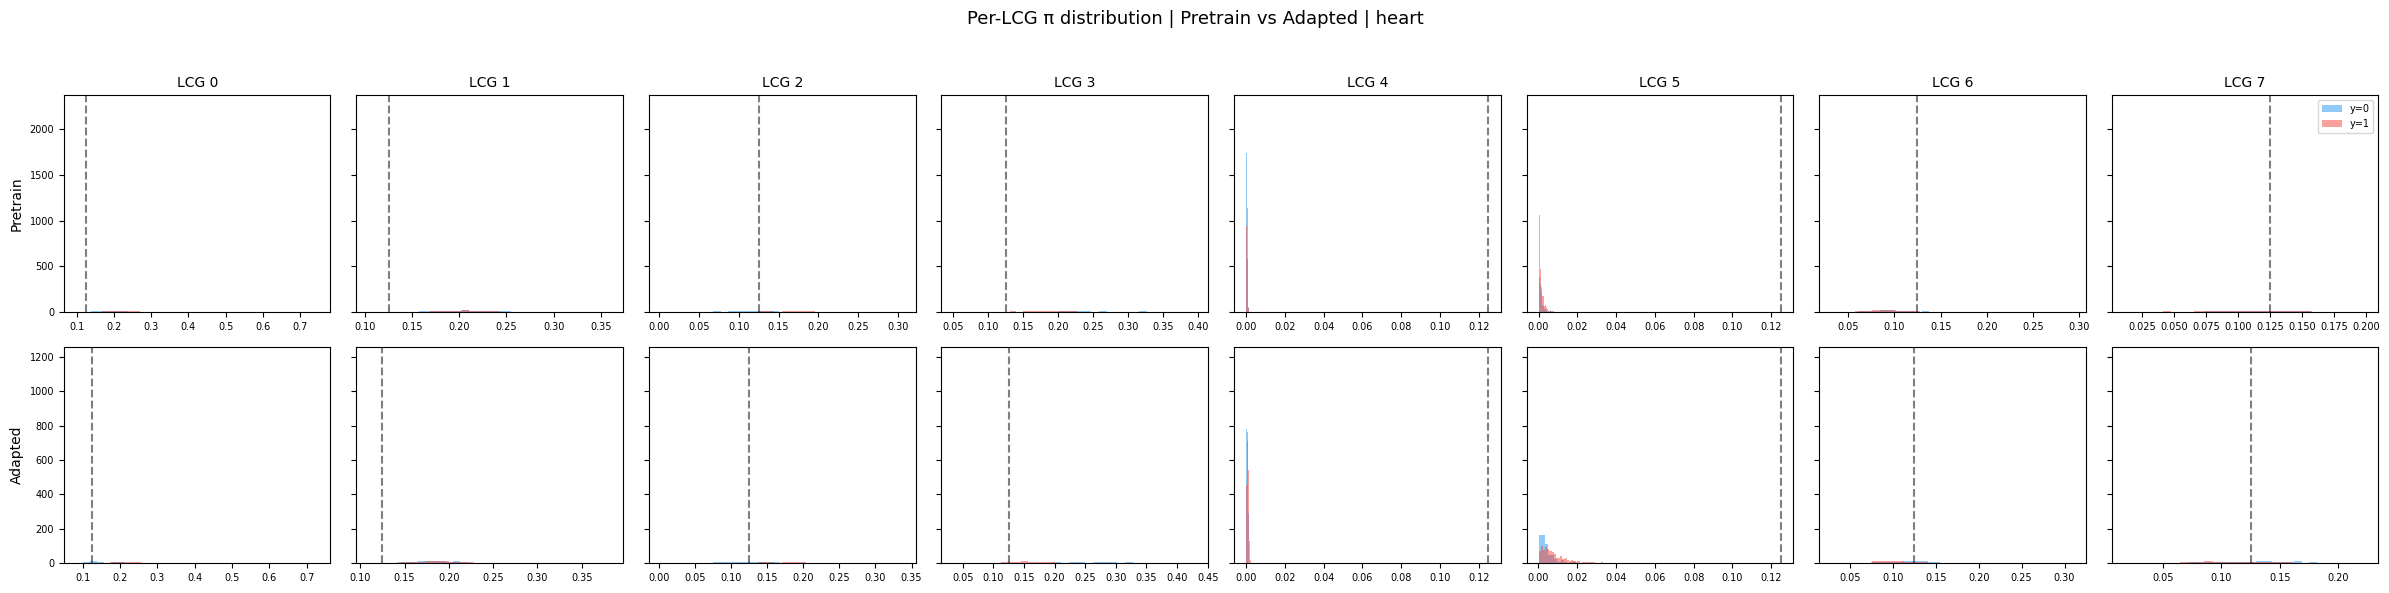

In [49]:
# 4-2) Per-LCG dimension: label별 분포 비교 (Pretrain vs Adapted)
fig, axes = plt.subplots(2, M, figsize=(3 * M, 6), sharey='row')

for m in range(M):
    # Pretrain
    ax = axes[0, m]
    for label, color in zip([0, 1], ['#2196F3', '#F44336']):
        mask = ys_pre == label
        ax.hist(pis_pre[mask, m], bins=30, alpha=0.5, color=color,
                label=f'y={label}', density=True)
    ax.axvline(1.0 / M, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'LCG {m}', fontsize=10)
    if m == 0:
        ax.set_ylabel('Pretrain')
    ax.tick_params(labelsize=7)

    # Adapted
    ax = axes[1, m]
    for label, color in zip([0, 1], ['#2196F3', '#F44336']):
        mask = ys_adapt == label
        ax.hist(pis_adapt[mask, m], bins=30, alpha=0.5, color=color,
                label=f'y={label}', density=True)
    ax.axvline(1.0 / M, color='black', linestyle='--', alpha=0.5)
    if m == 0:
        ax.set_ylabel('Adapted')
    ax.tick_params(labelsize=7)

axes[0, -1].legend(fontsize=7)
fig.suptitle(f'Per-LCG π distribution | Pretrain vs Adapted | {args_pre.target_data}', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [50]:
# Source에서 coordinate 확인
pis_src, ys_src, src_labels, src_names = collect_all_pi_with_meta(model_pre, loaders, device)

# Source label별 mean π
for label in [0, 1]:
    mask = ys_src == label
    print(f"Source y={label}: mean π = {pis_src[mask].mean(axis=0).round(4)}")

# Target 비교
for label in [0, 1]:
    mask = ys_pre == label
    print(f"Target y={label}: mean π = {pis_pre[mask].mean(axis=0).round(4)}")

Collected: 3637 samples, M=8, Sources=6
Source y=0: mean π = [0.1278 0.1907 0.136  0.1525 0.067  0.0382 0.1029 0.1849]
Source y=1: mean π = [0.1674 0.1464 0.1092 0.1351 0.0499 0.0539 0.2001 0.1381]
Target y=0: mean π = [0.213  0.2103 0.1134 0.2467 0.0004 0.001  0.0991 0.1162]
Target y=1: mean π = [0.2515 0.2076 0.1482 0.1859 0.0005 0.0018 0.1002 0.1043]
